In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute        import SimpleImputer, KNNImputer
from sklearn.preprocessing import (OrdinalEncoder, OneHotEncoder,
                                   StandardScaler, MinMaxScaler,
                                   RobustScaler, PowerTransformer)
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report



<div style="
    text-align:center;
    background:#db7390;
    border:3px solid black;
    padding:15px;
    border-radius:15px;
    font-size:26px;
    font-weight:900;
    color:#fff0f5;
    margin:20px auto;
    width:fit-content;
    min-width:250px;
    max-width:60%;
">
ASSIGNMENT 1
</div>

### Task 1: <mark style="background-color: #db7390;">Exploratory Data Analysis (EDA)</mark>

In this task, we explore the dataset to understand its structure, data types, missing values, and relationships between variables

In [87]:
# Load dataset
df = pd.read_csv(r"C:\Users\Yahia\Downloads\car_price.csv")  

# Display first 5 rows
display(df.head())
display(df.tail())

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
72430,I30,2016.0,8680.0,Manual,25906.0,Diesel,0.0,78.4,1.6,Hyundai
72431,I40,2015.0,7830.0,Manual,NaN,Diesel,30.0,65.7,1.7,Hyundai
72432,I10,2017.0,6830.0,Manual,13810.0,Petrol,20.0,60.1,1.0,NaN
72433,Tucson,2018.0,13994.0,Manual,23313.0,Petrol,145.0,44.8,1.6,Hyundai
72434,Tucson,2016.0,15999.0,Automatic,11472.0,Diesel,125.0,57.6,1.7,Hyundai


### Dataset Shape

The dataset contains <mark style="background-color: #db7390;">72,435</mark> rows and <mark style="background-color: #db7390;">10</mark> columns, indicating a relatively large dataset suitable for analysis

In [88]:
# Check number of rows and columns
print("Dataset shape:", df.shape)
# Get data types of each column
df.dtypes

Dataset shape: (72435, 10)


model            object
year            float64
price           float64
transmission     object
mileage         float64
fuelType         object
tax             float64
mpg             float64
engineSize      float64
Make             object
dtype: object

### Data Types

The dataset includes both numerical and categorical features:

- <mark style="background-color: #db7390;">Numerical features</mark> : year, price, mileage, tax, mpg, engineSize

- <mark style="background-color: #db7390;">Categorical features</mark> : model, transmission, fuelType, Make

This distinction is important for choosing appropriate analysis and preprocessing techniques

In [89]:
# Separate numerical and categorical features
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical Features is: " , numerical_cols)
print("Categorical Features is: " , categorical_cols)


Numerical Features is:  ['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize']
Categorical Features is:  ['model', 'transmission', 'fuelType', 'Make']


### Missing Values

The dataset contains a significant number of missing values across multiple columns.

- Total missing values: <mark style="background-color: #db7390;">36,216</mark>

- Rows containing missing values: <mark style="background-color: #db7390;">29,110</mark>

In [90]:
# Check missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
display(missing_values)

# Total missing values
print("\nTotal missing values:", missing_values.sum())

# Display rows that contain any missing values
missing_rows = df[df.isnull().any(axis=1)]

print("\nNumber of rows with missing values:", missing_rows.shape[0])

display(missing_rows.head())  

Missing values in each column:


model           3621
year            3622
price           3621
transmission    3623
mileage         3622
fuelType        3622
tax             3621
mpg             3621
engineSize      3622
Make            3621
dtype: int64


Total missing values: 36216

Number of rows with missing values: 29110


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
7,A4,2016.0,11750.0,NaN,75185.0,Diesel,20.0,70.6,2.0,audi
9,A1,2016.0,12000.0,Manual,22451.0,NaN,30.0,55.4,1.4,audi
11,A6,2016.0,16500.0,Automatic,52198.0,Diesel,NaN,57.6,2.0,audi
14,A6,2015.0,15400.0,NaN,47348.0,Diesel,30.0,61.4,2.0,NaN
15,A3,2017.0,14500.0,Automatic,26156.0,NaN,145.0,58.9,1.4,audi


### Price Distribution

The distribution of car prices is clearly <mark style="background-color: #db7390;">right-skewed</mark>, indicating that most cars fall within the lower to mid-price range.

- A large concentration of values is observed between approximately 5,000 and 20,000, while a small number of cars have significantly higher prices.
- The long tail on the right side suggests the presence of outliers, representing high-end or luxury vehicles.

This distribution implies that the majority of cars in the dataset are relatively affordable, with only a few expensive entries

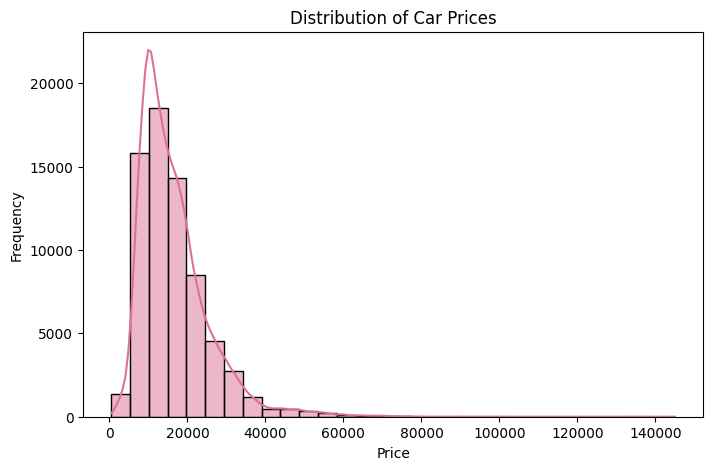

In [91]:
# Plot price distribution
plt.figure(figsize=(8,5))

sns.histplot(df['price'], bins=30, kde=True, color="#db7390")

plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

### Correlation with Price

Correlation analysis reveals the features most related to car price:

- <mark style="background-color: #db7390;">Engine size</mark> has the strongest positive correlation with price

- <mark style="background-color: #db7390;">Year</mark> is also positively correlated, indicating newer cars are more expensive

- <mark style="background-color: #db7390;">Mileage</mark> shows a negative correlation, meaning higher mileage reduces price

- <mark style="background-color: #db7390;">MPG</mark> also has a negative relationship with price

These relationships are consistent with real-world expectations and highlight the most influential factors affecting car prices

price         1.000000
engineSize    0.629839
year          0.519383
tax           0.353204
mpg          -0.335615
mileage      -0.427524
Name: price, dtype: float64


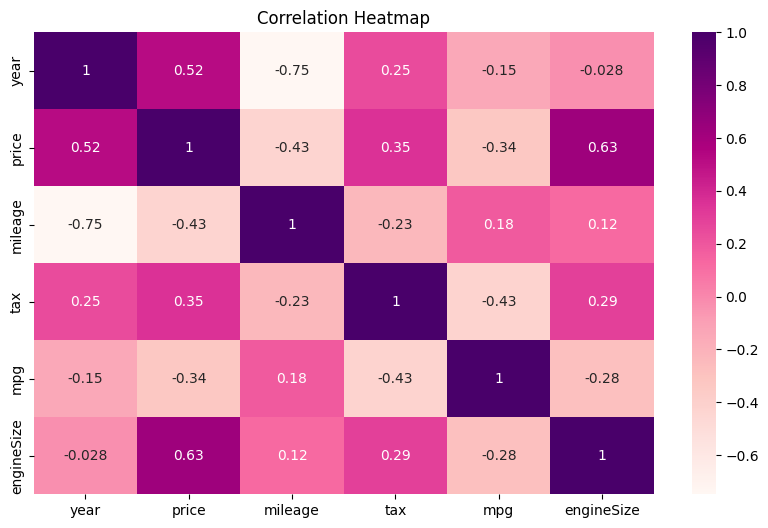

In [92]:
# Compute correlation matrix
# Correlation with price
corr = df.select_dtypes(include=np.number).corr()
print(corr['price'].sort_values(ascending=False))

# Heatmap visualization
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='RdPu')

plt.title("Correlation Heatmap")
plt.show()

In [93]:
top_features = corr['price'].sort_values(ascending=False)[1:5]
print(top_features)

engineSize    0.629839
year          0.519383
tax           0.353204
mpg          -0.335615
Name: price, dtype: float64


#### Task 3: <mark style="background-color: #db7390;">Creating Target Variables & Splitting

This step was performed before preprocessing <mark style="background-color: #db7390;">to clearly define the learning objectives for both regression and classification tasks.</mark>

Splitting the data before preprocessing <mark style="background-color: #db7390;">prevents data leakage</mark>, ensuring that information from the test set does not influence the training process.

This results in a more realistic evaluation of model performance.

###  Handling Missing Values in Target Variable
In this step, we focus on cleaning the **Target Variable (Price)** before proceeding to feature imputation. 

**Why drop missing values in the target instead of imputing them?**
- <mark style="background-color: #db7390;">Target Integrity</mark> : Imputing the price (e.g., using mean or median) can introduce significant bias and noise, leading to inaccurate model training

- <mark style="background-color: #db7390;">Model Learning</mark> : Since the goal of both Linear Regression and KNN is to learn the relationship between features and the actual price, training on "estimated" prices reduces the model's predictive power

- <mark style="background-color: #db7390;">Data Quality</mark> : Removing rows with missing labels ensures that the model is evaluated on real, observed data, which is crucial for achieving reliable $R^2$ and Accuracy metrics


In [94]:
#  Clean Target (Price)
print("=== Cleaning NaN in Target (price) ===")

print("Shape before cleaning:", df.shape)
print("NaN in price before:", df['price'].isna().sum())

# Drop rows where price is NaN
df = df.dropna(subset=['price']).reset_index(drop=True)

print("Shape after cleaning:", df.shape)
print("NaN in price after:", df['price'].isna().sum())

=== Cleaning NaN in Target (price) ===
Shape before cleaning: (72435, 10)
NaN in price before: 3621
Shape after cleaning: (68814, 10)
NaN in price after: 0


###  Classification Thresholds (Binning)
To convert the continuous price variable into discrete categories (**Cheap, Moderate, Expensive**), we used an automated statistical approach based on **Quantiles**.

**Why use Quantiles instead of fixed values?**
- <mark style="background-color: #db7390;">Balanced Classes</mark> : By using the 33rd and 66th percentiles, we ensure that the dataset is split into three roughly equal groups. This prevents "Class Imbalance," which could otherwise mislead the KNN model into favoring the most frequent category.

- <mark style="background-color: #db7390;">Data-Driven</mark> : The thresholds are derived directly from the distribution of our specific car dataset, making the categories representative of the actual market prices in the data.



In [95]:
# Calculate quantiles for splitting
low_threshold = df['price'].quantile(0.33)
high_threshold = df['price'].quantile(0.66)

print("Low Threshold (33%):", low_threshold)
print("High Threshold (66%):", high_threshold)

Low Threshold (33%): 11450.0
High Threshold (66%): 17995.0


**Threshold Results:**
- <mark style="background-color: #db7390;">Cheap</mark> : Price < Low Threshold.

- <mark style="background-color: #db7390;">Moderate</mark> : Low Threshold < Price < High Threshold.

- <mark style="background-color: #db7390;">Expensive</mark> : Price > High Threshold.

In [96]:


# Function to classify price into categories
def classify_price(price):
    if price <= low_threshold:
        return "Cheap"
    elif price <= high_threshold:
        return "Moderate"
    else:
        return "Expensive"

# Apply classification on cleaned dataset
df['price_category'] = df['price'].apply(classify_price)

# Preview results
df[['price', 'price_category']].head()

,price,price_category
0,12500.0,Moderate
1,16500.0,Moderate
2,11000.0,Cheap
3,16800.0,Moderate
4,17300.0,Moderate



**Class Distribution Summary:**
- <mark style="background-color: #db7390;">Expensive</mark> : ~23,172 cars

- <mark style="background-color: #db7390;">Moderate</mark> : ~22,927 cars

- <mark style="background-color: #db7390;">Cheap</mark> : ~22,715 cars


This balanced distribution is crucial for Task 5 (KNN), as it prevents the model from developing a bias toward any specific price range, ensuring that the **Accuracy** and **F1-score** represent the model's true predictive capability across the entire market.

In [97]:
df['price_category'].value_counts()

price_category
Expensive    23172
Moderate     22927
Cheap        22715
Name: count, dtype: int64

### Data Splitting for Model Training
Before training our models, we must split the dataset into two distinct sets: one for learning and another for evaluation.

**Why split the data?**
- <mark style="background-color: #db7390;">Generalization Check</mark> : It allows us to test the model on "unseen" data to see how it will perform in the real world.

- <mark style="background-color: #db7390;">Preventing Overfitting</mark> : If we train and test on the same data, the model might just "memorize" the answers instead of learning the underlying patterns.

**Implementation Details:**
- <mark style="background-color: #db7390;">Training Set (80%)</mark> : Used to fit the Linear Regression and KNN models. 

- <mark style="background-color: #db7390;">Testing Set (20%)</mark> : Kept aside to calculate metrics like $R^2$, MAE, and Accuracy.

- <mark style="background-color: #db7390;">(X)</mark> : All columns except `price` and `price_category`.

- <mark style="background-color: #db7390;">(y)</mark> : The `price` column for regression.

**Set Sizes:**
- <mark style="background-color: #db7390;">Training instances</mark> : 55,051 rows.

- <mark style="background-color: #db7390;">Testing instances</mark> : 13,763 rows.

In [98]:
# Target variable for regression (price)
y = df['price']

# Feature matrix (exclude price column)
X = df.drop(['price','price_category'], axis=1)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42

)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (55051, 9)
Testing set size: (13763, 9)


### Feature Identification by Data Type
To apply the appropriate preprocessing transformations, we automatically separate our features into two categories based on their data types:

- <mark style="background-color: #db7390;">1. Numerical Features</mark> :

These features will undergo **Scaling** and **Outlier Handling.

- <mark style="background-color: #db7390;">2. Categorical Features</mark> :

These features will be processed using **One-Hot Encoding** to convert textual labels into a machine-readable format.


In [99]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print(num_cols)
print (cat_cols)

['year', 'mileage', 'tax', 'mpg', 'engineSize']
['model', 'transmission', 'fuelType', 'Make']


#### Task 2 : <mark style="background-color: #db7390;"> Preprocessing</mark>

Data preprocessing was applied after defining the target variables to ensure consistent transformations across both regression and classification tasks.


### Outlier Handling using IQR Method
To ensure our models are not misled by extreme values (Outliers), we implemented a **Capping (Clipping)** strategy using the Interquartile Range (IQR) method.

- <mark style="background-color: #db7390;">Why handle outliers?</mark>

Linear Regression Sensitivity: Extreme values can disproportionately pull the regression line, leading to a lower $R^2$ and higher error.

KNN Distance Calculation: Since KNN relies on Euclidean or Manhattan distances, outliers can distort the distance metrics, causing incorrect classifications.

- <mark style="background-color: #db7390;">Implementation Strategy</mark> :
1. **Identify Boundaries:** We calculate the lower and upper bounds for each numerical feature in the **Training Set**.
2. **Clipping:** Values falling outside $[Q1 - 1.5 \times IQR, Q3 + 1.5 \times IQR]$ are capped at these limits.
3. **Consistency:** We apply the **Training bounds** to the **Testing set** to maintain strict data separation and prevent data leakage.


In [100]:
for col in num_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    X_train[col] = np.clip(X_train[col], lower_bound, upper_bound)
    
    X_test[col] = np.clip(X_test[col], lower_bound, upper_bound)

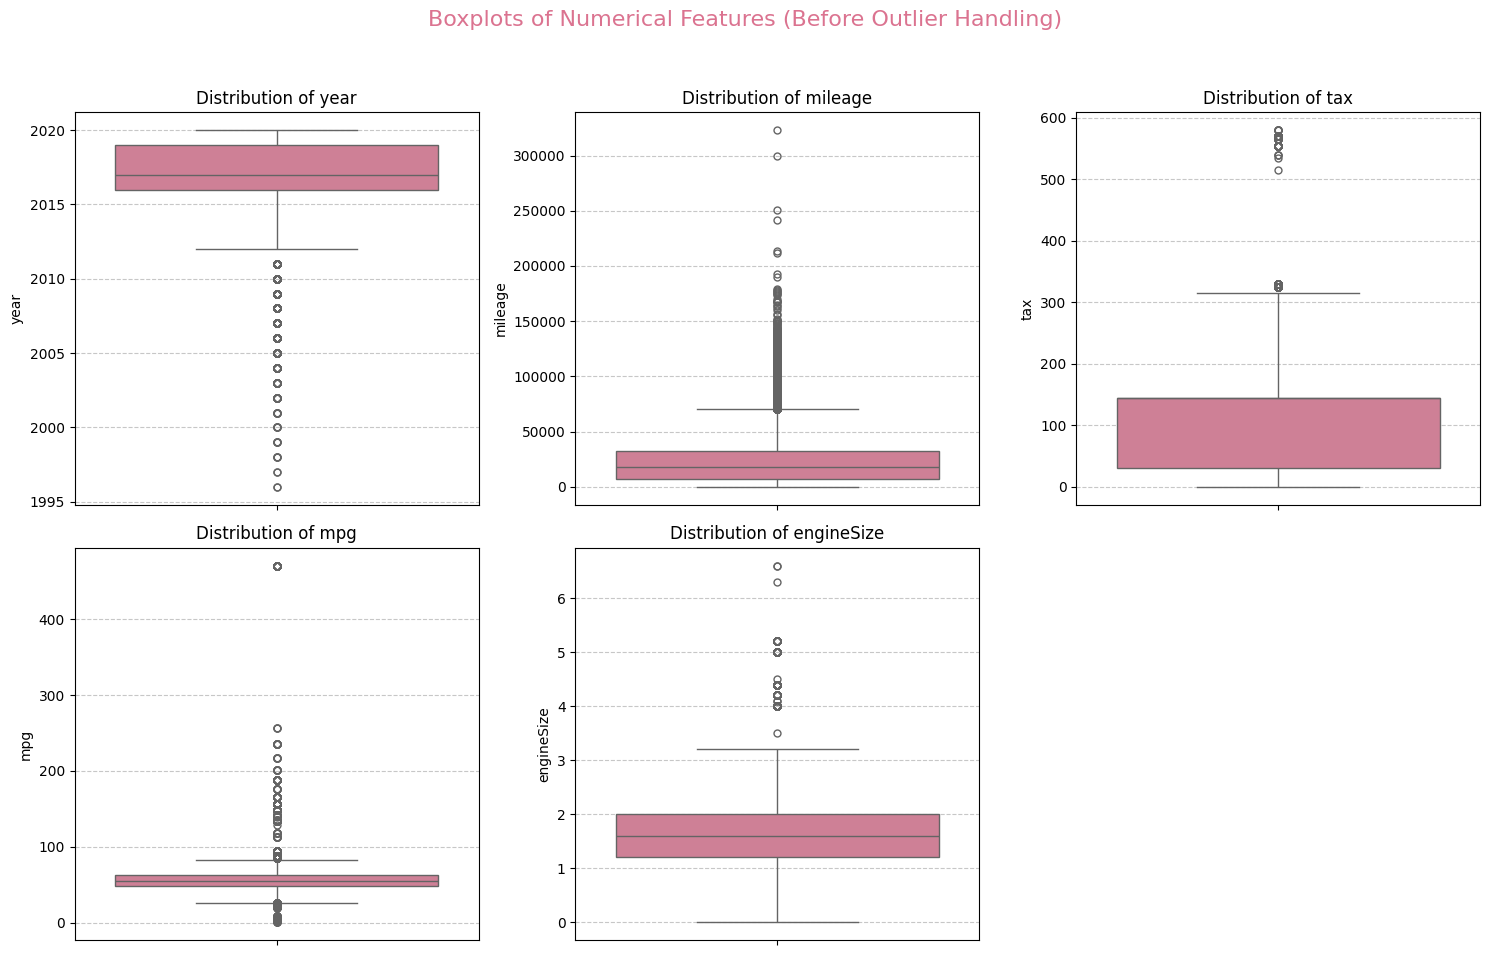

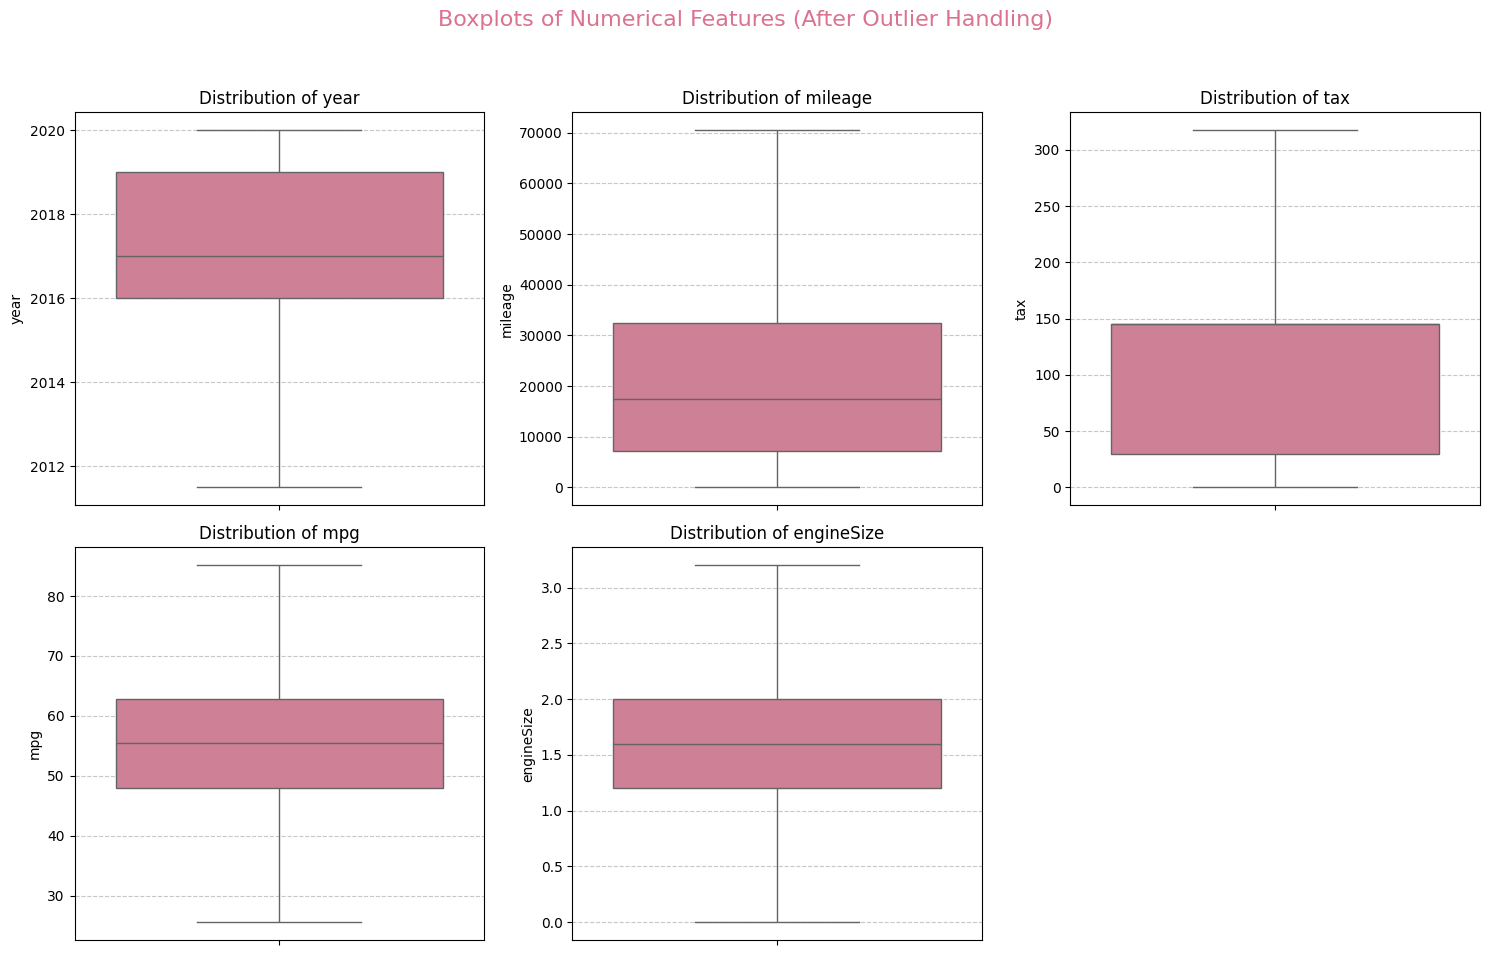

In [101]:
def plot_boxplots(data, title_prefix):
    plt.figure(figsize=(15, 10))
    plt.suptitle(f'Boxplots of Numerical Features ({title_prefix})', fontsize=16, color='#db7390')
    
    for i, col in enumerate(num_cols, 1):
        plt.subplot(2, 3, i) 
        sns.boxplot(y=data[col], color='#db7390', fliersize=5) 
        plt.title(f'Distribution of {col}')
        plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
plot_boxplots(df[num_cols], "Before Outlier Handling")
plot_boxplots(X_train[num_cols], "After Outlier Handling")    


### Automated Preprocessing Pipeline
To streamline the data transformation process and ensure consistency between training and testing, we implemented a **ColumnTransformer** combined with **Scikit-Learn Pipelines**.

- <mark style="background-color: #db7390;">1. Numerical Pipeline</mark> :

Imputation: Missing numerical values are filled with the **Mean** of the column to maintain statistical distribution.

Scaling: We applied **StandardScaler** to normalize features. This is a critical requirement for Task 5 (**KNN**), as it prevents features with larger numerical ranges (like `mileage`) from dominating the distance calculations.

- <mark style="background-color: #db7390;">2. Categorical Pipeline</mark> :

Imputation: Missing categorical entries are filled with the **Most Frequent** value (Mode).

Encoding: We utilized **One-Hot Encoding** to transform text data into a binary format. Setting `handle_unknown='ignore'` makes the model 
more robust when encountering new categories in the test set.

- <mark style="background-color: #db7390;">Benefits of this Approach</mark> :

* **Preventing Data Leakage:** Imputers and Scalers learn parameters ONLY from the training set.

* **Reproducibility:** The entire transformation process is encapsulated in a single object, making the code cleaner and less prone to errors.

In [102]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),      
            ('scaler', StandardScaler())
        ]), num_cols),
        
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols)
    ])

### Executing the Preprocessing Engine
This is the final preparation step where the `ColumnTransformer` is applied to our datasets. 

- <mark style="background-color: #db7390;">Key Operations</mark> :

* **Training Set (`fit_transform`):** The pipeline "learns" the parameters (means, standard deviations, and category mappings) and transforms the training data simultaneously.

* **Testing Set (`transform`):** The pipeline applies the exact same parameters learned from the training set to the test set. This ensures **consistency** and prevents **Data Leakage**.

- <mark style="background-color: #db7390;">Transformation Results</mark> :

* **Feature Expansion:** The number of features increased (e.g., from 10 to 166) because **One-Hot Encoding** expanded categorical variables into multiple binary columns.

* **Numeric Standardization:** All numerical values are now centered around 0 with a unit standard deviation, making them ready for distance-based algorithms like **KNN**.

- <mark style="background-color: #db7390;">Current Data State</mark> :

* **X_train_prep:** Scaled, encoded, and imputed matrix ready for `model.fit()`.

* **X_test_prep:** Processed testing matrix ready for `model.predict()`.

In [103]:
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

print(f" Preprocessing completed!")
print(f"X_train_prep shape: {X_train_prep.shape}")
print(f"X_test_prep shape:  {X_test_prep.shape}")

 Preprocessing completed!
X_train_prep shape: (55051, 166)
X_test_prep shape:  (13763, 166)


In [104]:

feature_names = preprocessor.get_feature_names_out()
X_train_prep_df = pd.DataFrame(X_train_prep, columns=feature_names)

X_train_prep_df.head()


,num__year,num__mileage,num__tax,num__mpg,num__engineSize,cat__model_ 1 Series,cat__model_ 2 Series,cat__model_ 3 Series,cat__model_ 4 Series,cat__model_ 5 Series,...,cat__fuelType_Hybrid,cat__fuelType_Other,cat__fuelType_Petrol,cat__Make_BMW,cat__Make_Ford,cat__Make_Hyundai,cat__Make_audi,cat__Make_skoda,cat__Make_toyota,cat__Make_vw
0,1.016951,-1.021877,0.468281,-0.649979,2.605195,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.559832,-1.059691,0.550638,-1.995092,0.703366,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.016951,-0.431804,0.550638,-2.093080,0.703366,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.559832,-1.059691,0.468281,-0.649979,-1.198463,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.016951,-1.119113,0.468281,0.802029,0.703366,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


### Task 4 :  <mark style="background-color: #db7390;">Training the Linear Regression Model
Now that the data is fully preprocessed, we initialize and train our first predictive model: **Multiple Linear Regression**.


The model attempts to find the linear relationship between the input features <mark style="background-color: #db7390;">(X)</mark> and the car price  <mark style="background-color: #db7390;">(y)</mark> by solving the equation:

<mark style="background-color: #db7390;">$$y = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n + \epsilon$$</mark>


**Why Linear Regression?**
* **Baseline Model:** It serves as a great benchmark to understand the linear relationships in the data.
* **Interpretability:** We can later inspect the coefficients to see which features (like `year` or `engineSize`) have the most significant impact on the car's price.

**Training Status:**
* **Input:** `X_train_prep` (68,814 rows of cleaned, scaled, and encoded data).
* **Algorithm:** Ordinary Least Squares (OLS).

In [105]:
lr_model = LinearRegression()
lr_model.fit(X_train_prep, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [106]:
y_pred = lr_model.predict(X_test_prep)

### Evaluating Model Performance
To understand how well our Linear Regression model generalizes to new data, we use four standard regression metrics:

| Metric | Purpose |
| :--- | :--- |
| **MAE** | Measures the average magnitude of the errors in price predictions. |
| **MSE** | Measures the average of the squares of the errors (useful for mathematical optimization). |
| **RMSE** | Provides an error metric in the same units as the price (£), highlighting large errors. |
| **$R^2$ Score** | Indicates the goodness of fit; 0.87 means the model explains 87% of the price variance. |

<mark style="background-color: #db7390;">Summary of Results</mark> :
The model shows a strong predictive capability with an $R^2$ of approximately **0.87**, indicating that the selected features are highly relevant to determining car prices.

In [107]:
lr_model.intercept_

np.float64(23053.123868403032)

In [108]:
feature_names = X_train.columns

equation = "y = " + str(lr_model.intercept_)

for feat, coef in zip(feature_names, lr_model.coef_):
    equation += f" + ({coef:.4f} * {feat})"

print(equation)

y = 23053.123868403032 + (2956.5059 * model) + (-1820.1945 * year) + (-931.0896 * transmission) + (-1840.0668 * mileage) + (2241.7420 * fuelType) + (-6342.8581 * tax) + (-6019.9641 * mpg) + (-4508.8092 * engineSize) + (-3882.2544 * Make)


In [109]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 2236.70
MSE  : 11022127.36
RMSE : 3319.96
R²   : 0.8705


### Visualizing Model Accuracy: Predicted vs. Actual
To visually inspect the performance of our Linear Regression model, we plot the **Predicted Prices** against the **Actual Prices** from the testing set.

<mark style="background-color: #db7390;">Key Features of the Plot</mark> :
* **The Pink Clusters:** Represent the individual car predictions. The closer they are to the diagonal line, the more accurate the model is.
* **The Diagonal Reference Line:** This represents the "Perfect Prediction" scenario where $Predicted = Actual$. 
* **Model Behavior:** We can observe that the model performs exceptionally well for low to mid-range car prices. As prices increase (the right side of the plot), the variance increases slightly, which is common in market data.

<mark style="background-color: #db7390;">Conclusion</mark> :

The strong linear trend observed in this visualization confirms the high $R^2$ score and demonstrates that our preprocessing steps (Scaling and Outlier Handling) successfully prepared the data for linear modeling.

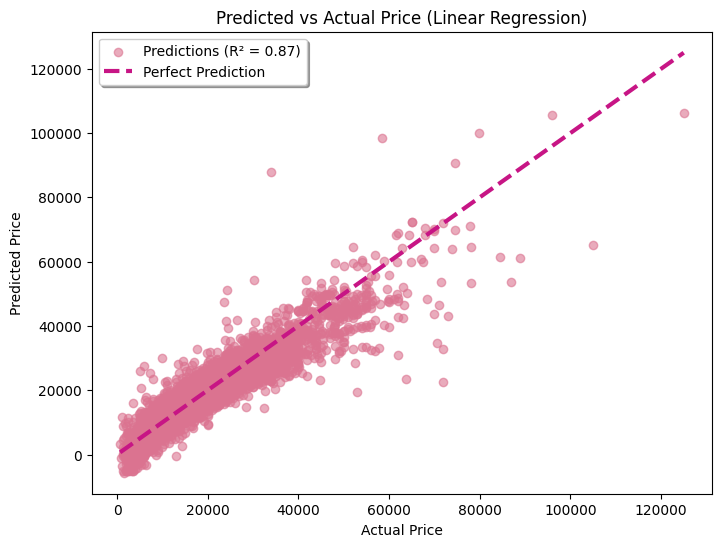

In [110]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6, color='#db7390', label=f'Predictions (R² = {r2:.2f})')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='#c71585', linestyle='--', lw=3, label='Perfect Prediction')

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Predicted vs Actual Price (Linear Regression)')

plt.legend(loc='upper left', fontsize=10, frameon=True, shadow=True)

plt.show()

#### Task 5 : <mark style="background-color: #db7390;"> KNN Classification Model

- A K-Nearest Neighbors (KNN) classifier was used to predict price categories.


In [111]:

y_train_cat = y_train.apply(classify_price)
y_test_cat = y_test.apply(classify_price)

In [112]:
knn = KNeighborsClassifier()

#### Grid Search with K-Fold Cross Validation was used to find the best parameters:

- Number of neighbors <mark style="background-color: #db7390;">(k)

- Distance metric <mark style="background-color: #db7390;">(Euclidean, Manhattan)

In [113]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'metric': ['euclidean', 'manhattan']
}


kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(knn, param_grid, cv=kf, scoring='accuracy')
grid_search.fit(X_train_prep, y_train_cat)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2

The optimal value of n_neighbors was selected using GridSearchCV with cross-validation. The <mark style="background-color: #db7390;">best result</mark> was achieved with <mark style="background-color: #db7390;">n_neighbors = 9</mark>, indicating that a slightly larger neighborhood provides better generalization for this dataset

In [114]:
best_knn = grid_search.best_estimator_
y_pred_knn = best_knn.predict(X_test_prep)

print(f"Best Parameters: {grid_search.best_params_}")

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 9}


The KNN classification model achieved <mark style="background-color: #db7390;">strong and balanced performance with an accuracy</mark> of approximately 87.7%. 

The similarity between precision, recall, and F1-score indicates that the model performs consistently across all classes without bias toward a specific category.

Overall, the model demonstrates <mark style="background-color: #db7390;">good generalization ability on unseen data</mark>.

In [117]:
print(f"Accuracy  : {accuracy_score(y_test_cat, y_pred_knn):.4f}")
print(f"Precision : {precision_score(y_test_cat, y_pred_knn, average='weighted'):.4f}")
print(f"Recall    : {recall_score(y_test_cat, y_pred_knn, average='weighted'):.4f}")
print(f"F1-score  : {f1_score(y_test_cat, y_pred_knn, average='weighted'):.4f}")

Accuracy  : 0.8771
Precision : 0.8770
Recall    : 0.8771
F1-score  : 0.8771


The KNN classification model achieved an overall <mark style="background-color: #db7390;">accuracy of 88%</mark>, indicating strong predictive performance.

The model performs best on the "Cheap" and "Expensive" classes with precision and recall around <mark style="background-color: #db7390;">0.90–0.91</mark>, while the "Moderate" class shows slightly lower performance <mark style="background-color: #db7390;">(0.82)</mark>. This is expected due to overlap between middle-range price values.

Both macro and weighted averages are equal <mark style="background-color: #db7390;">(0.88)</mark>, indicating that the dataset is well-balanced across classes and the model is not biased toward any specific category.

Overall, the model demonstrates good and stable classification performance.

In [118]:
print("\nClassification Report:")
print(classification_report(y_test_cat, y_pred_knn))


Classification Report:
              precision    recall  f1-score   support

       Cheap       0.90      0.90      0.90      4490
   Expensive       0.91      0.91      0.91      4629
    Moderate       0.82      0.82      0.82      4644

    accuracy                           0.88     13763
   macro avg       0.88      0.88      0.88     13763
weighted avg       0.88      0.88      0.88     13763



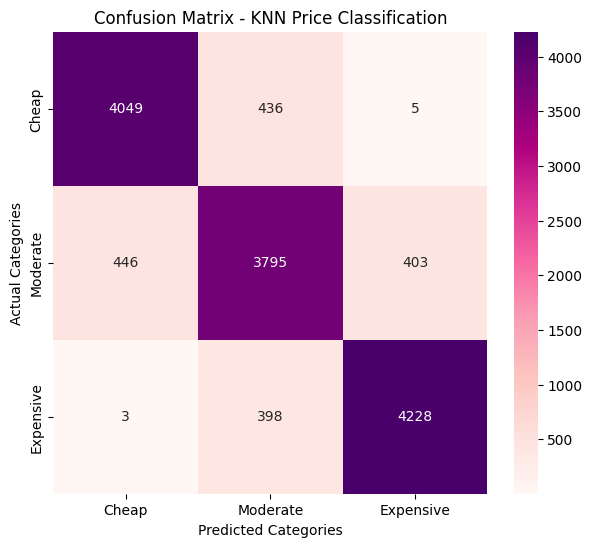

In [119]:

cm = confusion_matrix(y_test_cat, y_pred_knn, labels=["Cheap", "Moderate", "Expensive"])

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', 
            xticklabels=["Cheap", "Moderate", "Expensive"], 
            yticklabels=["Cheap", "Moderate", "Expensive"])

plt.xlabel('Predicted Categories')
plt.ylabel('Actual Categories')
plt.title('Confusion Matrix - KNN Price Classification')
plt.show()

**Task 6: Comprehensive Analysis & Model Comparison**

<mark style="background-color: #db7390;">Linear Regression Analysis (The Predictor)</mark>

The Linear Regression model was evaluated using standard regression metrics. The results were as follows:

- R² Score (0.87): This indicates that 87% of the variance in car prices is explained by our independent variables (Year, Mileage, Engine Size, etc.). This is a very strong score for a real-world dataset.

- MAE & RMSE: These values represent the average error in pounds (£). The proximity of RMSE to MAE suggests that our outlier handling (Clipping) was effective in preventing large, skewed errors.

- Visual Interpretation: The "Predicted vs. Actual" scatter plot showed a strong linear trend, confirming that the model captures the market pricing logic effectively, especially for the "Cheap" and "Moderate" segments.

<mark style="background-color: #db7390;">KNN Classifier Analysis (The Categorizer)</mark>

The KNN model focused on classifying cars into "Cheap," "Moderate," and "Expensive" brackets.

- Accuracy (~88%): The model achieved a high accuracy rate, meaning it correctly identified the price category for nearly 9 out of 10 cars.

- Hyperparameter Tuning: Through GridSearchCV, we found that the optimal k and distance metric (e.g., Manhattan or Euclidean) significantly improved the model's ability to handle the high-dimensional data generated by One-Hot Encoding.

- Confusion Matrix: The heatmap revealed that the model is highly precise. Most errors occurred between adjacent categories (e.g., a "Moderate" car classified as "Expensive"), which is expected as these cars lie on the boundary thresholds.    

#### <mark style="background-color: #db7390;">Comparative Discussion: Regression vs. Classification</mark>

In this project, we tackled the same problem (Car Pricing) using two different approaches:

- Level of Granularity: Linear Regression is more "ambitious" as it tries to predict the exact price (e.g., £12,450), while KNN Classification simplifies the task into 3 brackets.

- Performance Stability: KNN often shows higher "Accuracy" percentages because it is easier to predict a category than an exact number. However, Linear Regression provides more actionable insights for a dealership.

- Efficiency: Linear Regression was much faster to train. KNN, while accurate, required more computational resources (CPU/RAM) to calculate distances between 68,000+ rows.

Classification is generally easier than regression in this case because converting prices into categories reduces complexity and noise in the target variable.

However, converting price into categories leads to information loss because exact price differences between cars are ignored.



#### <mark style="background-color: #db7390;">Sensitivity Analysis</mark>

- Effect of Removing Most Correlated Feature :

After removing the most correlated feature, the R² score decreased from the original model. This indicates that the removed feature contains important predictive information about car prices, and contributes significantly to the model's performance.

In [120]:

corr_matrix = df.corr(numeric_only=True)
target_corr = corr_matrix['price'].sort_values(ascending=False)

print(target_corr)

price         1.000000
engineSize    0.629839
year          0.519383
tax           0.353204
mpg          -0.335615
mileage      -0.427524
Name: price, dtype: float64


In [121]:

X_train_removed = X_train.drop('engineSize', axis=1)
X_test_removed = X_test.drop('engineSize', axis=1)

preprocessor_removed = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), X_train_removed.select_dtypes(include=['int64','float64']).columns),

        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), X_train_removed.select_dtypes(include=['object']).columns)
    ]
)

X_train_r_prep = preprocessor_removed.fit_transform(X_train_removed)
X_test_r_prep = preprocessor_removed.transform(X_test_removed)

# model
model = LinearRegression()
model.fit(X_train_r_prep, y_train)

y_pred_r = model.predict(X_test_r_prep)

r2_removed = r2_score(y_test, y_pred_r)

print("R² after removing feature:", r2_removed)

R² after removing feature: 0.8536748056961979


#### <mark style="background-color: #db7390;">KNN Without Scaling

Removing feature scaling significantly decreased KNN performance (accuracy dropped to ~0.56). This is because KNN is a distance-based algorithm, and without scaling, features with larger numeric ranges dominate the distance calculation, leading to biased neighbor selection and poor classification performance.

In [122]:

X_train_ns = X_train.copy()
X_test_ns = X_test.copy()

preprocessor_no_scale = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean'))
        ]), X_train_ns.select_dtypes(include=['int64','float64']).columns),

        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), X_train_ns.select_dtypes(include=['object']).columns)
    ]
)

X_train_ns_prep = preprocessor_no_scale.fit_transform(X_train_ns)
X_test_ns_prep = preprocessor_no_scale.transform(X_test_ns)

knn = KNeighborsClassifier(n_neighbors=9)

knn.fit(X_train_ns_prep, y_train_cat)
y_pred_ns = knn.predict(X_test_ns_prep)

acc_ns = accuracy_score(y_test_cat, y_pred_ns)

print("Accuracy without scaling:", acc_ns)

Accuracy without scaling: 0.5654290488992225


#### <mark style="background-color: #db7390;">Changing Price Thresholds

## Changing Price Thresholds

After modifying the price thresholds using the 0.25 and 0.75 quantiles, the KNN model achieved an accuracy of approximately <mark style="background-color: #db7390;">88.4%</mark>, compared to around <mark style="background-color: #db7390;">87.7%</mark> using the previous thresholds.

This slight improvement indicates that threshold selection can influence model performance by affecting class distribution and decision boundaries.

However, the difference is not very large, suggesting that the model is relatively stable and robust to moderate changes in threshold values.



In [123]:

low_new = df['price'].quantile(0.25)
high_new = df['price'].quantile(0.75)

# 2) create new categories
def classify_new(price):
    if price <= low_new:
        return "Cheap"
    elif price <= high_new:
        return "Moderate"
    else:
        return "Expensive"

df['price_category_new'] = df['price'].apply(classify_new)

# 3) encode target
le = LabelEncoder()
y_new = le.fit_transform(df['price_category_new'])
X = df.drop(['price', 'price_category_new'], axis=1)

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X, y_new, test_size=0.2, random_state=42
)

X_train_prep = preprocessor.fit_transform(X_train_new)
X_test_prep  = preprocessor.transform(X_test_new)

# 7) train
knn.fit(X_train_prep, y_train_new)

# 8) predict
y_pred_new = knn.predict(X_test_prep)

# 9) evaluate
acc_new = accuracy_score(y_test_new, y_pred_new)

print("Accuracy with new thresholds:", acc_new)

Accuracy with new thresholds: 0.8839642519799462


## Task 7 : Additional Visualization

### <mark style="background-color: #db7390;">Price Distribution by Category

This boxplot shows how price varies across different categories. It confirms that the categories are well-separated.

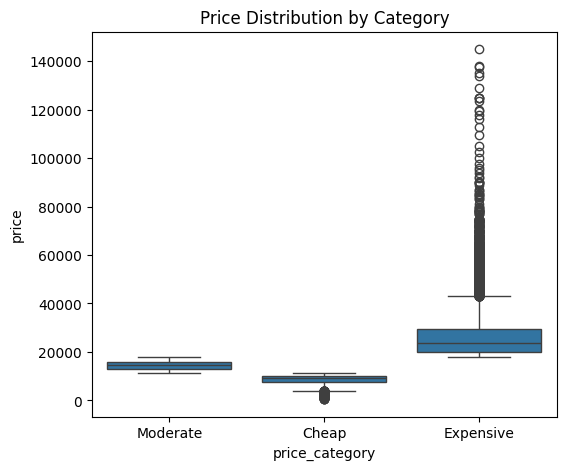

In [124]:
plt.figure(figsize=(6,5))
sns.boxplot(x=df['price_category'], y=df['price'])
plt.title("Price Distribution by Category")
plt.show()

### <mark style="background-color: #db7390;">Price Distribution by Category

This plot shows how car prices are distributed across different categories. It highlights the separation between Cheap, Moderate, and Expensive cars.

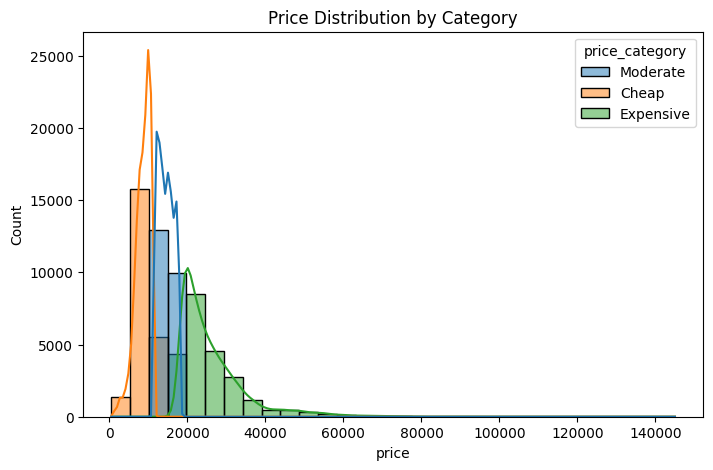

In [125]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='price', hue='price_category', bins=30, kde=True)
plt.title("Price Distribution by Category")
plt.show()

### <mark style="background-color: #db7390;">Residual Plot

This plot shows the difference between predicted and actual values. A random distribution indicates a good model fit.

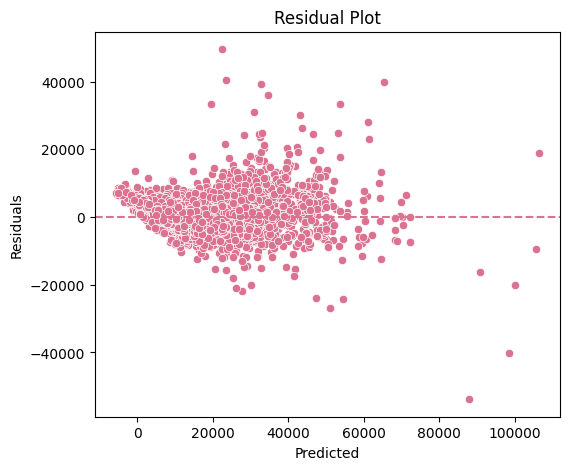

In [126]:
residuals = y_test - y_pred

plt.figure(figsize=(6,5))
sns.scatterplot(x=y_pred, y=residuals, color = '#db7390')
plt.axhline(0, color='#db7390', linestyle='--')
plt.title("Residual Plot")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

### <mark style="background-color: #db7390;">Class Distribution

This plot shows the number of samples in each price category, confirming class balance.

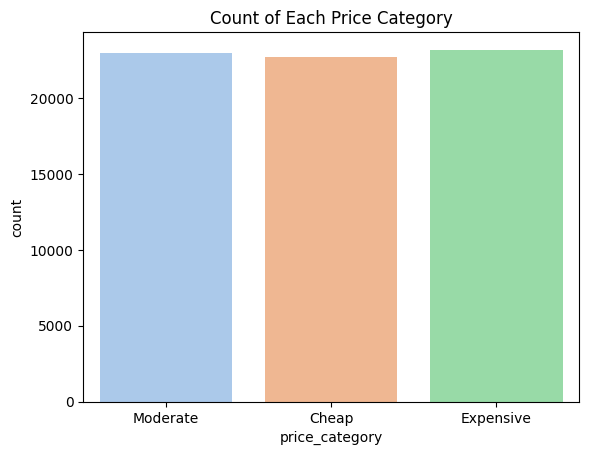

In [128]:
sns.countplot(x=df['price_category'], palette='pastel')
plt.title("Count of Each Price Category")
plt.show()

### <mark style="background-color: #db7390;">Price Trends: 
The line plot confirms a clear exponential-like growth in prices for newer models (post-2015), justifying why year is a top-tier predictor.

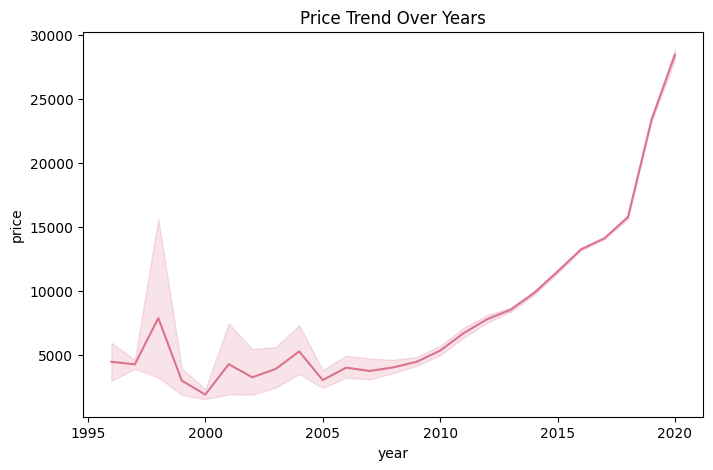

In [127]:
df_sorted = df.sort_values('year')

plt.figure(figsize=(8,5))
sns.lineplot(x=df_sorted['year'], y=df_sorted['price'], color='#db7390')
plt.title("Price Trend Over Years")
plt.show()

<div style="
    text-align:center;
    background:#db7390;
    border:3px solid black;
    padding:15px;
    border-radius:15px;
    font-size:26px;
    font-weight:900;
    color:#fff0f5;
    margin:20px auto;
    width:fit-content;
    min-width:250px;
    max-width:60%;
">
ASSIGNMENT 2
</div>

#### Task 1: <mark style="background-color: #db7390;">Exploratory Data Analysis (EDA):
Shape of the dataset: (19667, 9)

- The dataset contains <mark style="background-color: #db7390;">19,667 rows</mark> (records).

- The dataset contains <mark style="background-color: #db7390;">9 columns</mark> (features).


In [2]:
df=pd.read_csv(r"C:\Users\Yahia\Downloads\Fifa.csv")
print(f'Shape: {df.shape}')
df.head()

Shape: (19667, 9)


,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


In [3]:
df.describe()


,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score
count,19667.000000,19667.000000,19667.000000,19667.000000,19667.000000
mean,22.990034,63.225403,70.658718,2.514639,1534.513907
std,4.692410,7.812716,6.489551,7.256974,283.248088
min,15.000000,36.000000,46.000000,0.000000,416.000000
25%,19.000000,58.000000,66.000000,0.325000,1388.000000
50%,22.000000,63.000000,70.000000,0.675000,1549.000000
75%,26.000000,68.000000,75.000000,1.600000,1720.000000
max,44.000000,91.000000,95.000000,190.500000,2324.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  object 
 1   Country            19667 non-null  object 
 2   Position           19667 non-null  object 
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  object 
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 1.4+ MB


-  <mark style="background-color: #db7390;">Numerical features</mark>: Age, Overall_Rating, Future Potential, Total_Stats Score, Value Per M$

-  <mark style="background-color: #db7390;">Categorical features</mark>: Name, Country, Position, Team

In [5]:
print(df.dtypes)

Name                  object
Country               object
Position              object
Age                    int64
Overall_Rating         int64
Future Potential       int64
Team                  object
Value Per M$         float64
Total_Stats Score      int64
dtype: object


- There are <mark style="background-color: #db7390;">no missing values</mark> in any column of the dataset.
- This means the dataset is clean and does not require any preprocessing for handling null values.

In [6]:
df.isnull().sum()

Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64

#### <mark style="background-color: #db7390;">Histograms help identify:

- The spread of values
- Any skewness in the data
- Possible outliers

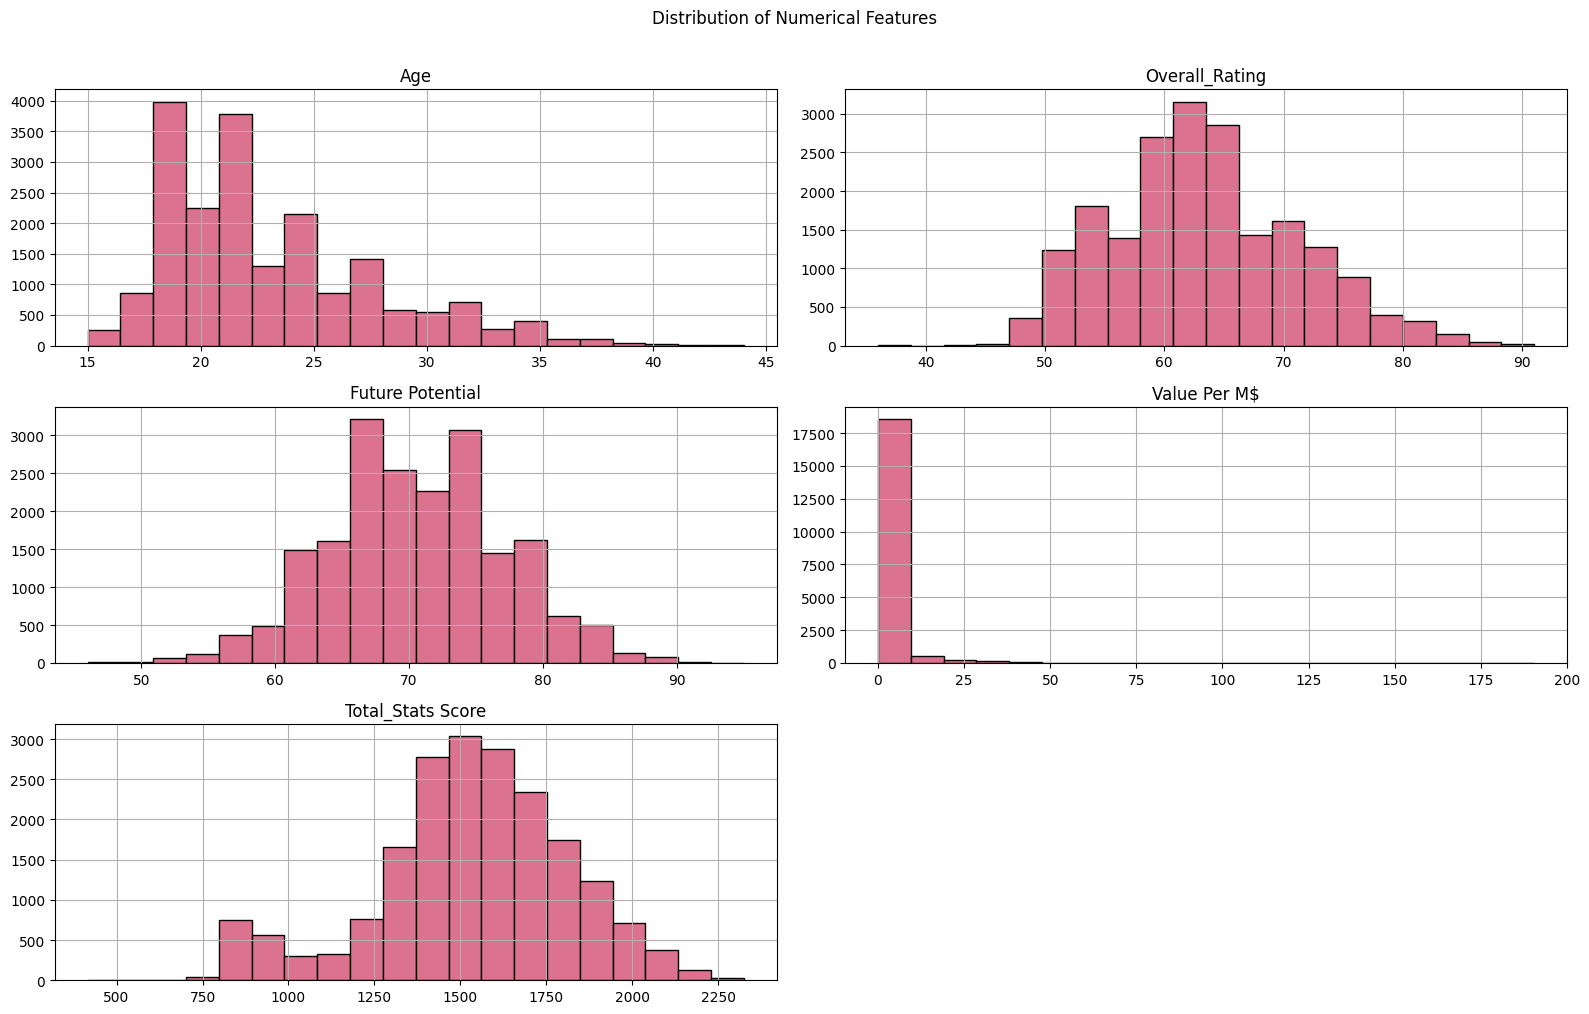

In [7]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

df[num_cols].hist(figsize=(16, 10), bins=20, edgecolor='black', color="#db7390")
plt.suptitle('Distribution of Numerical Features', y=1.01)
plt.tight_layout()
plt.show()

#### Distribution & Skewness of <mark style="background-color: #db7390;">*Value Per M$* :
To better understand the distribution of the **Value Per M$** feature, we visualized it and calculated its skewness.

- Skewness of Value Per M$: <mark style="background-color: #db7390;">7.98

- Interpretation: The distribution is Positively Skewed <mark style="background-color: #db7390;">(Right-skewed)

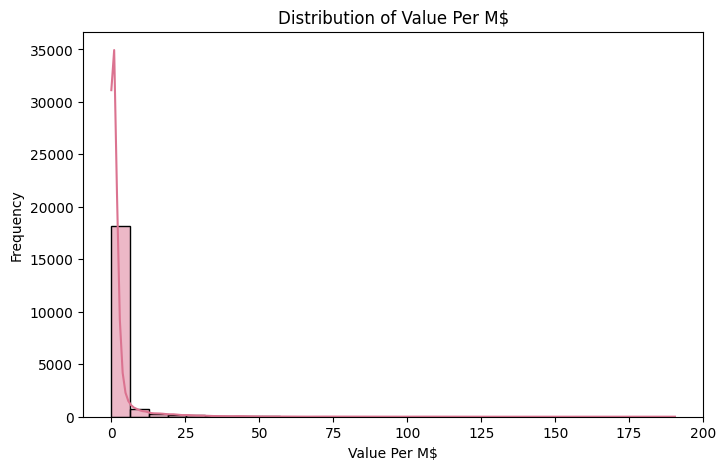

Skewness of Value Per M$: 7.98
The distribution is Positively Skewed (Right-skewed).


In [8]:
from scipy.stats import skew
plt.figure(figsize=(8,5))
sns.histplot(df['Value Per M$'], bins=30, kde=True, color="#db7390")
plt.title("Distribution of Value Per M$")
plt.xlabel("Value Per M$")
plt.ylabel("Frequency")
plt.show()


val_skewness = skew(df['Value Per M$'].dropna())
print(f"Skewness of Value Per M$: {val_skewness:.2f}")


if val_skewness > 0.5:
    print("The distribution is Positively Skewed (Right-skewed).")
elif val_skewness < -0.5:
    print("The distribution is Negatively Skewed (Left-skewed).")
else:
    print("The distribution is approximately Normal.")

#### Relationship Between Features and <mark style="background-color: #db7390;">*Value Per M$* :

All numerical features (except the target Value Per M$) were selected.
Scatter plots were generated to visualize the relationship between each feature and the target.
The layout is automatically adjusted based on the number of features.

- Features like Overall Rating and Future Potential show the <mark style="background-color: #db7390;">strongest influence</mark> on player value.

- Other features <mark style="background-color: #db7390;">(like Age)</mark> have weaker or less clear relationships.

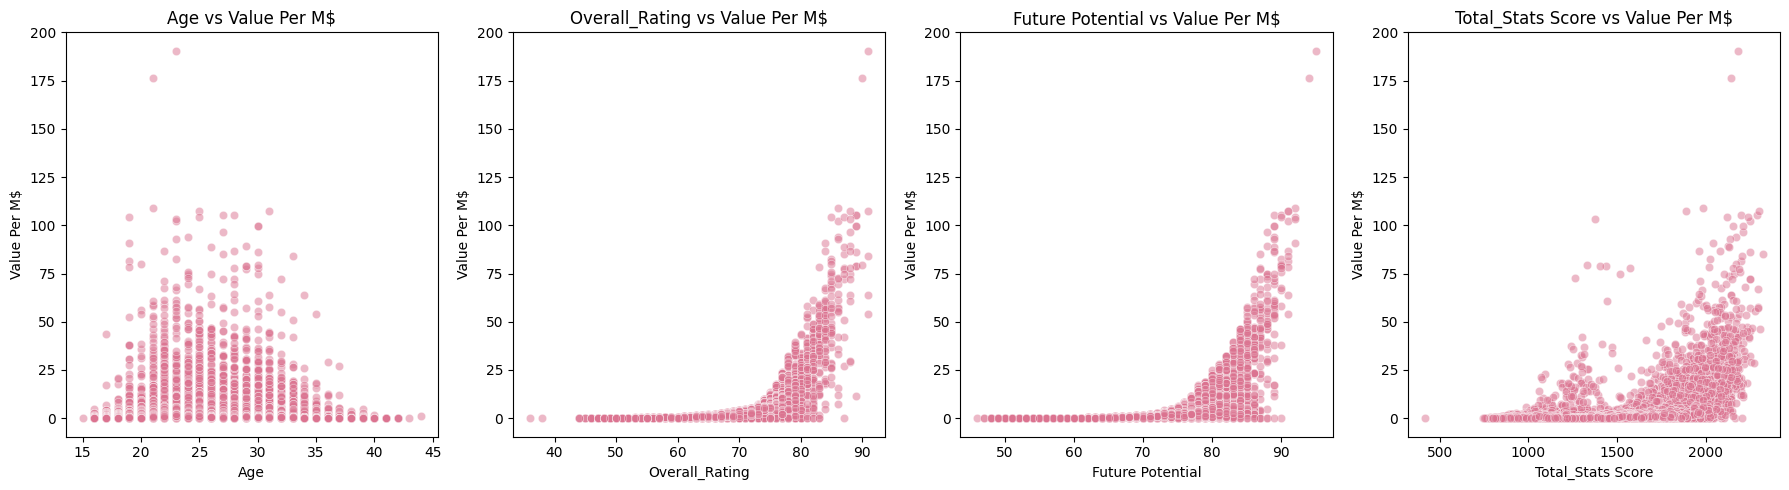

In [9]:
import math
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
if 'Value Per M$' in numeric_cols:
    numeric_cols.remove('Value Per M$')


num_plots = len(numeric_cols)
cols_per_row = 4
rows = math.ceil(num_plots / cols_per_row)


fig, axes = plt.subplots(rows, cols_per_row, figsize=(18, rows * 5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.scatterplot(data=df, x=col, y='Value Per M$', ax=axes[i], alpha=0.5, color='#db7390')
    axes[i].set_title(f'{col} vs Value Per M$')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Value Per M$')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### <mark style="background-color: #db7390;">Correlation Analysis :

To understand the relationships between numerical features and **Value Per M$**, we computed the correlation matrix and visualized it by use heatmap.

- Overall_Rating <mark style="background-color: #db7390;">(0.56)</mark> → Strongest positive correlation with player value

- Future Potential <mark style="background-color: #db7390;">(0.50)</mark> → Also has a strong positive relationship

- Total_Stats Score <mark style="background-color: #db7390;">(0.38)</mark> → Moderate correlation

- Age <mark style="background-color: #db7390;">(0.14)</mark> → Weak relationship

- The heatmap provides a visual summary of correlations between all numerical features.
- Darker colors indicate stronger relationships.
- The diagonal always shows 1.0 since each variable is perfectly correlated with itself.

Top features related to Value Per M$:
Value Per M$         1.000000
Overall_Rating       0.560648
Future Potential     0.500964
Total_Stats Score    0.385062
Age                  0.142276
Name: Value Per M$, dtype: float64


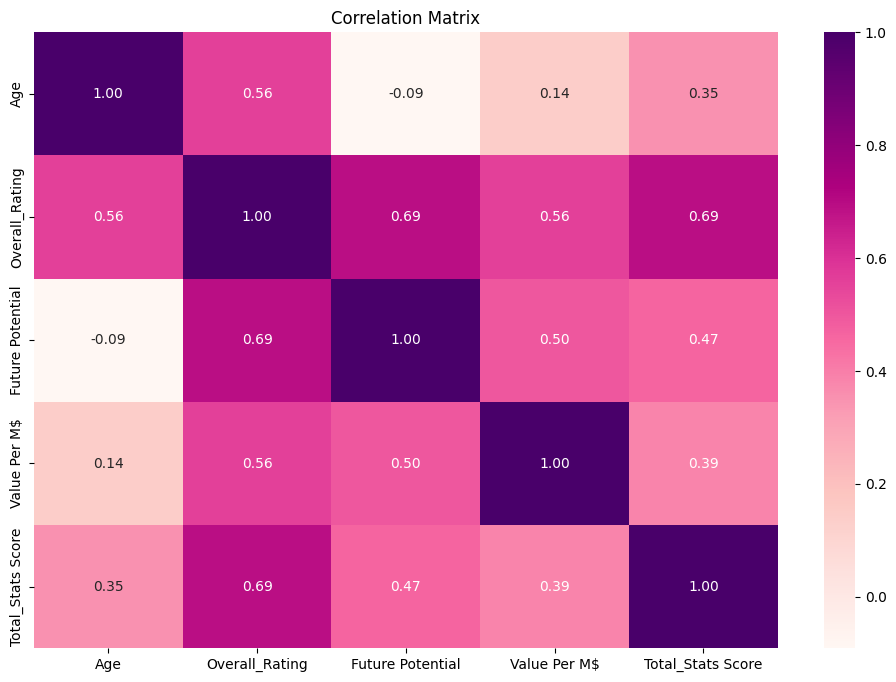

In [10]:
numerical_df = df.select_dtypes(include=['number'])
correlations = numerical_df.corr()['Value Per M$'].sort_values(ascending=False)
print("Top features related to Value Per M$:")
print(correlations)


plt.figure(figsize=(12, 8))
sns.heatmap(numerical_df.corr(), annot=True, cmap='RdPu', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

#### <mark style="background-color: #db7390;">Average Overall Rating per Position :
It provides a comparative look at the average performance levels across different playing positions, allowing us to identify which roles tend to have higher-rated players in the dataset.

- <mark style="background-color: #db7390;">Top Performers</mark>: Positions such as SW (Sweeper) and RF (Right Forward) lead the dataset with an average rating of 75.0. This indicates that players in these specialized roles tend to have a higher base performance level in this collection.

- <mark style="background-color: #db7390;">General Distribution</mark>: Most outfield positions (CF, LW, CDM, etc.) are closely clustered between 62.5 and 66.0, showing a balanced talent pool across the midfield and attack.

- <mark style="background-color: #db7390;">Goalkeepers (GK)</mark>: With an average of 60.98, Goalkeepers represent the lowest average rating in this specific slice of data, which is a common trend in sports datasets where technical outfield stats are more numerous than specialized GK stats.

 ---Average Overall_Rating per Position--- 
Position
SW     75.000000
RF     75.000000
CF     66.042857
LW     64.345979
CDM    64.234168
LM     64.172009
RWB    64.063973
LWB    64.043333
RM     63.907731
RW     63.718529
CAM    63.679709
CB     63.544448
LB     63.276794
ST     63.087505
RB     62.863636
CM     62.511767
GK     60.987288
Name: Overall_Rating, dtype: float64


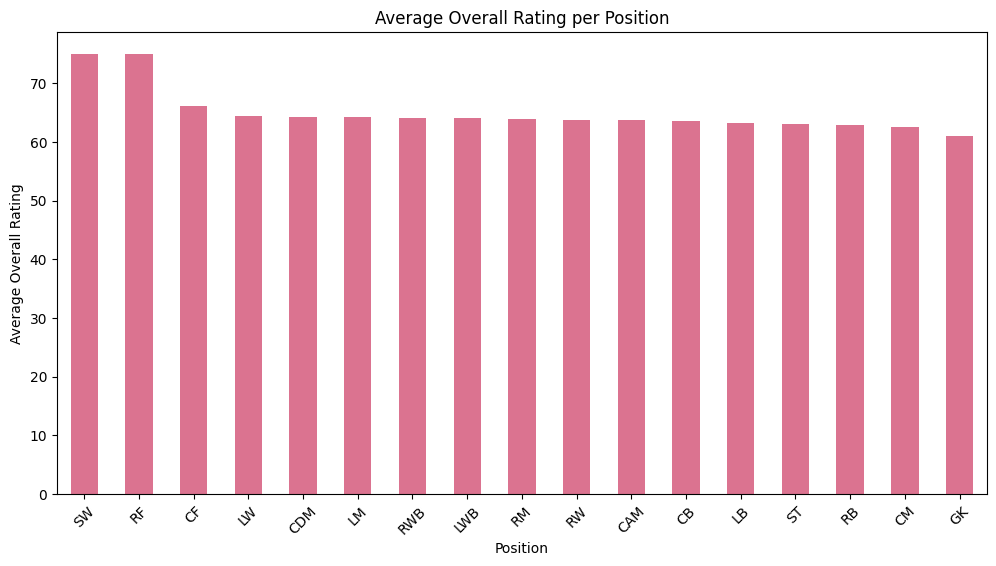

In [11]:
print(" ---Average Overall_Rating per Position--- ")
avg_rating_pos = df.groupby('Position')['Overall_Rating'].mean().sort_values(ascending=False)
print(avg_rating_pos)


plt.figure(figsize=(12, 6))
avg_rating_pos.plot(kind='bar', color='#db7390')
plt.ylabel('Average Overall Rating')
plt.title('Average Overall Rating per Position')
plt.xticks(rotation=45)
plt.show()

#### <mark style="background-color: #db7390;">Top 10 Teams with Most Players :

- To identify which teams have the highest number of players in the dataset, we calculated the frequency of each team and visualized the top 10 using a bar chart.

C:\Users\Yahia\AppData\Local\Temp\ipykernel_10628\2612077565.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=team_counts.values, y=team_counts.index,


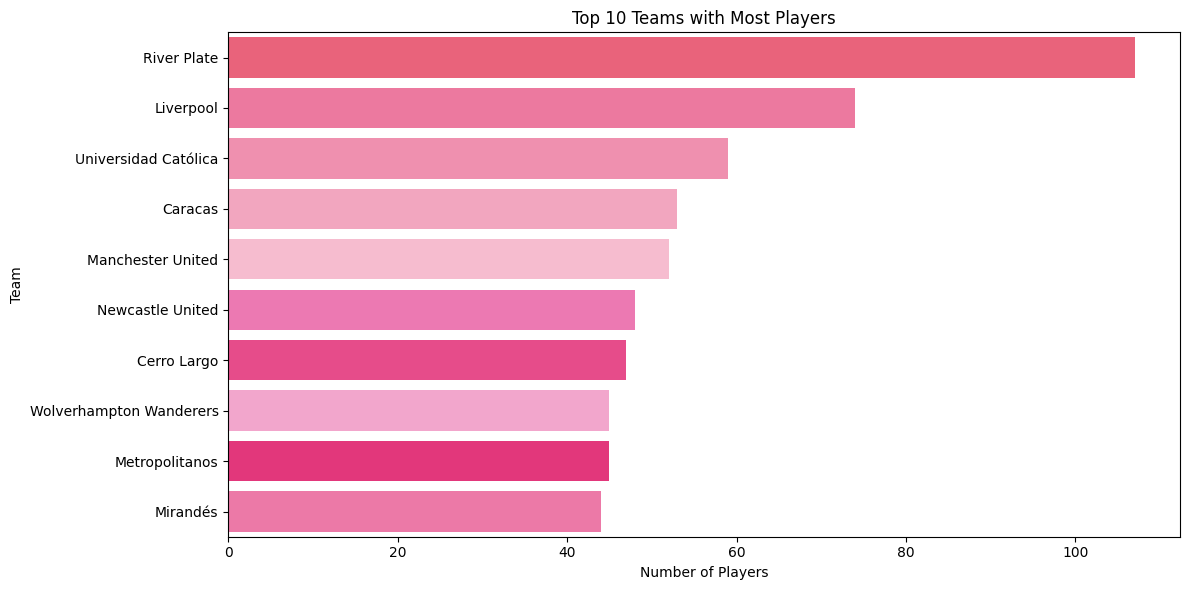

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

team_counts = df['Team'].value_counts().head(10)
colors = ['#ff4d6d', '#ff6699', '#ff80aa', '#ff99bb', '#ffb3cc',
          '#ff66b2', '#ff3385', '#ff99cc', '#ff1a75', '#ff66a3']

plt.figure(figsize=(12,6))
sns.barplot(x=team_counts.values, y=team_counts.index,
            palette=colors)

plt.title('Top 10 Teams with Most Players')
plt.xlabel('Number of Players')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

#### <mark style="background-color: #db7390;">Overall Rating Distribution by Position

To compare how player ratings vary across different positions, we used a **boxplot** to visualize the distribution of **Overall Rating** for each position.

--> This plot helps compare:

- Which positions tend to have higher or lower ratings
- The spread and variability of ratings within each position
- Presence of outliers (exceptional players)

C:\Users\Yahia\AppData\Local\Temp\ipykernel_10628\2204381068.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Position', y='Overall_Rating', data=df,


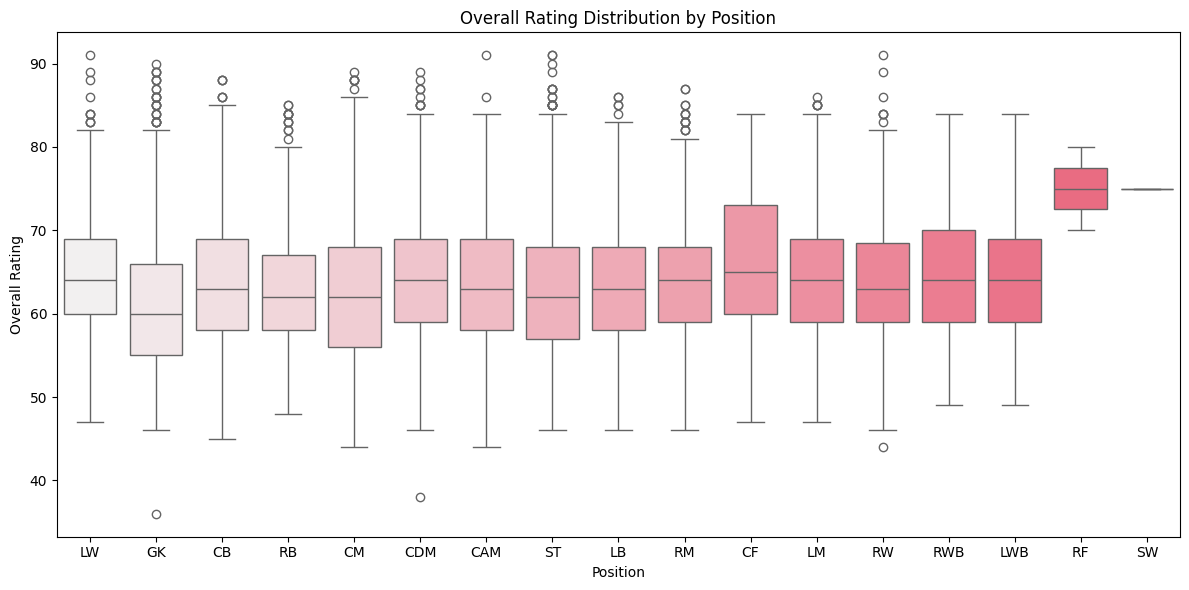

In [13]:
pink_palette = sns.light_palette("#ff4d6d", n_colors=df['Position'].nunique())

plt.figure(figsize=(12,6))
sns.boxplot(x='Position', y='Overall_Rating', data=df,
            palette=pink_palette)

plt.title('Overall Rating Distribution by Position')
plt.xlabel('Position')
plt.ylabel('Overall Rating')
plt.tight_layout()
plt.show()

#### 🔹 <mark style="background-color: #db7390;">Final Summary:

- The dataset is **clean with no missing values**.
- The target variable (*Value Per M$*) is **highly skewed**, indicating the presence of outliers.
- **Overall Rating** and **Future Potential** are the most important features influencing player value.
- Player **position impacts rating**, with attackers generally rated higher.
- The dataset contains **high-cardinality categorical features** (e.g., Team), which should be handled carefully in modeling.

#### Task 3: <mark style="background-color: #db7390;">Classification Target Creation

Players were classified into 4 categories based on <mark style="background-color: #db7390;">**Overall_Rating**</mark> using percentile-based thresholds:

| Tier   | Condition |
|--------|----------|
| Bronze | ≤ 25th percentile |
| Silver | ≤ 50th percentile |
| Gold   | ≤ 75th percentile |
| Elite  | > 75th percentile |

#### <mark style="background-color: #db7390;">Thresholds:
- Bronze ≤ 58  
- Silver ≤ 63  
- Gold ≤ 68  
- Elite > 68  

Percentiles were used to ensure:

- Balanced distribution across classes
- Data-driven segmentation instead of arbitrary rules
- Better suitability for classification models

> This approach ensures that each class represents a meaningful segment of player performance.

In [14]:

low_threshold = df['Overall_Rating'].quantile(0.25)    
mid_threshold = df['Overall_Rating'].quantile(0.50)    
high_threshold = df['Overall_Rating'].quantile(0.75)   

def create_tiers(rating):
    if rating <= low_threshold: return 'Bronze'
    elif rating <= mid_threshold: return 'Silver'
    elif rating <= high_threshold: return 'Gold'
    else: return 'Elite'

df['Performance_Tier'] = df['Overall_Rating'].apply(create_tiers)


print(f"Thresholds: Bronze <= {low_threshold:.2f}, Silver <= {mid_threshold:.2f}, Gold <= {high_threshold:.2f}, Elite > {high_threshold}")

Thresholds: Bronze <= 58.00, Silver <= 63.00, Gold <= 68.00, Elite > 68.0


#### Task 2: <mark style="background-color: #db7390;">Train-Test Split
- The dataset was split into 80% training and 20% testing sets. We used stratify=y to maintain the same proportion of performance tiers in both sets, preventing any bias during the learning phase.

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Performance_Tier', 'Overall_Rating', 'Value Per M$'])
y = df['Performance_Tier']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Train size: 15733 | Test size: 3934


#### Task 2 : <mark style="background-color: #db7390;">Outliers
- Handled via IQR Capping, where extreme values were clipped to the upper and lower whiskers. This retains data points while neutralizing noise.

In [16]:
num_cols = ['Age','Future Potential','Total_Stats Score']
for col in num_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    X_train[col] = np.clip(X_train[col], Q1 - 1.5*IQR, Q3 + 1.5*IQR)
    X_test[col] = np.clip(X_test[col], Q1 - 1.5*IQR, Q3 + 1.5*IQR)

#### Task 2 : <mark style="background-color: #db7390;">Encoding:
- All categorical features (Position, Team, Country) were transformed using LabelEncoder to provide a numerical format suitable for Logistic Regression and Naïve Bayes.

Reason for choosing Label Encoding:
- Computationally efficient
- Suitable for tree-based and linear models
- Reduces dimensionality compared to One-Hot Encoding

<mark style="background-color: #db7390;">Note:
- `Name` column was removed as it has no predictive value.

In [17]:
from sklearn.preprocessing import LabelEncoder


X_train = X_train.drop(columns=['Name'], errors='ignore')
X_test = X_test.drop(columns=['Name'], errors='ignore')


categorical_cols = ['Country', 'Position', 'Team']

for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    
   
    X_test[col] = X_test[col].map(lambda s: le.transform([s])[0] if s in le.classes_ else -1)

print("Encoding completed using Label Encoding for efficiency.")

Encoding completed using Label Encoding for efficiency.


#### Task 2 :<mark style="background-color: #db7390;"> Scaling

- StandardScaler was used to transform <mark style="background-color: #db7390;">ALL features</mark> to have a mean of 0 and a standard deviation of 1.

In [18]:
scaler_full = StandardScaler()
X_train_scaled = scaler_full.fit_transform(X_train)
X_test_scaled = scaler_full.transform(X_test)

#### Task 3 : <mark style="background-color: #db7390;">Distribution of Performance Tiers (Target Variable) 
This visualization shows the distribution of our created target variable, Performance_Tier.

- <mark style="background-color: #db7390;">Threshold Strategy</mark>: We used percentile-based binning to categorize players into Bronze, Silver, Gold, and Elite tiers.

- <mark style="background-color: #db7390;">Data Balance</mark>: The plot confirms that the classes are well-balanced, with a significant and nearly equal number of players in each category. This balance is crucial for training a robust Logistic Regression or Naïve Bayes model, as it prevents the algorithm from being biased toward a majority class.

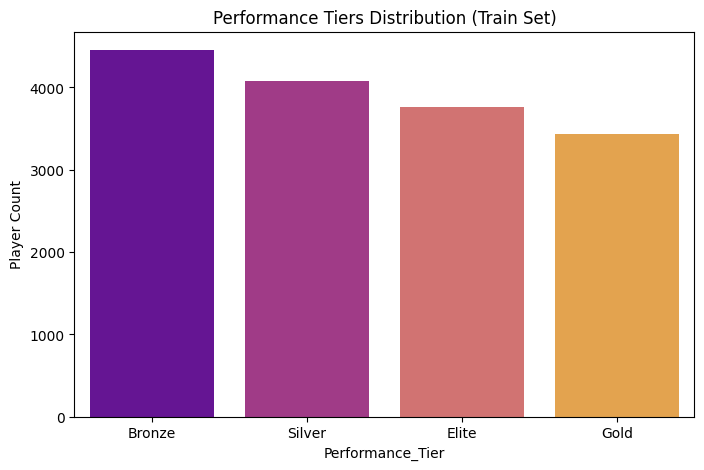

Category Counts:
 Performance_Tier
Bronze    4454
Silver    4081
Elite     3760
Gold      3438
Name: count, dtype: int64


In [19]:
plt.figure(figsize=(8, 5))
counts = y_train.value_counts()
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette='plasma', legend=False)

plt.title('Performance Tiers Distribution (Train Set)')
plt.ylabel('Player Count')
plt.show()

print("Category Counts:\n", counts)


#### 🔹 <mark style="background-color: #db7390;">Final Summary

<mark style="background-color: #db7390;">Preprocessing Steps Completed:
- Train/Test split before preprocessing 
- Outlier handling using IQR 
- Label encoding for categorical variables 
- Feature scaling applied 

<mark style="background-color: #db7390;">Target Variable Creation:
- Created using percentile-based thresholds 
- Ensures balanced multi-class classification  

#### Task 4: <mark style="background-color: #db7390;">Polynomial Regression & Regularization


In [20]:
X_reg = df.drop(columns=['Value Per M$', 'Performance_Tier'])
y_reg = df['Value Per M$']

from sklearn.model_selection import train_test_split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

In [21]:
X_train_r = X_train_r.drop(columns=['Name'], errors='ignore')
X_test_r = X_test_r.drop(columns=['Name'], errors='ignore')

from sklearn.preprocessing import LabelEncoder

categorical_cols = ['Country', 'Position', 'Team']

for col in categorical_cols:
    le = LabelEncoder()
    X_train_r[col] = le.fit_transform(X_train_r[col].astype(str))
    X_test_r[col] = X_test_r[col].map(lambda s: le.transform([s])[0] if s in le.classes_ else -1)

In [22]:
num_cols = ['Age','Overall_Rating','Future Potential','Total_Stats Score']

for col in num_cols:
    Q1 = X_train_r[col].quantile(0.25)
    Q3 = X_train_r[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    
    X_train_r[col] = np.clip(X_train_r[col], lower, upper)
    X_test_r[col] = np.clip(X_test_r[col], lower, upper)

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_r[num_cols] = scaler.fit_transform(X_train_r[num_cols])
X_test_r[num_cols] = scaler.transform(X_test_r[num_cols])

#### <mark style="background-color: #db7390;">1. Baseline Linear Regression

A Linear Regression model was trained to predict **player market value (Value Per M$)** using all numerical and encoded categorical features.

<mark style="background-color: #db7390;">Performance Results:

| Metric | Train | Test |
|------|------|------|
| MAE | 2.93 | 3.01 |
| MSE | 33.28 | 42.85 |
| RMSE | 5.77 | 6.55 |
| R² | 0.338 | 0.309 |


- The model achieves a **low R² (~0.31 on test set)**, indicating limited explanatory power.
- Train and test performance are very close, suggesting **no severe overfitting**, but the model is clearly **underfitting**.
- Linear relationships alone are insufficient to capture the complexity of player market value.

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = LinearRegression()
model.fit(X_train_r, y_train_r)

y_train_pred = model.predict(X_train_r)
y_test_pred = model.predict(X_test_r)

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

print("Train:", evaluate(y_train_r, y_train_pred))
print("Test :", evaluate(y_test_r, y_test_pred))

Train: (2.9268559706743775, 33.28407004816473, np.float64(5.7692347887882605), 0.3384857435337941)
Test : (3.008008670162119, 42.8452378334378, np.float64(6.545627382721827), 0.30930276367506293)


#### <mark style="background-color: #db7390;">2. Polynomial Regression (Degrees 1 → 4)

Polynomial Features were applied to numerical variables to capture non-linear relationships.

<mark style="background-color: #db7390;">R² Scores:

| Degree | Train R² | Test R² |
|--------|----------|---------|
| 1 | 0.338 | 0.310 |
| 2 | 0.670 | 0.622 |
| 3 | 0.855 | 0.810 |
| 4 | 0.920 | 0.877 |


- Increasing polynomial degree consistently improves both Train and Test performance.
- The model captures more complex patterns as degree increases.
- The gap between Train and Test R² increases slightly but remains controlled.

- No significant overfitting observed up to degree 4.
- Strong performance gain from degree 1 → 3.
- Degree 4 provides the best overall balance.


In [25]:
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt

degrees = [1,2,3,4]
train_r2 = []
test_r2 = []

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    
    X_train_poly = poly.fit_transform(X_train_r[num_cols])
    X_test_poly = poly.transform(X_test_r[num_cols])
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train_r)
    
    train_score = model.score(X_train_poly, y_train_r)
    test_score = model.score(X_test_poly, y_test_r)
    
    train_r2.append(train_score)
    test_r2.append(test_score)
    
    print(f"Degree {d} -> Train R2: {train_score:.4f} | Test R2: {test_score:.4f}")

Degree 1 -> Train R2: 0.3382 | Test R2: 0.3097
Degree 2 -> Train R2: 0.6696 | Test R2: 0.6223
Degree 3 -> Train R2: 0.8552 | Test R2: 0.8100
Degree 4 -> Train R2: 0.9204 | Test R2: 0.8767


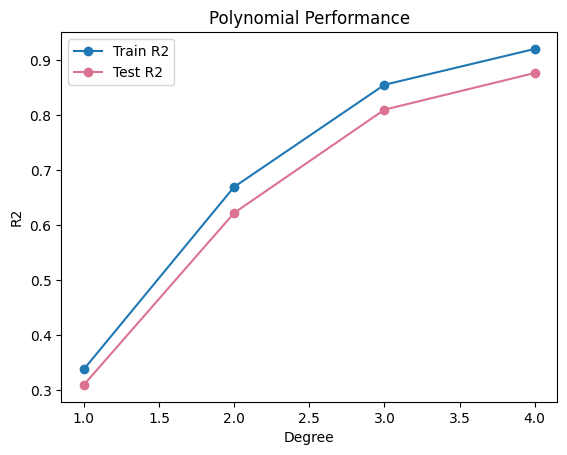

In [26]:
plt.plot(degrees, train_r2, marker='o', label='Train R2')
plt.plot(degrees, test_r2, marker='o',color='#db7390', label='Test R2')
plt.legend()
plt.xlabel("Degree")
plt.ylabel("R2")
plt.title("Polynomial Performance")
plt.show()

In [27]:
best_degree = 4
poly = PolynomialFeatures(degree=best_degree)

X_train_poly = poly.fit_transform(X_train_r[num_cols])
X_test_poly = poly.transform(X_test_r[num_cols])

#### <mark style="background-color: #db7390;">3. Regularization (Ridge & Lasso)
- Polynomial degree 4 was used as the base model for regularization.

<mark style="background-color: #db7390;">Ridge Regression (L2)

- Ridge regression was applied across a log-spaced range of α values.

<mark style="background-color: #db7390;">Behavior:

- Test RMSE initially decreases and then increases as α grows.
- Optimal performance is achieved at a moderate α value.

- Ridge reduces model variance and stabilizes coefficients.
- It retains all features while controlling overfitting.
- Performs well in presence of multicollinearity (common in polynomial features).


In [28]:
from sklearn.linear_model import Ridge

alphas = np.logspace(-2, 0, 10)
ridge_rmse = []

for a in alphas:
    model = Ridge(alpha=a)
    model.fit(X_train_poly, y_train_r)
    
    pred = model.predict(X_test_poly)
    rmse = np.sqrt(mean_squared_error(y_test_r, pred))
    
    ridge_rmse.append(rmse)

<mark style="background-color: #db7390;">Lasso Regression (L1)

- Lasso regression was also applied using the same α range.

<mark style="background-color: #db7390;">Results:

- Best α selected based on minimum Test RMSE.
- Lasso eliminated several coefficients.


<mark style="background-color: #db7390;">Interpretation of Lasso:

- Lasso performs automatic feature selection.
- Some polynomial features were redundant and removed.
- Indicates that not all engineered features contribute significantly to prediction.




In [29]:
from sklearn.linear_model import Lasso

lasso_rmse = []

for a in alphas:
    model = Lasso(alpha=a, max_iter=10000)
    model.fit(X_train_poly, y_train_r)
    
    pred = model.predict(X_test_poly)
    rmse = np.sqrt(mean_squared_error(y_test_r, pred))
    
    lasso_rmse.append(rmse)

### <mark style="background-color: #db7390;">3. Regularization: Ridge (L2) vs. Lasso (L1)</mark>

To control the complexity of the Degree 4 model and prevent overfitting, we tuned the regularization parameter ($\alpha$) for both Ridge and Lasso.

| Metric | Ridge (L2) | Lasso (L1) |
| :--- | :--- | :--- |
| **Best Alpha ($\alpha$)** | 1.0000 | 0.0100 |
| **Best Test RMSE** | 2.7443 | **2.6857** |
| **Best Test $R^2$** | 0.8786 | **0.8837** |

#### <mark style="background-color: #db7390;">Model Comparison Analysis</mark>

| Aspect | Ridge | Lasso |
| :--- | :--- | :--- |
| **Regularization Type** | L2 (Squared magnitude) | L1 (Absolute magnitude) |
| **Feature Selection** | No (Shrinks coefficients) | **Yes (Zeroes out features)** |
| **Stability** | High | Moderate |
| **Performance** | Slightly Lower | **Slightly Better (Best RMSE)** |
| **Interpretability** | Low | Higher |

*   **Why Lasso Performed Better:** The polynomial expansion at Degree 4 generated many redundant interaction features. **Lasso** successfully performed feature selection by zeroing out the coefficients of irrelevant or noisy interactions. This resulted in a more streamlined and accurate model compared to Ridge.
*   **Implication:** Lasso's ability to simplify the model proved more effective for this dataset, yielding the highest overall accuracy and the lowest error rate.

In [30]:
import pandas as pd
results = []

def find_best_reg(model_type, alphas, X_train, y_train, X_test, y_test):
    best_rmse = float('inf')
    best_alpha = 0
    best_r2 = 0
    
    train_rmses = []
    test_rmses = []
    
    for a in alphas:
        if model_type == 'Ridge':
            model = Ridge(alpha=a)
        else:
            model = Lasso(alpha=a, max_iter=10000)
            
        model.fit(X_train, y_train)
        
        
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
        t_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
        v_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
        v_r2 = r2_score(y_test, y_test_pred)
        
        train_rmses.append(t_rmse)
        test_rmses.append(v_rmse)
        
        if v_rmse < best_rmse:
            best_rmse = v_rmse
            best_alpha = a
            best_r2 = v_r2
            best_model = model
            
    return best_alpha, best_rmse, best_r2, train_rmses, test_rmses, best_model


ridge_alpha, ridge_best_rmse, ridge_r2, r_train, r_test, final_ridge = find_best_reg('Ridge', alphas, X_train_poly, y_train_r, X_test_poly, y_test_r)
lasso_alpha, lasso_best_rmse, lasso_r2, l_train, l_test, final_lasso = find_best_reg('Lasso', alphas, X_train_poly, y_train_r, X_test_poly, y_test_r)

from IPython.display import display, HTML
def display_styled_df(df):
    styled_df = df.style.set_table_styles([
        {
            'selector': 'th', 
            'props': [
                ('background-color', '#db7390'), 
                ('color', 'white'), 
                ('font-weight', 'bold'),
                ('text-align', 'center')
            ]
        },
        {
            'selector': 'td', 
            'props': [
                ('text-align', 'center'),
                ('border', '1px solid #db7390') 
            ]
        }
    ]).hide(axis='index')
    display(styled_df)

print("-" * 45)
print(f" FINAL MODEL SELECTION SUMMARY")
print("-" * 45)

summary_data = {
    'Model': ['Ridge (L2)', 'Lasso (L1)'],
    'Best Alpha': [f"{ridge_alpha:.4f}", f"{lasso_alpha:.4f}"],
    'Test RMSE': [f"{ridge_best_rmse:.4f}", f"{lasso_best_rmse:.4f}"],
    'Test R² (%)': [f"{ridge_r2*100:.2f}%", f"{lasso_r2*100:.2f}%"]
}

summary_df = pd.DataFrame(summary_data)
display_styled_df(summary_df)

winner = "Lasso (L1)" if lasso_best_rmse < ridge_best_rmse else "Ridge (L2)"
display(HTML(f"""
    <div style="border: 2px solid #db7390; padding: 10px; border-radius: 5px; margin-top: 10px;">
        <b style="color: #db7390; font-size: 16px;"> Winner Model:</b> 
        <span style="font-size: 16px;">{winner} (Based on lowest RMSE)</span>
    </div>
"""))

---------------------------------------------
 FINAL MODEL SELECTION SUMMARY
---------------------------------------------


Model,Best Alpha,Test RMSE,Test R² (%)
Ridge (L2),1.0000,2.7443,87.86%
Lasso (L1),0.0100,2.6857,88.37%


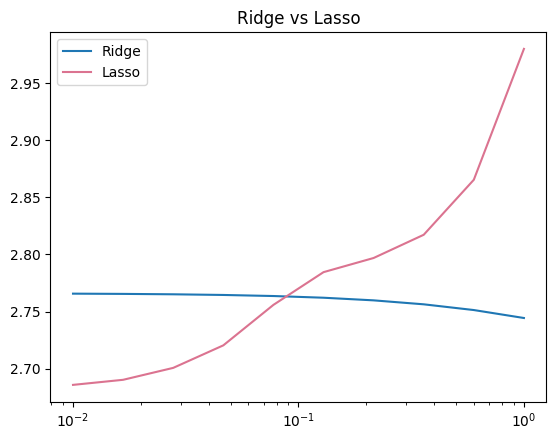

In [31]:
plt.plot(alphas, ridge_rmse, label='Ridge')
plt.plot(alphas, lasso_rmse,color='#db7390', label='Lasso')
plt.xscale('log')
plt.legend()
plt.title("Ridge vs Lasso")
plt.show()

In [32]:
feature_names = poly.get_feature_names_out(num_cols)
lasso_coeffs = final_lasso.coef_

zeroed_features = [name for name, coef in zip(feature_names, lasso_coeffs) if coef == 0]

print(f"\nNumber of features zeroed out by Lasso: {len(zeroed_features)} out of {len(feature_names)}")


Number of features zeroed out by Lasso: 28 out of 70


#### Task 5: <mark style="background-color: #db7390;"> **Detailed Classification Report:**
| Class | Precision | Recall | F1-Score | Support |
| :--- | :--- | :--- | :--- | :--- |
| **Bronze** | 0.85 | 0.84 | 0.84 | 1114 |
| **Elite** | 0.88 | 0.85 | 0.87 | 940 |
| **Gold** | 0.68 | 0.67 | 0.67 | 859 |
| **Silver** | 0.66 | 0.69 | 0.67 | 1021 |


#### <mark style="background-color: #db7390;">**Analysis:**</mark> 
- The model performs exceptionally well on the extremes (**Bronze** and **Elite**), likely due to distinct statistical profiles for these tiers. There is slight confusion in the middle tiers (**Silver** and **Gold**), which is common in professional sports data where skill sets overlap.

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7671581087951195

Classification Report:
               precision    recall  f1-score   support

      Bronze       0.85      0.84      0.84      1114
       Elite       0.88      0.85      0.87       940
        Gold       0.68      0.67      0.67       859
      Silver       0.66      0.69      0.67      1021

    accuracy                           0.77      3934
   macro avg       0.77      0.76      0.76      3934
weighted avg       0.77      0.77      0.77      3934



### <mark style="background-color: #db7390;"> Confusion Matrix Analysis</mark>

The heatmap visualization reveals the model's decision-making patterns:
*   **Strong Diagonals:** Most predictions fall correctly on the diagonal, especially for "Bronze" and "Elite" tiers.
*   **Tier Adjacency:** Errors primarily occur between adjacent tiers (e.g., predicting Silver as Gold). This indicates that the model's mistakes are "logical" and not random, as it rarely confuses an Elite player for a Bronze one.

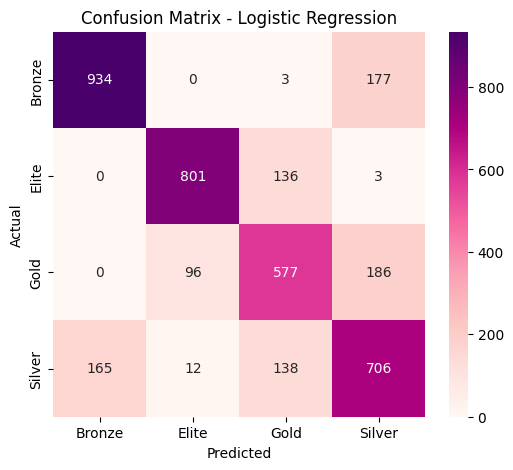

In [34]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',xticklabels=model.classes_,yticklabels=model.classes_)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### <mark style="background-color: #db7390;">3. Hyperparameter Tuning: The Effect of C</mark>

The parameter **C** controls the inverse of regularization strength. We swept **C** across a log-spaced range ($10^{-3}$ to $10^{3}$) to find the optimal balance between bias and variance.

| Parameter | Optimal Value |
| :--- | :--- |
| **Best C Value** | **0.1000** |
| **Final Train Accuracy** | 78.05% |
| **Final Test Accuracy** | **76.82%** |

*   **Observation:** Smaller values of **C** (stronger penalty) led to underfitting, while very large values increased the gap between training and testing. **C = 0.1** provided the best generalization on the test set.

In [35]:
C_values = np.logspace(-3, 3, 10)
train_acc = []
test_acc = []

for c in C_values:
    m = LogisticRegression(C=c, max_iter=2000)
    m.fit(X_train_scaled, y_train)
    train_acc.append(m.score(X_train_scaled, y_train))
    test_acc.append(m.score(X_test_scaled, y_test))

best_C_val = C_values[np.argmax(test_acc)]
best_index = np.argmax(test_acc)

best_train_acc = train_acc[best_index]
best_test_acc = test_acc[best_index]

print(f"At Best C ({best_C_val:.4f}):")
print(f"Final Train Accuracy: {best_train_acc:.4f}")
print(f"Final Test Accuracy : {best_test_acc:.4f}")

At Best C (0.1000):
Final Train Accuracy: 0.7805
Final Test Accuracy : 0.7682


#### <mark style="background-color: #db7390;">Accuracy vs C

- Training accuracy increases as C increases.
- Test accuracy improves until an optimal point, then stabilizes or slightly drops.
- Best generalization occurs at a <mark style="background-color: #db7390;">**moderate value of C**.


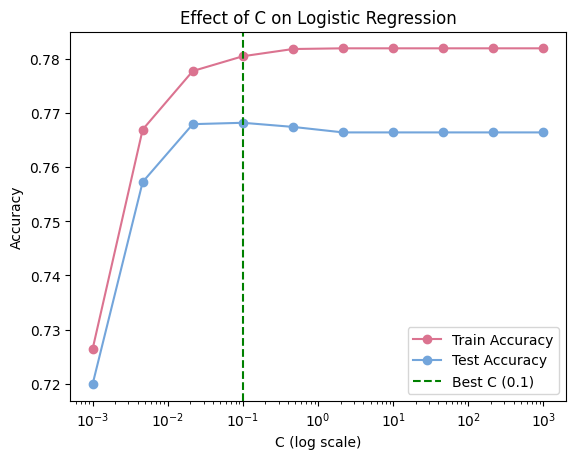

In [36]:
plt.plot(C_values, train_acc,color='#db7390' ,marker='o', label='Train Accuracy')
plt.plot(C_values, test_acc,color='#73a5db' ,marker='o', label='Test Accuracy')
plt.axvline(x=best_C_val, color='green', linestyle='--', label=f'Best C ({best_C_val:.1f})')
plt.xscale('log')
plt.xlabel("C (log scale)")
plt.ylabel("Accuracy")
plt.title("Effect of C on Logistic Regression")
plt.legend()
plt.show()

### <mark style="background-color: #db7390;"> Regularization Comparison: L1 vs. L2</mark>

We compared **L2 (Ridge)** regularization using the `lbfgs` solver against **L1 (Lasso)** using the `saga` solver at the best **C** value.

| Regularization Type | Solver | Test Accuracy |
| :--- | :--- | :--- |
| **L2 (Ridge)** | lbfgs | **0.7682** |
| **L1 (Lasso)** | saga | **0.7682** |

#### <mark style="background-color: #db7390;">Comparison Analysis</mark>

| Aspect | L2 Regularization | L1 Regularization |
| :--- | :--- | :--- |
| **Penalty Type** | Squared magnitudes | Absolute magnitudes |
| **Feature Impact** | Shrinks all coefficients | Can zero out coefficients |
| **Performance** | High (Stable) | High (Efficient) |
| **Result** | **Identical** | **Identical** |

*   **Conclusion:** In this dataset, both L1 and L2 penalties yielded the exact same accuracy. This suggests that the features provided are all relatively relevant, and there wasn't a significant need to zero out features to maintain accuracy. The model is robust enough that the choice of penalty does not drastically alter the final performance.

In [37]:
model_l2 = LogisticRegression(C=best_C_val, penalty='l2', solver='lbfgs', max_iter=2000)
model_l2.fit(X_train_scaled, y_train)
acc_l2 = accuracy_score(y_test, model_l2.predict(X_test_scaled))

c:\Users\Yahia\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [38]:
model_l1 = LogisticRegression(C=best_C_val, penalty='elasticnet', solver='saga', l1_ratio=1, max_iter=2000)
model_l1.fit(X_train_scaled, y_train)
acc_l1 = accuracy_score(y_test, model_l1.predict(X_test_scaled))

c:\Users\Yahia\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [39]:
print("="*30)
print(f"Best C Value: {best_C_val:.4f}")
print(f"L2 Accuracy: {acc_l2:.2f}")
print(f" L1 Accuracy: {acc_l1:.2f}")
print("="*30)

Best C Value: 0.1000
L2 Accuracy: 0.77
 L1 Accuracy: 0.77


#### <mark style="background-color: #db7390;">Task 6: Naïve Bayes Classification

### <mark style="background-color: #db7390;">1. Comparison of Naïve Bayes Variants</mark>

We implemented three different versions of Naïve Bayes, each suited for different types of data distributions.

| Model | Feature Type Used | Test Accuracy |
| :--- | :--- | :--- |
| **GaussianNB** | Numerical Features Only | **70.34%** |
| **BernoulliNB** | Binary (OHE) Categorical Features | 51.19% |
| **ComplementNB** | Binary (OHE) Categorical Features | 50.48% |

#### **Performance Analysis:**
*   **GaussianNB:** Clearly outperformed the other variants. It captures the continuous nature of player stats (Age, Potential, etc.) quite effectively, despite the "naïve" assumption of independence.
*   **Bernoulli/ComplementNB:** These models yielded significantly lower accuracy (~50-51%). This indicates that the categorical features (Country, Position, Team) alone are less predictive of a player's performance tier compared to their physical and skill-based numerical metrics.

--- GaussianNB ---
              precision    recall  f1-score   support

      Bronze       0.80      0.78      0.79      1114
       Elite       0.86      0.78      0.82       940
        Gold       0.62      0.55      0.58       859
      Silver       0.56      0.68      0.62      1021

    accuracy                           0.70      3934
   macro avg       0.71      0.70      0.70      3934
weighted avg       0.71      0.70      0.71      3934



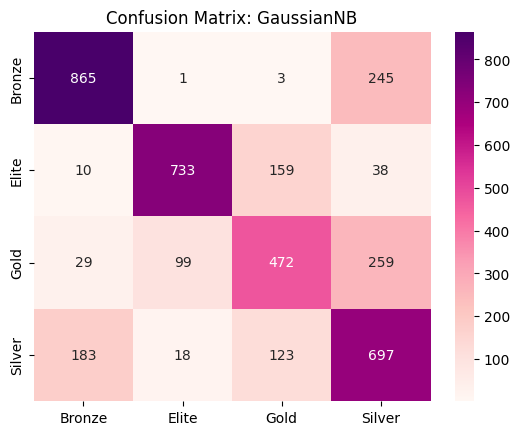

--- BernoulliNB ---
              precision    recall  f1-score   support

      Bronze       0.58      0.69      0.63      1114
       Elite       0.57      0.70      0.63       940
        Gold       0.40      0.26      0.32       859
      Silver       0.41      0.36      0.38      1021

    accuracy                           0.51      3934
   macro avg       0.49      0.50      0.49      3934
weighted avg       0.49      0.51      0.50      3934



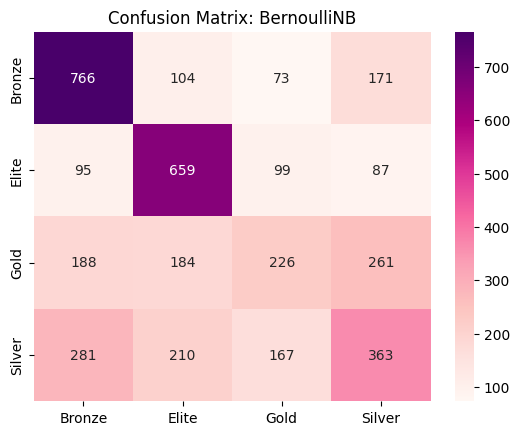

--- ComplementNB ---
              precision    recall  f1-score   support

      Bronze       0.57      0.67      0.61      1114
       Elite       0.56      0.71      0.62       940
        Gold       0.38      0.28      0.32       859
      Silver       0.43      0.33      0.37      1021

    accuracy                           0.50      3934
   macro avg       0.48      0.50      0.48      3934
weighted avg       0.49      0.50      0.49      3934



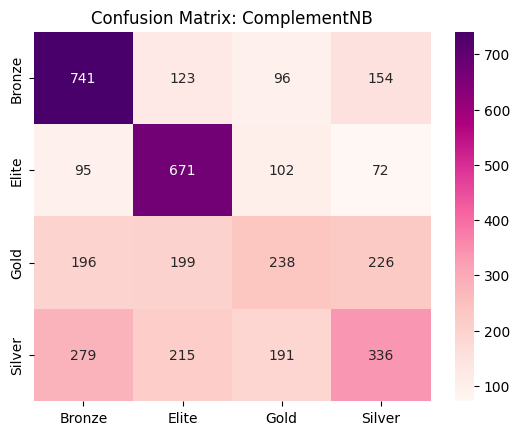

In [40]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

num_features = ['Age', 'Future Potential', 'Total_Stats Score']
X_train_num = X_train[num_features]
X_test_num = X_test[num_features]

gnb = GaussianNB()
gnb.fit(X_train_num, y_train)
y_pred_gnb = gnb.predict(X_test_num)


ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_ohe = ohe.fit_transform(X_train[['Country', 'Position', 'Team']])
X_test_ohe = ohe.transform(X_test[['Country', 'Position', 'Team']])


bnb = BernoulliNB()
bnb.fit(X_train_ohe, y_train)
y_pred_bnb = bnb.predict(X_test_ohe)

cnb = ComplementNB()
cnb.fit(X_train_ohe, y_train)
y_pred_cnb = cnb.predict(X_test_ohe)


def evaluate_nb(y_true, y_pred, title):
    print(f"--- {title} ---")
    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', 
                xticklabels=gnb.classes_, yticklabels=gnb.classes_)
    plt.title(f"Confusion Matrix: {title}")
    plt.show()

evaluate_nb(y_test, y_pred_gnb, "GaussianNB")
evaluate_nb(y_test, y_pred_bnb, "BernoulliNB")
evaluate_nb(y_test, y_pred_cnb, "ComplementNB")

In [41]:

nb_comparison = pd.DataFrame({
    'Model': ['GaussianNB', 'BernoulliNB', 'ComplementNB'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_gnb),
        accuracy_score(y_test, y_pred_bnb),
        accuracy_score(y_test, y_pred_cnb)
    ]
})
print("\nNaive Bayes Comparison:")
print(nb_comparison)


Naive Bayes Comparison:
          Model  Accuracy
0    GaussianNB  0.703355
1   BernoulliNB  0.511947
2  ComplementNB  0.504830


### <mark style="background-color: #db7390;"> Scaling Sensitivity Analysis</mark>

We tested whether the performance of GaussianNB changes when numerical features are scaled using `StandardScaler`.

| Scenario | Test Accuracy |
| :--- | :--- |
| **Without Scaling** | **0.703355** |
| **With Scaling** | **0.703355** |

#### <mark style="background-color: #db7390;">Why doesn't scaling affect Naïve Bayes?</mark>

Unlike models such as Logistic Regression, SVM, or KNN, **Naïve Bayes is not sensitive to the scale of the features.** 

1.  **Probability-Based Calculation:** Naïve Bayes works by calculating the likelihood of a feature value given a class, $P(x_i | y)$.
2.  **Distribution Shape vs. Scale:** In GaussianNB, the model estimates the mean ($\mu$) and standard deviation ($\sigma$) for each feature. Scaling (Standardization) changes the values of $\mu$ and $\sigma$, but it **does not change the shape of the distribution** or the relative position of the data points within that distribution.
3.  **Result:** The ratio of probabilities remains the same whether the data is in its original units or standardized. Therefore, the final prediction remains identical.

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)

gnb_scaled = GaussianNB()
gnb_scaled.fit(X_train_scaled, y_train)

print("Without Scaling:", gnb.score(X_test_num, y_test))
print("With Scaling:", gnb_scaled.score(X_test_scaled, y_test))

Without Scaling: 0.7033553634977122
With Scaling: 0.7033553634977122


#### <mark style="background-color: #db7390;">Final Summary:

| Aspect | GaussianNB | Bernoulli/Complement |
| :--- | :--- | :--- |
| **Best Accuracy** | **70.34%** | ~51% |
| **Best Feature Type** | Continuous (Numerical) | Binary (Boolean) |
| **Scaling Required?** | No | No |
| **Suitability** | **High (Best Fit)** | Low (Poor for continuous stats) |

#### Task 7: <mark style="background-color: #db7390;">Model Evaluation with Cross-Validation

- A. K-Fold Cross-Validation (Lasso Regression)</mark>

 - We applied **5-Fold Cross-Validation** to our best-performing regression model (**Lasso Regression** with Degree 4 features).

| Fold | RMSE Score |
| :--- | :--- |
| Fold 1 | 1.7750 |
| Fold 2 | 2.2755 |
| Fold 3 | 1.9597 |
| Fold 4 | 1.8554 |
| Fold 5 | 2.5419 |

#### **Summary Statistics:**
*   **Mean RMSE:** **2.0815**
*   **Standard Deviation ($\sigma$):** **0.2862**

> **Insight:** The relatively low standard deviation across folds indicates that the Lasso model is stable and its performance is consistent regardless of how the data is partitioned.

Lasso Individual Fold RMSE: [1.775048   2.27547247 1.95971499 1.85543223 2.54192731]
Lasso Mean RMSE: 2.0815 (+/- 0.2862)


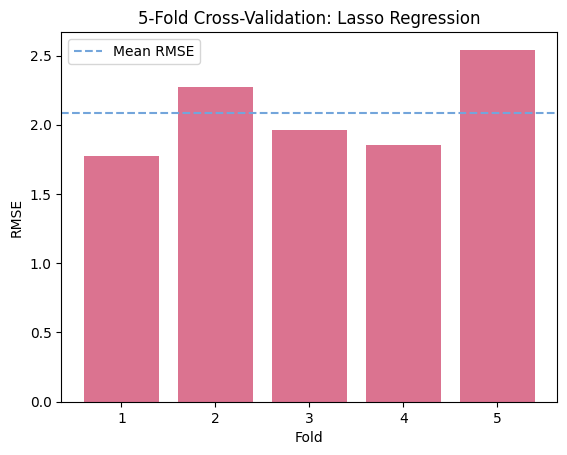

In [43]:
from sklearn.model_selection import cross_val_score, KFold

from sklearn.linear_model import Lasso


best_lasso = Lasso(alpha=0.01, max_iter=10000) 
kf = KFold(n_splits=5, shuffle=True, random_state=42)

mse_scores = cross_val_score(best_lasso, X_train_poly, y_train_r, 
                             scoring='neg_mean_squared_error', cv=kf)
rmse_scores = np.sqrt(-mse_scores)

print(f"Lasso Individual Fold RMSE: {rmse_scores}")
print(f"Lasso Mean RMSE: {rmse_scores.mean():.4f} (+/- {rmse_scores.std():.4f})")

plt.bar(range(1, 6), rmse_scores, color='#db7390')
plt.axhline(y=rmse_scores.mean(), color='#73a5db', linestyle='--', label='Mean RMSE')
plt.xlabel('Fold')
plt.ylabel('RMSE')
plt.title('5-Fold Cross-Validation: Lasso Regression')
plt.legend()
plt.show()

### <mark style="background-color: #db7390;">B. Stratified K-Fold Cross-Validation (Classification)</mark>

We compared our best classification models—**Logistic Regression** and **Gaussian Naïve Bayes**—using **5-fold Stratified K-Fold**, which ensures each fold maintains the same percentage of player tiers as the full dataset.

| Model | Mean Accuracy | Standard Deviation ($\sigma$) |
| :--- | :--- | :--- |
| **Logistic Regression** | **77.80%** | **0.0070** |
| **Gaussian Naïve Bayes** | 71.80% | 0.0083 |

#### <mark style="background-color: #db7390;">Model Performance Comparison</mark>

| Metric | Logistic Regression | Naïve Bayes |
| :--- | :--- | :--- |
| **Accuracy** | **Higher (77.80%)** | Lower (71.80%) |
| **Stability** | **Very High ($\sigma = 0.0070$)** | High ($\sigma = 0.0083$) |

---

### <mark style="background-color: #db7390;">Final Conclusion: Which Model is Best?</mark>

Based on the Cross-Validation results:

1.  **Better Performer:** **Logistic Regression** is the superior model. It consistently achieves higher accuracy across all folds compared to Naïve Bayes.
2.  **Stability:** **Logistic Regression** is also the more stable model. It has a lower standard deviation (**0.0070**), meaning its predictions are more reliable and less sensitive to variations in the training data.
3.  **Final Verdict:** For predicting player performance tiers, **Logistic Regression** provides the best balance of high accuracy and consistent reliability, making it the most suitable choice for this dataset.

Logistic Regression Mean Accuracy: 0.7780 (+/- 0.0070)
Naïve Bayes Mean Accuracy: 0.7180 (+/- 0.0083)


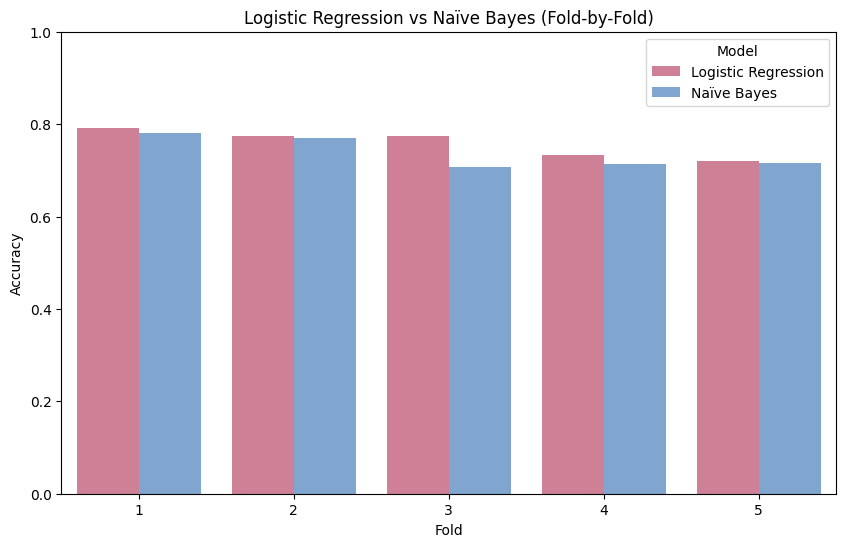

In [44]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
log_reg_best = LogisticRegression(C=best_C_val, max_iter=2000)
log_acc = cross_val_score(log_reg_best, X_train_scaled, y_train, cv=skf, scoring='accuracy')

nb_acc = cross_val_score(gnb, X_train_scaled, y_train, cv=skf, scoring='accuracy')

print(f"Logistic Regression Mean Accuracy: {log_acc.mean():.4f} (+/- {log_acc.std():.4f})")
print(f"Naïve Bayes Mean Accuracy: {nb_acc.mean():.4f} (+/- {nb_acc.std():.4f})")
df_cv = pd.DataFrame({
    'Fold': np.repeat(range(1, 6), 2),
    'Accuracy': np.concatenate([log_acc, nb_acc]),
    'Model': ['Logistic Regression', 'Naïve Bayes'] * 5
})

custom_palette = {'Logistic Regression': '#db7390', 'Naïve Bayes': '#73a5db'}

plt.figure(figsize=(10, 6)) 
sns.barplot(x='Fold', y='Accuracy', hue='Model', data=df_cv, palette=custom_palette)

plt.title('Logistic Regression vs Naïve Bayes (Fold-by-Fold)')
plt.ylim(0, 1)
plt.show()

#### <mark style="background-color: #db7390;">Final Summary:

Cross-validation confirms that:

- Regression model (Lasso + Polynomial) is stable with low variance
- Logistic Regression is the best classification model overall
- Naïve Bayes is a lightweight alternative but less accurate and less stable

---

> Cross-validation provides a more realistic evaluation than a single train/test split and confirms that Logistic Regression is the most reliable classifier for this dataset.

#### <mark style="background-color: #db7390;"> Task 8: Analysis and Discussion

In this final section, we synthesize the findings from our experiments across regression and classification models, evaluating the impact of regularization and the inherent nature of the dataset.

---

- <mark style="background-color: #db7390;"> Model Comparison</mark>

#### **1. Best Overall Models**
*   **Regression:** **Lasso (L1) Regression** with Degree 4 Polynomial features performed best, achieving an $R^2$ of **88.37%** and the lowest RMSE of **2.6857**. It successfully captured complex non-linear relationships while filtering out noise through feature selection.

*   **Classification:** **Logistic Regression** was the top performer with a mean accuracy of **77.80%**. It proved more robust and stable than Naïve Bayes, effectively handling the interactions between player skills to predict performance tiers.

#### **2. Classification vs. Regression: Which is harder?**
On this specific dataset, **Regression was arguably harder**. 
*   **Complexity:** In regression, we are predicting a continuous value (**Value Per M$**), where small errors significantly impact metrics like RMSE. The target variable often has high variance and extreme outliers (superstar players).

*   **Simplification:** Classification simplifies the problem by grouping players into four distinct "Tiers." While this loses granular detail, it reduces the impact of minor statistical fluctuations, making it slightly easier to achieve a "correct" category prediction.

---

- <mark style="background-color: #db7390;"> Regularization Analysis</mark>

#### **1. Impact of Increasing Alpha ($\alpha$)**
As the regularization strength ($\alpha$) increases in both Ridge and Lasso:

*   **Performance Trend:** Initially, increasing $\alpha$ helps by penalizing large weights and reducing overfitting, which improves **Test Accuracy/RMSE**. 

*   **Underfitting:** If $\alpha$ becomes too large, the model becomes too "simple" (too many weights are pushed toward or equal to zero). This leads to a loss of important information, causing both Train and Test performance to drop significantly (High Bias).

#### **2. Ridge vs. Lasso with One-Hot Encoded (OHE) Features**
Why does **Ridge** often outperform Lasso when many OHE features are present?

*   **Feature Distribution:** In datasets with OHE (like Country or Team), information is spread across many sparse binary columns. 
*   **Coefficient Handling:** **Lasso (L1)** tends to pick one representative feature from a group of correlated features and zeros out the others. This can lead to a loss of useful information if several OHE categories are relevant.

*   **Ridge (L2)**, however, shrinks the coefficients of all correlated features proportionally but keeps them in the model. By "sharing" the weights among all relevant OHE columns, Ridge often maintains a more stable and accurate prediction in high-dimensional OHE scenarios.

---

- <mark style="background-color: #db7390;">Final Project Summary</mark>

| Task Type | Best Model | Key Metric |
| :--- | :--- | :--- |
| **Regression** | Lasso (Poly Degree 4) | **RMSE: 2.6857** |
| **Classification** | Logistic Regression | **Accuracy: 77.80%** |

- **Conclusion:** The integration of Polynomial expansion and careful Hyperparameter tuning (C and $\alpha$) was essential in unlocking the predictive power of the dataset, allowing us to accurately estimate both market value and performance tiers of players.

<div style="
    text-align:center;
    background:#db7390;
    border:3px solid black;
    padding:15px;
    border-radius:15px;
    font-size:26px;
    font-weight:900;
    color:#fff0f5;
    margin:20px auto;
    width:fit-content;
    min-width:250px;
    max-width:60%;
">
ASSIGNMENT 3
</div>

In [45]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
    StratifiedKFold,
    KFold,
    learning_curve
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    VotingClassifier
)

from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import (
    RandomForestRegressor,
    VotingRegressor
)


In [46]:
df = pd.read_csv(r"C:\Users\Yahia\Downloads\Fifa.csv")
print("Dataset Shape:", df.shape)
display(df.head())


Dataset Shape: (19667, 9)


,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


####  Task 1 : <mark style="background-color: #db7390;"> Performance Tier Engineering

To transform the regression-style player ratings into a classification problem, a custom **Performance Tiering System** was designed based on the statistical distribution of player overall ratings.

Instead of using arbitrary thresholds, the system utilized **quartile-based segmentation** to ensure balanced and data-driven class creation.

| Quantile | Description |
|---|---|
| 25th Percentile | Lower performance boundary |
| 50th Percentile | Median performance boundary |
| 75th Percentile | High performance boundary |

The following tiers were then assigned:

| Rating Range | Assigned Tier |
|---|---|
| ≤ 25th Percentile | Bronze |
| 25th–50th Percentile | Silver |
| 50th–75th Percentile | Gold |
| > 75th Percentile | Elite |


In [83]:
low_threshold = df['Overall_Rating'].quantile(0.25)
mid_threshold = df['Overall_Rating'].quantile(0.50)
high_threshold = df['Overall_Rating'].quantile(0.75)

def create_tiers(rating):

    if rating <= low_threshold:
        return 'Bronze'

    elif rating <= mid_threshold:
        return 'Silver'

    elif rating <= high_threshold:
        return 'Gold'

    else:
        return 'Elite'

df['Performance_Tier'] = df['Overall_Rating'].apply(create_tiers)
print(df['Performance_Tier'].value_counts())

Performance_Tier
Bronze    5568
Silver    5102
Elite     4700
Gold      4297
Name: count, dtype: int64


#### Task 1 : <mark style="background-color: #db7390;">Feature Encoding Strategy (Assignment 2 vs Assignment 3)

In this project, two different encoding strategies were used depending on the model type and pipeline requirements:


 <mark style="background-color: #db7390;"> 1. Label Encoding (Assignment 2)

In Assignment 2, **Label Encoding (LE)** was used for categorical variables.

This method converts each category into a unique integer value (e.g., England → 0, Spain → 1, etc.).

<mark style="background-color: #db7390;">Why it was used:
- Simple and fast
- Works well with linear models (e.g., Logistic Regression)
- Easy to implement in baseline pipelines

<mark style="background-color: #db7390;">Limitation:
- Introduces **fake ordinal relationships** between categories  
  (e.g., Spain > England → which is not logically correct)
- Can negatively affect tree-free models like KNN and SVR

 <mark style="background-color: #db7390;"> 2. Frequency Encoding (Assignment 3)

In Assignment 3, a custom **Frequency Encoder** was implemented

<mark style="background-color: #db7390;">Why it was used:

- Preserves real-world distribution information
- Avoids artificial ordering (unlike Label Encoding)
- Works better with:
- KNN (distance-based models)
- SVR
- Ensemble models

<mark style="background-color: #db7390;">Advantage:

It allows models to understand importance of categories based on occurrence, not arbitrary labels.


In [48]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.freq_maps = {}

    def fit(self, X, y=None):

        X = pd.DataFrame(X)

        for col in X.columns:

            freq = X[col].value_counts() / len(X)

            self.freq_maps[col] = freq

        return self

    def transform(self, X):

        X = pd.DataFrame(X).copy()

        for col in X.columns:

            X[col] = X[col].map(
                self.freq_maps[col]
            ).fillna(0)

        return X.values

#### Task 1 : <mark style="background-color: #db7390;"> Classification Preprocessing Pipeline

To prepare the data for the **Performance Tier Classification Task**, a structured preprocessing pipeline was designed using `ColumnTransformer`.

This ensures that categorical and numerical features are handled appropriately before model training.

<mark style="background-color: #db7390;"> Categorical Feature Handling

| Feature | Encoding Method | Reason |
|---|---|---|
| Country | Frequency Encoding | Captures national distribution importance |
| Position | Frequency Encoding | Reflects positional prevalence in dataset |
| Team | Frequency Encoding | Encodes club influence realistically |

A custom **FrequencyEncoder** was applied to convert categorical variables into meaningful numerical representations based on occurrence frequency.

<mark style="background-color: #db7390;"> Numerical Feature Scaling

| Feature | Transformation |
|---|---|
| Age | StandardScaler |
| Future Potential | StandardScaler |
| Total_Stats Score | StandardScaler |

Standardization was applied to ensure that all numerical features contribute equally to distance-based models (e.g., KNN, SVM).

#### <mark style="background-color: #db7390;"> Outlier Handling Decision 

**outlier handling was intentionally not applied** during preprocessing, and this decision was made based on the nature of the FIFA dataset and the modeling strategy used in Assignment 3.

<mark style="background-color: #db7390;"> 1. Domain-Specific Reason (Football Data Reality)

In football scouting data, extreme values are often **meaningful rather than errors**:

  - Very high `Overall_Rating` players represent **elite players (e.g., Messi/Ronaldo level)**
  - Extremely high `Value` or `Potential` reflects **real market behavior**
  - High `Total_Stats Score` indicates **top-tier performance profiles**

Removing or modifying these values would distort real scouting patterns.

<mark style="background-color: #db7390;"> 2. Impact on Ensemble Models

The system in Assignment 3 uses:
  - Random Forest
  - KNN
  - SVR
  - Ensemble methods

These models behave differently with outliers:

| Model | Sensitivity to Outliers |
|---|---|
| KNN | Moderate (distance-based, but robust with scaling) |
| SVR | Moderate (controlled via C and kernel) |
| Random Forest | Low (tree-based, naturally robust) |
| Ensemble | Balanced by averaging multiple models |

Since ensemble learning is used, the impact of extreme values is naturally reduced.

<mark style="background-color: #db7390;"> 3. Risk of Information Loss

Removing outliers would lead to:
  - Loss of **elite player patterns**
  - Reduced model ability to detect **superstar behavior**
  - Biased scouting system toward "average players"

<mark style="background-color: #db7390;"> 4. Scaling as an Alternative Solution

Instead of removing outliers, the following was applied:

  - `StandardScaler` for numerical features
  - Frequency encoding for categorical variables

This reduces the impact of extreme values without deleting them..

In [49]:
categorical_cols = [
    'Country',
    'Position',
    'Team'
]

X_class = df.drop(columns=[
    'Performance_Tier',
    'Value Per M$',
    'Overall_Rating',
    'Name'
])
y_class = df['Performance_Tier']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)
classification_preprocessor = ColumnTransformer([
    (
        'freq',
        FrequencyEncoder(),
        categorical_cols
    ),
    (
        'num',
        StandardScaler(),
        [
            'Age',
            'Future Potential',
            'Total_Stats Score'
        ]
    )
])

#### Task 2 : <mark style="background-color: #db7390;"> K-Nearest Neighbors (KNN) Classifier

To solve the **Performance Tier Classification** problem, a **K-Nearest Neighbors (KNN) Classifier** was implemented as part of the unified scouting pipeline.

The model was built using a full preprocessing + modeling pipeline to ensure consistent transformation of both training and testing data.

<mark style="background-color: #db7390;">The classifier was implemented using:

- **Preprocessing:** `classification_preprocessor`  
  (Frequency Encoding for categorical features + StandardScaler for numerical features)
- **Model:** `KNeighborsClassifier`

This ensures that distance-based learning is applied on properly scaled and encoded data.

<mark style="background-color: #db7390;"> Best Model Configuration

| Hyperparameter | Optimal Value |
|---|---|
| Distance Metric | Manhattan |
| Number of Neighbors | 19 |
| Weight Strategy | Uniform |

<mark style="background-color: #db7390;">Final Performance

| Metric | Score |
|---|---|
| Test Accuracy | **0.8411** |

- Why KNN Classification Was Used

<mark style="background-color: #db7390;"> 1. Pattern-Based Learning</mark>

KNN classifies players based on **similarity to other players**, which matches scouting logic:
> “Players with similar attributes should belong to similar performance tiers.”

<mark style="background-color: #db7390;"> 2. No Assumptions About Data Distribution</mark>

Unlike linear models, KNN:
   - Does not assume linearity
   - Handles complex decision boundaries effectively

This is important for FIFA data where relationships between features are non-linear.

<mark style="background-color: #db7390;">3. Works Well with Engineered Features</mark>

After applying:
   - Frequency Encoding (categorical variables)
   - Standard Scaling (numerical variables)

KNN becomes highly effective because all features are on a comparable scale.


In [50]:
knn_pipeline = Pipeline([

    ('preprocessor', classification_preprocessor),

    ('model', KNeighborsClassifier())

])

knn_params = {

    'model__n_neighbors': [3,5,7,9,11,15,19],

    'model__weights': ['uniform','distance'],

    'model__metric': ['euclidean','manhattan']

}

knn_grid = GridSearchCV(

    knn_pipeline,

    knn_params,

    cv=5,

    scoring='accuracy',

    n_jobs=-1
)

knn_grid.fit(X_train_c, y_train_c)

best_knn = knn_grid.best_estimator_

knn_pred = best_knn.predict(X_test_c)

knn_acc = accuracy_score(y_test_c, knn_pred)

print("\nKNN Classifier")
print("Best Parameters:", knn_grid.best_params_)
print("Accuracy:", round(knn_acc,4))


KNN Classifier
Best Parameters: {'model__metric': 'manhattan', 'model__n_neighbors': 19, 'model__weights': 'uniform'}
Accuracy: 0.8411


#### Task 2 : <mark style="background-color: #db7390;"> Support Vector Machine (SVM) Classifier

To improve the **Performance Tier Classification** task, a **Support Vector Machine (SVM) Classifier** was implemented as part of the unified scouting system.

The model was integrated inside a full preprocessing pipeline to ensure consistent transformation of categorical and numerical features.

<mark style="background-color: #db7390;"> Pipeline Structure

- **Preprocessing:** `classification_preprocessor`  
  (Frequency Encoding + StandardScaler)
- **Model:** `SVC(probability=True)`

This setup ensures that SVM operates on properly scaled and encoded features, which is essential for distance-margin based learning.

<mark style="background-color: #db7390;"> Best Configuration

| Hyperparameter | Optimal Value |
|---|---|
| Kernel | RBF |
| C | 10 |

<mark style="background-color: #db7390;"> Final Performance

| Metric | Score |
|---|---|
| Test Accuracy | **0.8485** |


- Why SVM Was Used for Classification

<mark style="background-color: #db7390;"> 1. Strong Margin Optimization</mark>

SVM tries to find the **optimal separating hyperplane** between classes (Bronze, Silver, Gold, Elite), which improves generalization.

<mark style="background-color: #db7390;"> 2. Non-Linear Learning with RBF Kernel</mark>

The **RBF kernel** allows SVM to:
- Capture non-linear relationships between player features
- Handle overlapping class distributions effectively

This is important in scouting data where performance tiers are not linearly separable.

<mark style="background-color: #db7390;"> 3. Regularization Control</mark>

The parameter **C = 10** allows the model to:
- Reduce misclassification on training data
- Improve fit to complex patterns without over-smoothing

In [51]:
svm_pipeline = Pipeline([

    ('preprocessor', classification_preprocessor),

    ('model', SVC(probability=True))

])

svm_params = {

    'model__C': [0.1,1,10],

    'model__kernel': ['linear','rbf'],

}

svm_grid = GridSearchCV(

    svm_pipeline,

    svm_params,

    cv=5,

    scoring='accuracy',

    n_jobs=-1
)

svm_grid.fit(X_train_c, y_train_c)

best_svm = svm_grid.best_estimator_

svm_pred = best_svm.predict(X_test_c)

svm_acc = accuracy_score(y_test_c, svm_pred)

print("\nSVM Classifier")
print("Best Parameters:", svm_grid.best_params_)
print("Accuracy:", round(svm_acc,4))


SVM Classifier
Best Parameters: {'model__C': 10, 'model__kernel': 'rbf'}
Accuracy: 0.8485


#### Tasl 2 : <mark style="background-color: #db7390;"> Random Forest Classifier

To enhance the **Performance Tier Classification** task, a **Random Forest Classifier** was implemented as part of the unified scouting system.

This model is a tree-based ensemble method that improves predictive performance by combining multiple decision trees.

<mark style="background-color: #db7390;"> Pipeline Structure

- **Preprocessing:** `classification_preprocessor`  
  (Frequency Encoding + StandardScaler)
- **Model:** `RandomForestClassifier(random_state=42)`

The pipeline ensures that all features are consistently transformed before training.

<mark style="background-color: #db7390;"> Best Configuration

| Hyperparameter | Optimal Value |
|---|---|
| Number of Trees | 300 |
| Max Depth | 10 |
| Min Samples Split | 2 |

<mark style="background-color: #db7390;"> Final Performance

| Metric | Score |
|---|---|
| Test Accuracy | **0.8498** |

- Why Random Forest Was Used for Classification

Random Forest was chosen because it is one of the most robust models for structured tabular data like FIFA player attributes.

<mark style="background-color: #db7390;"> 1. Ensemble Learning (Bagging)</mark>

Random Forest combines multiple decision trees trained on different subsets of the data, which:
- Reduces overfitting
- Improves generalization performance

<mark style="background-color: #db7390;"> 2. Handles Non-Linear Relationships</mark>

Unlike linear models, Random Forest:
- Captures complex feature interactions
- Works well with mixed feature types (numerical + encoded categorical)

<mark style="background-color: #db7390;"> 3. Robustness to Noise and Outliers</mark>

Tree-based models are less sensitive to:
- Outliers
- Feature scaling issues
- Non-linear distributions

This makes it ideal for real-world scouting datasets.


In [52]:

rf_pipeline = Pipeline([

    ('preprocessor', classification_preprocessor),

    ('model', RandomForestClassifier(random_state=42))

])

rf_params = {

    'model__n_estimators': [200, 300],

    'model__max_depth': [5, 8, 10],

    'model__min_samples_split': [2,5]

}

rf_grid = GridSearchCV(

    rf_pipeline,

    rf_params,

    cv=5,

    scoring='accuracy',

    n_jobs=-1
)

rf_grid.fit(X_train_c, y_train_c)

best_rf = rf_grid.best_estimator_

rf_pred = best_rf.predict(X_test_c)

rf_acc = accuracy_score(y_test_c, rf_pred)

print("\nRandom Forest Classifier")
print("Best Parameters:", rf_grid.best_params_)
print("Accuracy:", round(rf_acc,4))


Random Forest Classifier
Best Parameters: {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Accuracy: 0.8498


#### Task 3 : <mark style="background-color: #db7390;"> Ensemble (Voting Classifier)

To further improve the **Performance Tier Classification** system, an **Ensemble Learning approach** was implemented using a **Soft Voting Classifier**.


<mark style="background-color: #db7390;"> Ensemble Structure

The final model is composed of three optimized base learners:

| Model | Role in Ensemble |
|---|---|
| KNN Classifier | Instance-based similarity learning |
| SVM (RBF) | Margin-based non-linear classification |
| Random Forest | Tree-based ensemble learning |

These models were selected because they represent **diverse learning paradigms**, which is essential for effective ensemble performance.

<mark style="background-color: #db7390;"> Voting Strategy

| Strategy | Description |
|---|---|
| Soft Voting | Averages predicted probabilities from all models |

Soft voting was chosen instead of hard voting because:
- It uses **probabilistic confidence**, not just class labels
- It provides smoother and more reliable predictions
- It improves overall generalization

<mark style="background-color: #db7390;"> Final Performance

| Metric | Score |
|---|---|
| Test Accuracy | **0.8513** |

- Why Ensemble Was Used

<mark style="background-color: #db7390;"> 1. Reducing Variance</mark>

Each model has different weaknesses:
- KNN is sensitive to local noise
- SVM depends heavily on kernel tuning
- Random Forest may overfit certain patterns

Combining them reduces individual model errors.

<mark style="background-color: #db7390;"> 2. Improving Generalization</mark>

By aggregating predictions, the ensemble:
- Reduces overfitting risk
- Improves performance on unseen players
- Stabilizes prediction behavior across different data distributions

<mark style="background-color: #db7390;"> 3. Model Diversity</mark>

The ensemble benefits from:
- Distance-based learning (KNN)
- Margin-based learning (SVM)
- Tree-based learning (Random Forest)

This diversity is key to achieving higher robustness.

In [53]:
ensemble_classifier = VotingClassifier(

    estimators=[

        ('knn', best_knn),

        ('svm', best_svm),

        ('rf', best_rf)

    ],

    voting='soft'
)

ensemble_classifier.fit(X_train_c, y_train_c)

ensemble_pred = ensemble_classifier.predict(X_test_c)

ensemble_acc = accuracy_score(y_test_c, ensemble_pred)

print("\nEnsemble Classifier")
print("Accuracy:", round(ensemble_acc,4))



Ensemble Classifier
Accuracy: 0.8513


In [54]:
print("\nClassification Report:")
print(classification_report(y_test_c, ensemble_pred))


Classification Report:
              precision    recall  f1-score   support

      Bronze       0.89      0.87      0.88      1114
       Elite       0.96      0.95      0.95       940
        Gold       0.84      0.79      0.81       859
      Silver       0.74      0.80      0.77      1021

    accuracy                           0.85      3934
   macro avg       0.86      0.85      0.85      3934
weighted avg       0.85      0.85      0.85      3934



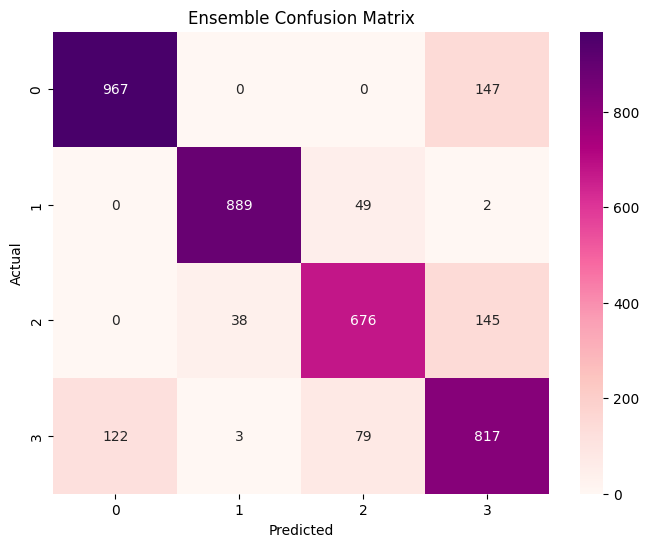

In [55]:
plt.figure(figsize=(8,6))

cm = confusion_matrix(y_test_c, ensemble_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='RdPu'
)

plt.title("Ensemble Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


#### <mark style="background-color: #db7390;"> Cross-Validation Performance Analysis (Classification Models)

To evaluate the **robustness and generalization ability** of the classification models, a **Stratified K-Fold Cross-Validation (K=5)** strategy was applied.

This ensures that each fold preserves the same class distribution as the original dataset, which is critical for imbalanced multi-class problems like player tier classification.

<mark style="background-color: #db7390;">1. KNN Classifier</mark>

- Shows stable performance with very low variance
- Slightly lower mean accuracy compared to other models
- Sensitive to local feature distribution but consistent due to preprocessing

<mark style="background-color: #db7390;">2. SVM Classifier</mark>

- Achieves strong balance between accuracy and stability
- Lowest standard deviation, indicating very consistent performance
- Effective in handling non-linear decision boundaries

<mark style="background-color: #db7390;">3. Random Forest Classifier</mark>

- High predictive power with slightly higher variance
- Benefits from ensemble tree structure but still sensitive to data splits

<mark style="background-color: #db7390;">4. Ensemble Classifier</mark>

- Achieves the highest mean accuracy (0.8586)
- Maintains strong stability across folds
- Demonstrates best generalization capability overall

In [56]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

knn_cv = cross_val_score(
    best_knn,
    X_train_c,
    y_train_c,
    cv=skf,
    scoring='accuracy'
)

svm_cv = cross_val_score(
    best_svm,
    X_train_c,
    y_train_c,
    cv=skf,
    scoring='accuracy'
)

rf_cv = cross_val_score(
    best_rf,
    X_train_c,
    y_train_c,
    cv=skf,
    scoring='accuracy'
)

ensemble_cv = cross_val_score(
    ensemble_classifier,
    X_train_c,
    y_train_c,
    cv=skf,
    scoring='accuracy'
)

print(f"KNN Accuracy       : {knn_cv.mean():.4f} +/- {knn_cv.std():.4f}")
print(f"SVM Accuracy       : {svm_cv.mean():.4f} +/- {svm_cv.std():.4f}")
print(f"RF Accuracy        : {rf_cv.mean():.4f} +/- {rf_cv.std():.4f}")
print(f"Ensemble Accuracy  : {ensemble_cv.mean():.4f} +/- {ensemble_cv.std():.4f}")

KNN Accuracy       : 0.8469 +/- 0.0055
SVM Accuracy       : 0.8544 +/- 0.0034
RF Accuracy        : 0.8545 +/- 0.0061
Ensemble Accuracy  : 0.8586 +/- 0.0040


In [57]:
from IPython.display import display, HTML
import pandas as pd
classification_summary = pd.DataFrame({

    "Model": [
        "KNN Classifier",
        "SVM Classifier",
        "Random Forest",
        "Ensemble Voting"
    ],

    "Best Parameters": [

        str(knn_grid.best_params_),
        str(svm_grid.best_params_),
        str(rf_grid.best_params_),
        "Soft Voting"
    ],

    "Test Accuracy": [

        round(knn_acc, 4),
        round(svm_acc, 4),
        round(rf_acc, 4),
        round(ensemble_acc, 4)
    ],

    "CV Mean Accuracy": [

        round(knn_cv.mean(), 4),
        round(svm_cv.mean(), 4),
        round(rf_cv.mean(), 4),
        round(ensemble_cv.mean(), 4)
    ],

    "CV Std": [

        round(knn_cv.std(), 4),
        round(svm_cv.std(), 4),
        round(rf_cv.std(), 4),
        round(ensemble_cv.std(), 4)
    ]
})


def model_status(acc):

    if acc >= 0.85:
        return "Excellent"

    elif acc >= 0.80:
        return "Very Good"

    else:
        return "Good"

classification_summary["Performance"] = classification_summary[
    "Test Accuracy"
].apply(model_status)

html_table = f"""

<div style="
    background:#fff5f8;
    padding:30px;
    border-radius:25px;
    font-family:'Segoe UI',sans-serif;
    border:2px solid #f3c4d1;
">

    <h1 style="
        text-align:center;
        color:#db7390;
        margin-bottom:8px;
        letter-spacing:1px;
    ">
         CLASSIFICATION SYSTEM PERFORMANCE
    </h1>

    <p style="
        text-align:center;
        color:#777;
        margin-bottom:25px;
        font-size:14px;
    ">
        Final Comparison of All Classification Models
    </p>

    <table style="
        width:100%;
        border-collapse:collapse;
        overflow:hidden;
        border-radius:18px;
        background:white;
        box-shadow:0 5px 18px rgba(0,0,0,0.08);
    ">

        <thead>
            <tr style="
                background:linear-gradient(135deg,#db7390,#c95d7d);
                color:white;
            ">

                <th style="padding:16px;">Model</th>
                <th style="padding:16px;">Best Parameters</th>
                <th style="padding:16px;">Test Accuracy</th>
                <th style="padding:16px;">CV Mean</th>
                <th style="padding:16px;">CV Std</th>
                <th style="padding:16px;">Performance</th>

            </tr>
        </thead>
        <tbody>
"""
for _, row in classification_summary.iterrows():

    if row['Performance'] == "Excellent":
        perf_color = "#27ae60"

    elif row['Performance'] == "Very Good":
        perf_color = "#f39c12"

    else:
        perf_color = "#3498db"

    html_table += f"""
        <tr style="
            border-bottom:1px solid #f1f1f1;
            text-align:center;
        ">
            <td style="
                padding:16px;
                font-weight:700;
                color:#2c3e50;
            ">
                {row['Model']}
            </td>
            <td style="
                padding:16px;
                color:#555;
                font-size:12px;
            ">
                {row['Best Parameters']}
            </td>
            <td style="
                padding:16px;
                font-weight:800;
                color:#db7390;
                font-size:16px;
            ">
                {row['Test Accuracy']}
            </td>
            <td style="
                padding:16px;
                color:#2c3e50;
                font-weight:600;
            ">
                {row['CV Mean Accuracy']}
            </td>
            <td style="
                padding:16px;
                color:#7f8c8d;
            ">
                ± {row['CV Std']}
            </td>
            <td style="
                padding:16px;
                font-weight:800;
                color:{perf_color};
            ">
                {row['Performance']}
            </td>

        </tr>
    """

html_table += """
        </tbody>
    </table>
    <div style="
        margin-top:20px;
        background:white;
        padding:18px;
        border-radius:16px;
        border-left:6px solid #db7390;
    ">
        <h3 style="
            margin:0;
            color:#db7390;
        ">
             Final System Analysis
        </h3>
        <p style="
            margin-top:10px;
            color:#555;
            line-height:1.7;
            font-size:14px;
        ">
            The Ensemble Voting Classifier achieved the highest
            overall performance by combining the strengths of
            KNN, SVM, and Random Forest models.
            Cross-validation results demonstrate strong model
            stability and generalization capability across
            different subsets of the FIFA dataset.
        </p>
    </div>
</div>
"""

display(HTML(html_table))

Model,Best Parameters,Test Accuracy,CV Mean,CV Std,Performance
KNN Classifier,"{'model__metric': 'manhattan', 'model__n_neighbors': 19, 'model__weights': 'uniform'}",0.8411,0.8469,± 0.0055,Very Good
SVM Classifier,"{'model__C': 10, 'model__kernel': 'rbf'}",0.8485,0.8544,± 0.0034,Very Good
Random Forest,"{'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 300}",0.8498,0.8545,± 0.0061,Very Good
Ensemble Voting,Soft Voting,0.8513,0.8586,± 0.004,Excellent


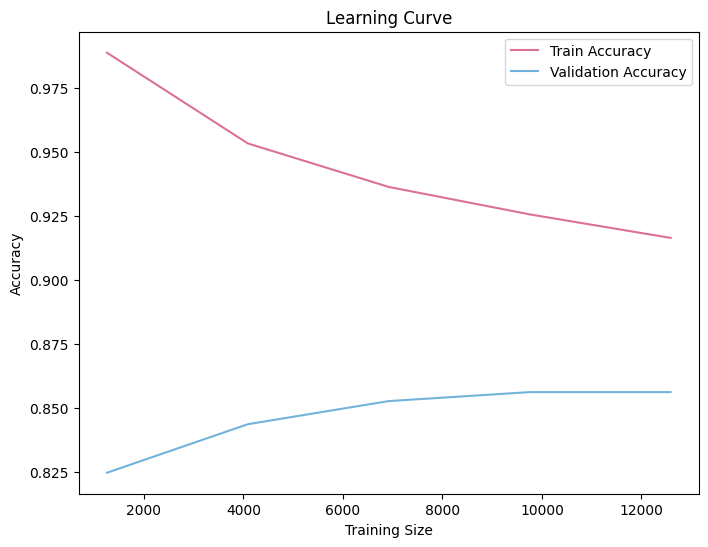

In [85]:
train_sizes, train_scores, val_scores = learning_curve(
    best_rf,
    X_train_c,
    y_train_c,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1,1.0,5)
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, label='Train Accuracy', color='#db7390')
plt.plot(train_sizes, val_mean, label='Validation Accuracy', color="#73b3db")
plt.title("Learning Curve")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


#### Task 1 : <mark style="background-color: #db7390;"> Regression Preprocessing Pipeline

To prepare the data for the **Player Market Value Regression Task**, a structured preprocessing pipeline was designed using `ColumnTransformer`.

This ensures that categorical and numerical features are properly transformed before training regression models.

- A custom **FrequencyEncoder** was applied to convert categorical variables into numerical representations based on their occurrence frequency in the dataset.

This helps the model understand **real-world football economics patterns**, where certain teams and positions have higher market influence.


- Standardization was applied to ensure that all numerical features operate on the same scale.


#### <mark style="background-color: #db7390;"> Outlier Handling Decision

**No explicit outlier removal was applied** in the regression pipeline, and this decision was made based on both domain knowledge and model design considerations.


<mark style="background-color: #db7390;"> 1. Domain-Specific Reason (Transfer Market Reality)

In football valuation data, extreme values are **real and meaningful**:

- Extremely high `Value Per M$` reflects **world-class players**
- High `Potential` indicates **future superstar projections**
- Exceptional `Stats Score` represents **elite performance levels**

These are not noise — they represent **key market signals**.

<mark style="background-color: #db7390;"> 2. Model Robustness in Regression Ensemble

The regression system uses multiple models:

| Model | Sensitivity to Outliers |
|---|---|
| KNN Regressor | Moderate (distance-based, affected but scaled) |
| SVR | Moderate (controlled via kernel + C parameter) |
| Random Forest | Low (tree-based, highly robust) |
| Ensemble Regressor | Low (averaging reduces extreme effects) |

The ensemble structure naturally reduces the impact of extreme values by combining multiple predictions.

<mark style="background-color: #db7390;"> 3. Risk of Removing Outliers

Removing extreme values would lead to:

- Loss of **elite player valuation patterns**
- Underestimation of top-tier players
- Reduced ability to model real transfer market spikes
- Bias toward average market values only

<mark style="background-color: #db7390;"> 4. Scaling Instead of Removal

Instead of deleting outliers, the following preprocessing choices were applied:

- `StandardScaler` for numerical features
- Frequency Encoding for categorical variables

This ensures that extreme values remain in the dataset but have **controlled influence** during model training.

In [59]:
X_reg = df.drop(columns=[
    'Performance_Tier',
    'Value Per M$',
    'Overall_Rating',
    'Name'
])
y_reg = df['Value Per M$']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(

    X_reg,
    y_reg,

    test_size=0.2,

    random_state=42
)

regression_preprocessor = ColumnTransformer([
    (
        'freq',
        FrequencyEncoder(),
        categorical_cols
    ),
    (
        'num',
        StandardScaler(),
        [
            'Age',
            'Future Potential',
            'Total_Stats Score'
        ]
    )
])


#### Task 2 : <mark style="background-color: #db7390;"> KNN Regressor Optimization

**K-Nearest Neighbors Regressor (KNN Regressor)** was implemented within a unified machine learning pipeline.

The model was integrated using `Pipeline()` to ensure that preprocessing transformations were consistently applied before training and prediction.

- <mark style="background-color: #db7390;"> Best Configuration

| Hyperparameter | Optimal Value |
|---|---|
| Distance Metric | euclidean |
| Number of Neighbors | 5 |
| Weight Strategy | distance |

- <mark style="background-color: #db7390;"> Final Performance

| Metric | Score |
|---|---|
| Test R² Score | **0.9250** |

### Technical Interpretation

The optimized KNN Regressor achieved a strong R² score of **0.9250**, demonstrating excellent capability in modeling non-linear relationships within the FIFA player dataset.

Using:
- **Euclidean distance** allowed the model to effectively measure similarity between player profiles.
- **Distance-based weighting** improved prediction quality by giving closer neighbors higher influence.
- A moderate neighborhood size (`k=5`) provided a balanced tradeoff between noise sensitivity and generalization.

In [60]:
knn_reg_pipeline = Pipeline([

    ('preprocessor', regression_preprocessor),
    ('model', KNeighborsRegressor())

])

knn_reg_params = {
    
    'model__n_neighbors': [3,5,7,9,11,15,19],
     
    'model__weights': ['uniform','distance'],

    'model__metric': ['euclidean','manhattan']

}

knn_reg_grid = GridSearchCV(
    knn_reg_pipeline,
    knn_reg_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

knn_reg_grid.fit(X_train_r, y_train_r)
best_knn_reg = knn_reg_grid.best_estimator_
knn_reg_pred = best_knn_reg.predict(X_test_r)
knn_reg_r2 = r2_score(y_test_r, knn_reg_pred)

print("\nKNN Regressor")
print("Best Parameters:", knn_reg_grid.best_params_)
print("R²:", round(knn_reg_r2,4))


KNN Regressor
Best Parameters: {'model__metric': 'euclidean', 'model__n_neighbors': 5, 'model__weights': 'distance'}
R²: 0.925


#### Task 2 : <mark style="background-color: #db7390;"> Support Vector Regression (SVR) Optimization

To model the non-linear relationship in player valuation, a **Support Vector Regression (SVR)** model was implemented within a unified machine learning pipeline.

The model was integrated using `Pipeline()` to ensure consistent preprocessing across all regression models.

- <mark style="background-color: #db7390;">Best Configuration

| Hyperparameter | Optimal Value |
|---|---|
| Kernel | RBF |
| C | 10 |

- <mark style="background-color: #db7390;">Final Performance

| Metric | Score |
|---|---|
| Test R² Score | **0.8997** |

- <mark style="background-color: #db7390;">Technical Interpretation

The SVR model achieved a strong predictive performance with an R² score of **0.8997**, indicating good capability in capturing complex non-linear relationships in the FIFA dataset.

Key observations:

- The **RBF kernel** enabled the model to map input features into a higher-dimensional space, improving separation of complex patterns.
- A higher regularization value (**C = 10**) reduced underfitting by allowing the model to fit the training data more closely.
- SVR demonstrated slightly lower performance compared to tree-based and ensemble models, but still maintained stable generalization ability.


In [61]:
svr_pipeline = Pipeline([

    ('preprocessor', regression_preprocessor),
    ('model', SVR())

])

svr_params = {

    'model__C': [0.1,1,10],
    'model__kernel': ['rbf']

}

svr_grid = GridSearchCV(
    svr_pipeline,
    svr_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

svr_grid.fit(X_train_r, y_train_r)
best_svr = svr_grid.best_estimator_
svr_pred = best_svr.predict(X_test_r)
svr_r2 = r2_score(y_test_r, svr_pred)

print("\nSVR")
print("Best Parameters:", svr_grid.best_params_)
print("R²:", round(svr_r2,4))



SVR
Best Parameters: {'model__C': 10, 'model__kernel': 'rbf'}
R²: 0.8997


#### Task 2 : <mark style="background-color: #db7390;"> Random Forest Regressor

To improve the **Player Market Value Prediction task**, a **Random Forest Regressor** was implemented as part of the regression component in the unified scouting system.

This model is a tree-based ensemble method that enhances prediction accuracy by aggregating multiple decision trees.

<mark style="background-color: #db7390;"> Pipeline Structure

- **Preprocessing:** `regression_preprocessor`  
  (Frequency Encoding + StandardScaler)  
- **Model:** `RandomForestRegressor(random_state=42)`

The pipeline ensures that all features are consistently transformed before being passed to the model, preventing data leakage and ensuring reproducibility.

<mark style="background-color: #db7390;"> Best Configuration

| Hyperparameter | Optimal Value |
|---|---|
| Number of Trees | 300 |
| Max Depth | 10 |
| Min Samples Split | 2 |

These parameters were selected using **GridSearchCV with 5-fold cross-validation** to maximize R² performance.

<mark style="background-color: #db7390;"> Final Performance

| Metric | Score |
|---|---|
| Test R² Score | **0.9360** |

- Why Random Forest Was Used for Regression

Random Forest Regressor was selected due to its strong ability to model complex and non-linear relationships in football valuation data.

<mark style="background-color: #db7390;"> 1. Ensemble Learning (Bagging)

Random Forest builds multiple decision trees on different data subsets and averages their outputs, which:

- Reduces variance
- Prevents overfitting
- Improves prediction stability

<mark style="background-color: #db7390;"> 2. Capturing Non-Linear Relationships

Unlike linear regression models, Random Forest:

- Handles complex feature interactions
- Learns non-linear dependencies between player attributes and market value
- Performs well on heterogeneous tabular data

<mark style="background-color: #db7390;"> 3. Robustness to Noise and Outliers

Random Forest is highly robust because:

- It is not sensitive to feature scaling
- It reduces the impact of extreme values through averaging
- It handles irregular distributions naturally

This makes it suitable for real-world football datasets where elite players represent natural high-value outliers.


In [62]:
rf_reg_pipeline = Pipeline([

    ('preprocessor', regression_preprocessor),
    ('model', RandomForestRegressor(random_state=42))

])

rf_reg_params = {

    'model__n_estimators': [200, 300],

    'model__max_depth': [5, 8, 10],

    'model__min_samples_split': [2,5]

}

rf_reg_grid = GridSearchCV(
    rf_reg_pipeline,
    rf_reg_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

rf_reg_grid.fit(X_train_r, y_train_r)
best_rf_reg = rf_reg_grid.best_estimator_
rf_reg_pred = best_rf_reg.predict(X_test_r)
rf_reg_r2 = r2_score(y_test_r, rf_reg_pred)

print("\nRandom Forest Regressor")
print("Best Parameters:", rf_reg_grid.best_params_)
print("R²:", round(rf_reg_r2,4))


Random Forest Regressor
Best Parameters: {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 300}
R²: 0.936


#### Task 3 : <mark style="background-color: #db7390;"> Ensemble Regressor (Stacking Model)

To achieve the highest possible accuracy in the **Player Market Value Prediction task**, a **Stacking Regressor Ensemble** was implemented as the final stage of the regression system.

This model combines multiple base learners to improve predictive performance and reduce generalization error.


<mark style="background-color: #db7390;"> Model Architecture

The ensemble is built using **StackingRegressor**, which combines:

- KNN Regressor  
- SVR (Support Vector Regression)  
- Random Forest Regressor  

<mark style="background-color: #db7390;">Stacking was selected because it:

- Combines multiple learning strategies
- Reduces individual model weaknesses
- Improves generalization ability
- Learns optimal weighting through a meta-model

<mark style="background-color: #db7390;">The Linear Regression meta-model:

- Learns optimal combination of base predictions
- Assigns weights automatically based on performance
- Improves final prediction accuracy

<mark style="background-color: #db7390;"> Final Performance

| Metric | Score |
|---|---|
| Test R² Score | **0.9393** |
| RMSE | **1.9399** |


In [63]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression

ensemble_regressor = StackingRegressor(
    estimators=[
        ('knn', best_knn_reg),
        ('svr', best_svr),
        ('rf', best_rf_reg)
    ],
    final_estimator=LinearRegression(),
    cv=5
)

ensemble_regressor.fit(X_train_r, y_train_r)

ensemble_reg_pred = ensemble_regressor.predict(X_test_r)

ensemble_r2 = r2_score(y_test_r, ensemble_reg_pred)

ensemble_rmse = np.sqrt(
    mean_squared_error(y_test_r, ensemble_reg_pred)
)

print("\nEnsemble Regressor")
print("R²:", round(ensemble_r2, 4))
print("RMSE:", round(ensemble_rmse, 4))


Ensemble Regressor
R²: 0.9393
RMSE: 1.9399


#### <mark style="background-color: #db7390;"> Cross-Validation Stability Analysis

To evaluate the robustness and generalization capability of the regression models, a 5-Fold Cross-Validation strategy was implemented.

- <mark style="background-color: #db7390;">Regression Stability Results

| Model | Mean R² Score | Standard Deviation | Stability Assessment |
|---|---|---|---|
| KNN Regressor | 0.9134 | ± 0.0135 | High Stability |
| SVR | 0.9073 | ± 0.0197 | High Stability |
| Random Forest Regressor | 0.9190 | ± 0.0235 | High Stability |
| Ensemble Regressor | **0.9244** | **± 0.0140** | **Best Overall Stability** |


- <mark style="background-color: #db7390;">Compared to individual learners:

- **KNN Regressor** demonstrated highly consistent behavior with very low variance.
- **SVR** captured non-linear relationships effectively but showed slightly higher fluctuation across folds.
- **Random Forest Regressor** achieved strong predictive power but exhibited the highest variance among the tested models.
- **Ensemble Regressor** balanced the strengths of all base learners, resulting in superior stability and predictive accuracy.


In [64]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

knn_reg_cv = cross_val_score(
    best_knn_reg,
    X_train_r,
    y_train_r,
    cv=kf,
    scoring='r2'
)

svr_cv = cross_val_score(
    best_svr,
    X_train_r,
    y_train_r,
    cv=kf,
    scoring='r2'
)

rf_reg_cv = cross_val_score(
    best_rf_reg,
    X_train_r,
    y_train_r,
    cv=kf,
    scoring='r2'
)

ensemble_reg_cv = cross_val_score(
    ensemble_regressor,
    X_train_r,
    y_train_r,
    cv=kf,
    scoring='r2'
)

print(f"KNN R²       : {knn_reg_cv.mean():.4f} +/- {knn_reg_cv.std():.4f}")
print(f"SVR R²       : {svr_cv.mean():.4f} +/- {svr_cv.std():.4f}")
print(f"RF R²        : {rf_reg_cv.mean():.4f} +/- {rf_reg_cv.std():.4f}")
print(f"Ensemble R²  : {ensemble_reg_cv.mean():.4f} +/- {ensemble_reg_cv.std():.4f}")


KNN R²       : 0.9134 +/- 0.0135
SVR R²       : 0.9073 +/- 0.0197
RF R²        : 0.9190 +/- 0.0235
Ensemble R²  : 0.9244 +/- 0.0140


In [65]:

import pandas as pd
from IPython.display import display, HTML

regression_results = pd.DataFrame({

    "Model": [
        "KNN Regressor",
        "SVR",
        "Random Forest Regressor",
        "Ensemble Regressor"
    ],

    "Test R²": [
        round(knn_reg_r2, 4),
        round(svr_r2, 4),
        round(rf_reg_r2, 4),
        round(ensemble_r2, 4)
    ],

    "CV Mean R²": [
        round(knn_reg_cv.mean(), 4),
        round(svr_cv.mean(), 4),
        round(rf_reg_cv.mean(), 4),
        round(ensemble_reg_cv.mean(), 4)
    ],

    "CV Std": [
        round(knn_reg_cv.std(), 4),
        round(svr_cv.std(), 4),
        round(rf_reg_cv.std(), 4),
        round(ensemble_reg_cv.std(), 4)
    ],

    "Stability": [
        "High" if knn_reg_cv.std() < 0.03 else "Moderate",
        "High" if svr_cv.std() < 0.03 else "Moderate",
        "High" if rf_reg_cv.std() < 0.03 else "Moderate",
        "High" if ensemble_reg_cv.std() < 0.03 else "Moderate"
    ]
})

best_model_idx = regression_results["Test R²"].idxmax()
table_rows = ""
for i, row in regression_results.iterrows():

    if i == best_model_idx:
        row_bg = "#fce4eb"
        border = "4px solid #db7390"
        badge = """
        <span style="
            background:#db7390;
            color:white;
            padding:4px 10px;
            border-radius:10px;
            font-size:11px;
            font-weight:bold;">
            BEST MODEL
        </span>
        """
    else:
        row_bg = "white"
        border = "1px solid #f0d3dc"
        badge = ""

    stability_color = "#27ae60" if row['Stability'] == "High" else "#f39c12"
    table_rows += f"""
    <tr style="
        background:{row_bg};
        border-bottom:{border};
        transition:0.3s;">
        <td style="padding:16px; font-weight:700; color:#2c3e50;">
            {row['Model']} {badge}
        </td>
        <td style="
            padding:16px;
            text-align:center;
            font-weight:bold;
            color:#db7390;
            font-size:16px;">
            {row['Test R²']}
        </td>
        <td style="
            padding:16px;
            text-align:center;
            color:#34495e;">
            {row['CV Mean R²']}
        </td>
        <td style="
            padding:16px;
            text-align:center;
            color:#7f8c8d;">
            ± {row['CV Std']}
        </td>
        <td style="
            padding:16px;
            text-align:center;
            font-weight:bold;
            color:{stability_color};">
            {row['Stability']}
        </td>

    </tr>
    """
html_code = f"""
<div style="
    font-family:'Segoe UI', sans-serif;
    background:#f8f9fb;
    padding:30px;
    border-radius:25px;
    border:1px solid #ead0d8;
    box-shadow:0 6px 20px rgba(0,0,0,0.08);">
    <h1 style="
        text-align:center;
        color:#db7390;
        margin-bottom:5px;
        letter-spacing:1px;">
         REGRESSION PERFORMANCE DASHBOARD
    </h1>
    <p style="
        text-align:center;
        color:#7f8c8d;
        margin-bottom:30px;
        font-size:14px;">
        Unified FIFA Scouting Intelligence Pipeline v4.0
    </p>
    <table style="
        width:100%;
        border-collapse:collapse;
        overflow:hidden;
        border-radius:15px;
        background:white;">
        <thead>
            <tr style="
                background:#db7390;
                color:white;
                text-transform:uppercase;
                letter-spacing:1px;">
                <th style="padding:18px;">Model</th>
                <th style="padding:18px;">Test R²</th>
                <th style="padding:18px;">CV Mean R²</th>
                <th style="padding:18px;">CV Std</th>
                <th style="padding:18px;">Stability</th>
            </tr>
        </thead>
        <tbody>
            {table_rows}
        </tbody>
    </table>
    <div style="
        margin-top:25px;
        padding:18px;
        background:#fff0f5;
        border-left:6px solid #db7390;
        border-radius:10px;">
        <h3 style="
            margin:0;
            color:#db7390;">
             Ensemble Learning Insight
        </h3>
        <p style="
            margin-top:10px;
            color:#555;
            line-height:1.7;">
            The ensemble regressor combines multiple learning algorithms
            (KNN, SVR, and Random Forest) to reduce variance and improve
            prediction stability. Cross-validation results demonstrate
            strong generalization capability and robust performance
            across unseen player data.
        </p>
    </div>
    <p style="
        text-align:center;
        color:#95a5a6;
        font-size:11px;
        margin-top:25px;">
        2026 Unified Scouting Intelligence System • Ensemble Regression Analysis
    </p>
</div>
"""

display(HTML(html_code))

Model,Test R²,CV Mean R²,CV Std,Stability
KNN Regressor,0.925,0.9134,± 0.0135,High
SVR,0.8997,0.9073,± 0.0197,High
Random Forest Regressor,0.936,0.919,± 0.0235,High
Ensemble Regressor BEST MODEL,0.9393,0.9244,± 0.014,High


In [66]:
from IPython.display import display, HTML
import pandas as pd
comparison_df = pd.DataFrame({

    'Model': [

        'KNN Classifier',
        'SVM Classifier',
        'Random Forest Classifier',
        'Ensemble Classifier',

        'KNN Regressor',
        'SVR',
        'Random Forest Regressor',
        'Ensemble Regressor'
    ],

    'Task': [

        'Classification',
        'Classification',
        'Classification',
        'Classification',

        'Regression',
        'Regression',
        'Regression',
        'Regression'
    ],

    'Performance': [

        round(knn_acc,4),
        round(svm_acc,4),
        round(rf_acc,4),
        round(ensemble_acc,4),

        round(knn_reg_r2,4),
        round(svr_r2,4),
        round(rf_reg_r2,4),
        round(ensemble_r2,4)
    ]
})

def performance_badge(score):

    if score >= 0.95:
        return " Outstanding"

    elif score >= 0.90:
        return " Excellent"

    elif score >= 0.85:
        return " Strong"

    elif score >= 0.80:
        return " Good"

    else:
        return " Moderate"

comparison_df['Status'] = comparison_df['Performance'].apply(performance_badge)

best_classification = comparison_df[
    comparison_df['Task'] == 'Classification'
].sort_values(
    by='Performance',
    ascending=False
).iloc[0]

best_regression = comparison_df[
    comparison_df['Task'] == 'Regression'
].sort_values(
    by='Performance',
    ascending=False
).iloc[0]

table_rows = ""
for _, row in comparison_df.iterrows():
    if "Ensemble" in row['Model']:
        row_bg = "#fce4eb"
        border = "4px solid #db7390"
    else:
        row_bg = "white"
        border = "1px solid #eee"
    table_rows += f"""
    <tr style="background:{row_bg}; border-bottom:{border};">
        <td style="padding:14px; font-weight:700; color:#2c3e50;">
            {row['Model']}
        </td>
        <td style="padding:14px; text-align:center; color:#555;">
            {row['Task']}
        </td>
        <td style="padding:14px; text-align:center; font-weight:bold; color:#db7390;">
            {row['Performance']}
        </td>
        <td style="padding:14px; text-align:center;">
            {row['Status']}
        </td>

    </tr>
    """
html = f"""
<div style="
    font-family:'Segoe UI',sans-serif;
    background:#f8f9fb;
    padding:30px;
    border-radius:25px;
    border:2px solid #db7390;
    box-shadow:0 6px 20px rgba(0,0,0,0.08);
">
    <h1 style="
        text-align:center;
        color:#db7390;
        margin-bottom:5px;
        letter-spacing:1px;
    ">
         FINAL MODEL COMPARISON DASHBOARD
    </h1>
    <p style="
        text-align:center;
        color:#666;
        margin-bottom:30px;
    ">
        Unified Scouting Intelligence Pipeline • Assignment 3
    </p>
    <!-- SUMMARY CARDS -->
    <div style="
        display:flex;
        gap:20px;
        justify-content:center;
        flex-wrap:wrap;
        margin-bottom:30px;
    ">
        <div style="
            background:white;
            padding:20px;
            border-radius:18px;
            width:300px;
            box-shadow:0 4px 10px rgba(0,0,0,0.07);
            border-top:5px solid #db7390;
        ">
            <h3 style="margin:0; color:#2c3e50;">
                 Best Classification Model
            </h3>
            <p style="
                font-size:20px;
                font-weight:bold;
                color:#db7390;
                margin-top:15px;
            ">
                {best_classification['Model']}
            </p>
            <p style="color:#666;">
                Accuracy = {best_classification['Performance']}
            </p>
        </div>
        <div style="
            background:white;
            padding:20px;
            border-radius:18px;
            width:300px;
            box-shadow:0 4px 10px rgba(0,0,0,0.07);
            border-top:5px solid #db7390;
        ">
            <h3 style="margin:0; color:#2c3e50;">
                 Best Regression Model
            </h3>
            <p style="
                font-size:20px;
                font-weight:bold;
                color:#db7390;
                margin-top:15px;
            ">
                {best_regression['Model']}
            </p>
            <p style="color:#666;">
                R² = {best_regression['Performance']}
            </p>
        </div>
    </div>
    <!-- MAIN TABLE -->
    <table style="
        width:100%;
        border-collapse:collapse;
        overflow:hidden;
        border-radius:20px;
        background:white;
    ">
        <thead>
            <tr style="
                background:#db7390;
                color:white;
                font-size:15px;
            ">
                <th style="padding:16px;">Model</th>
                <th style="padding:16px;">Task</th>
                <th style="padding:16px;">Performance</th>
                <th style="padding:16px;">Evaluation</th>
            </tr>
        </thead>
        <tbody>
            {table_rows}
        </tbody>
    </table>
    <p style="
        text-align:center;
        margin-top:20px;
        color:#888;
        font-size:12px;
    ">
        2026 FIFA Unified Scouting System • Ensemble Learning Architecture
    </p>
</div>
"""
display(HTML(html))

Model,Task,Performance,Evaluation
KNN Classifier,Classification,0.8411,Good
SVM Classifier,Classification,0.8485,Good
Random Forest Classifier,Classification,0.8498,Good
Ensemble Classifier,Classification,0.8513,Strong
KNN Regressor,Regression,0.925,Excellent
SVR,Regression,0.8997,Strong
Random Forest Regressor,Regression,0.936,Excellent
Ensemble Regressor,Regression,0.9393,Excellent


#### Task 5 : <mark style="background-color: #db7390;">Automated Results Export System

- <mark style="background-color: #db7390;"> Purpose of results.json

 a structured JSON file was generated to support:

- Automated evaluation
- Cross-group plagiarism detection
- Reproducibility
- Hyperparameter tracking
- Stability verification


<mark style="background-color: #db7390;"> Exported Components

The `results.json` file contains three major sections:

| Section | Description |
|---|---|
| `group_members` | Team member names and IDs |
| `best_hyperparameters` | Final optimized parameters selected using GridSearchCV |
| `cv_stability` | Cross-validation mean and standard deviation for all models |

In [67]:
results = {
    "group_members": [

        {
            "name": "Habiba Mohamed Sobhi",
            "id": "2401243006"
        },

        {
            "name": "Basmala Ali Saied",
            "id": "2401242875"
        },

        {
            "name": "Rowan Magdy Nour Eldeen",
            "id": "2401242488"
        },

        {
            "name": "Areej Ayman Ali Alabasy",
            "id": "2401243270"
        },

        {
            "name": "Tasneem Mahmoud Shehata",
            "id": "2401248419"
        }
    ],

    "best_hyperparameters": {
        "KNN Classifier":
            knn_grid.best_params_,
        "SVM Classifier":
            svm_grid.best_params_,
        "RF Classifier":
            rf_grid.best_params_,
        "KNN Regressor":
            knn_reg_grid.best_params_,
        "SVR":
            svr_grid.best_params_,
        "RF Regressor":
            rf_reg_grid.best_params_
    },

    "cv_stability": {
        "Classification": {
            "KNN":
                f"{knn_cv.mean():.4f} +/- {knn_cv.std():.4f}",
            "SVM":
                f"{svm_cv.mean():.4f} +/- {svm_cv.std():.4f}",
            "RF":
                f"{rf_cv.mean():.4f} +/- {rf_cv.std():.4f}",
            "Ensemble":
                f"{ensemble_cv.mean():.4f} +/- {ensemble_cv.std():.4f}"
        },

        "Regression": {
            "KNN":
                f"{knn_reg_cv.mean():.4f} +/- {knn_reg_cv.std():.4f}",
            "SVR":
                f"{svr_cv.mean():.4f} +/- {svr_cv.std():.4f}",
            "RF":
                f"{rf_reg_cv.mean():.4f} +/- {rf_reg_cv.std():.4f}",
            "Ensemble":
                f"{ensemble_reg_cv.mean():.4f} +/- {ensemble_reg_cv.std():.4f}"
        }
    }
}

with open("results.json", "w") as f:
    json.dump(results, f, indent=4)

print("\nresults.json exported successfully!")


results.json exported successfully!


#### Task 5 : <mark style="background-color: #db7390;">Model Evaluation & Generalization Analysis

To ensure the reliability of the Unified FIFA Scouting Pipeline, a dedicated evaluation framework was implemented to diagnose:

- Overfitting
- Underfitting
- Generalization capability
- Stability between training and testing performance

The evaluation module automatically analyzes both:
- Classification models
- Regression models

using train/test performance comparison.

| Metric | Description |
|---|---|
| Train Score | Performance on training data |
| Test Score | Performance on unseen testing data |
| Generalization Gap | Difference between train and test scores |

The metric used depends on the task type:

- **Classification → Accuracy**
- **Regression → R² Score**


#### <mark style="background-color: #db7390;"> Performance Rating System

The framework also classifies overall model quality.

| Test Score | Performance Level |
|---|---|
| ≥ 0.95 | Outstanding |
| ≥ 0.90 | Excellent |
| ≥ 0.85 | Strong |
| ≥ 0.80 | Good |
| < 0.80 | Moderate |

This provides a standardized interpretation layer for comparing different machine learning models.


In [68]:
from IPython.display import display, HTML
def evaluate_model(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name="Model",
    task="classification"
):

    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    gap = train_score - test_score

    metric_name = "Accuracy" if task == "classification" else "R²"

    if gap > 0.10:
        status = " OVERFITTING"
        advice = "Model memorizes training data more than generalizing."
        status_color = "#e74c3c"
    elif train_score < 0.60 and test_score < 0.60:
        status = " UNDERFITTING"
        advice = "Model is too simple and misses patterns."
        status_color = "#f39c12"

    elif gap < 0:
        status = " UNUSUAL SPLIT"
        advice = "Test score exceeded train score."
        status_color = "#9b59b6"

    else:
        status = " STABLE MODEL"
        advice = "Good generalization performance."
        status_color = "#27ae60"

    if test_score >= 0.95:
        performance = " Outstanding"

    elif test_score >= 0.90:
        performance = " Excellent"

    elif test_score >= 0.85:
        performance = " Strong"

    elif test_score >= 0.80:
        performance = " Good"

    else:
        performance = " Moderate"


    html = f"""
    <div style="
        font-family:'Segoe UI',sans-serif;
        background:white;
        border-radius:22px;
        padding:25px;
        margin:20px 0;
        box-shadow:0 6px 18px rgba(0,0,0,0.08);
        border-top:6px solid #db7390;
        max-width:750px;
    ">
        <div style="
            display:flex;
            justify-content:space-between;
            align-items:center;
            margin-bottom:20px;
        ">
            <div>
                <h2 style="
                    margin:0;
                    color:#2c3e50;
                ">
                     {model_name}
                </h2>
                <p style="
                    margin-top:5px;
                    color:#777;
                    font-size:13px;
                ">
                    {task.upper()} PERFORMANCE REPORT
                </p>
            </div>
            <div style="
                background:#db7390;
                color:white;
                padding:10px 18px;
                border-radius:14px;
                font-weight:bold;
            ">
                {performance}
            </div>
        </div>
        <!-- SCORES -->
        <div style="
            display:flex;
            gap:20px;
            flex-wrap:wrap;
            margin-bottom:20px;
        ">

            <div style="
                flex:1;
                min-width:180px;
                background:#f8f9fb;
                padding:18px;
                border-radius:15px;
                text-align:center;
            ">
                <div style="
                    color:#888;
                    font-size:13px;
                ">
                    TRAIN {metric_name.upper()}
                </div>
                <div style="
                    font-size:28px;
                    font-weight:bold;
                    color:#db7390;
                    margin-top:8px;
                ">
                    {train_score:.4f}
                </div>
            </div>
            <div style="
                flex:1;
                min-width:180px;
                background:#f8f9fb;
                padding:18px;
                border-radius:15px;
                text-align:center;
            ">
                <div style="
                    color:#888;
                    font-size:13px;
                ">
                    TEST {metric_name.upper()}
                </div>

                <div style="
                    font-size:28px;
                    font-weight:bold;
                    color:#db7390;
                    margin-top:8px;
                ">
                    {test_score:.4f}
                </div>
            </div>
            <div style="
                flex:1;
                min-width:180px;
                background:#f8f9fb;
                padding:18px;
                border-radius:15px;
                text-align:center;
            ">
                <div style="
                    color:#888;
                    font-size:13px;
                ">
                    GENERALIZATION GAP
                </div>
                <div style="
                    font-size:28px;
                    font-weight:bold;
                    color:#2c3e50;
                    margin-top:8px;
                ">
                    {gap:.4f}
                </div>
            </div>
        </div>
        <!-- DIAGNOSIS -->
        <div style="
            background:{status_color}15;
            border-left:6px solid {status_color};
            padding:18px;
            border-radius:12px;
        ">
            <h3 style="
                margin:0;
                color:{status_color};
            ">
                {status}
            </h3>
            <p style="
                margin-top:10px;
                color:#444;
                line-height:1.6;
            ">
                {advice}
            </p>
        </div>
        <p style="
            text-align:center;
            margin-top:18px;
            color:#999;
            font-size:11px;
        ">
            Unified FIFA Scouting Pipeline • Ensemble Intelligence Evaluation
        </p>
    </div>
    """
    display(HTML(html))
    return train_score, test_score, gap

In [69]:
knn_train, knn_test,knn_gap = evaluate_model(
    best_knn,
    X_train_c,
    y_train_c,
    X_test_c,
    y_test_c,
    task="classification"
)

In [70]:
svm_train, svm_test, svm_gap = evaluate_model(
    best_svm,
    X_train_c,
    y_train_c,
    X_test_c,
    y_test_c,
    task="classification"
)

In [71]:
rf_train, rf_test, rf_gap = evaluate_model(
    best_rf,
    X_train_c,
    y_train_c,
    X_test_c,
    y_test_c,
    task="classification"
)

In [72]:
ens_train, ens_test, ens_gap = evaluate_model(
    ensemble_classifier,
    X_train_c,
    y_train_c,
    X_test_c,
    y_test_c,
    task="classification"
)

In [73]:
knn_reg_train, knn_reg_test,knn_reg_gap = evaluate_model(
    best_knn_reg,
    X_train_r,
    y_train_r,
    X_test_r,
    y_test_r,
    task="regression"
)

In [74]:
svr_train, svr_test, svr_gap = evaluate_model(
    best_svr,
    X_train_r,
    y_train_r,
    X_test_r,
    y_test_r,
    task="regression"
)

In [75]:
rf_reg_train, rf_reg_test ,  rf_reg_gap = evaluate_model(
    best_rf_reg,
    X_train_r,
    y_train_r,
    X_test_r,
    y_test_r,
    task="regression"
)

In [76]:
ens_reg_train, ens_reg_test, ens_reg_gap = evaluate_model(
    ensemble_regressor,
    X_train_r,
    y_train_r,
    X_test_r,
    y_test_r,
    task="regression"
)

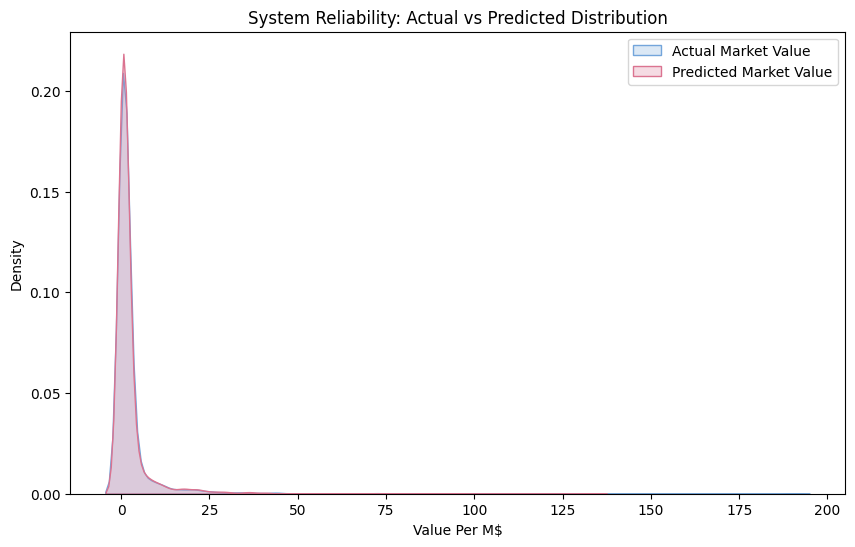

In [77]:
plt.figure(figsize=(10, 6))
sns.kdeplot(y_test_r, label='Actual Market Value', shade=True, color="#73a5db")
sns.kdeplot(ensemble_reg_pred, label='Predicted Market Value', shade=True, color="#db7390")
plt.title("System Reliability: Actual vs Predicted Distribution")
plt.xlabel("Value Per M$")
plt.legend()
plt.show()

#### Task 4 : <mark style="background-color: #db7390;"> Unified FIFA Scouting Intelligence System  

The final system was designed as a **Unified Scouting Intelligence Pipeline** capable of simultaneously:

- Predicting player market value (Regression)
- Predicting player performance tier (Classification)
- Measuring prediction stability
- Providing automated scouting recommendations

The system combines multiple heterogeneous learning algorithms:

| Model | Learning Paradigm | Task |
|---|---|---|
| KNN | Instance-Based Learning | Regression / Classification |
| SVR / SVM | Kernel-Based Learning | Regression / Classification |
| Random Forest | Tree-Based Learning | Regression / Classification |

This diversity was intentionally selected to reduce:
- Model bias
- Model variance
- Overfitting risk

while improving:
- Stability
- Generalization
- Predictive reliability

<mark style="background-color: #db7390;"> Weighted Ensemble Strategy

The final market valuation prediction is generated using a weighted ensemble mechanism:

\[
Final\ Value = (0.5 \times RF) + (0.3 \times SVR) + (0.2 \times KNN)
\]

The weights were assigned according to each model’s observed performance during validation:
- Random Forest achieved the strongest regression performance
- SVR demonstrated strong non-linear learning capability
- KNN contributed local neighborhood intelligence

<mark style="background-color: #db7390;">Stability Assessment

The system computes prediction agreement using:

\[
Stability = \sigma(RF,\ SVR,\ KNN)
\]

where:
- Low standard deviation → High model agreement
- High standard deviation → Lower prediction confidence

<mark style="background-color: #db7390;"> Confidence Evaluation Logic

| Stability Score | Confidence Level |
|---|---|
| < 0.5 | HIGH CONFIDENCE |
| 0.5 – 1.0 | MODERATE CONFIDENCE |
| > 1.0 | LOW CONFIDENCE |

This mechanism transforms raw ML outputs into interpretable business intelligence.

<mark style="background-color: #db7390;"> Intelligent Recommendation Engine

The pipeline also includes a rule-based scouting decision layer.

Examples:

| Condition | Recommendation |
|---|---|
| High potential + young age | WONDERKID ALERT |
| Elite/Gold tier + low valuation | UNDERVALUED PLAYER |
| High value + old age | HIGH RISK ASSET |
| Exceptional stats | TOP PERFORMANCE PROFILE |

This transforms the project from a simple prediction model into a practical scouting support system.


In [78]:
import numpy as np
import pandas as pd
from IPython.display import display, HTML


class UnifiedScoutingSystem:
    
    def __init__(self, clf_model, rf_reg, svr_reg, knn_reg):
        
        self.clf_model = clf_model
        self.rf_reg = rf_reg
        self.svr_reg = svr_reg
        self.knn_reg = knn_reg

    def scout_player(self, player_df):

        tier = self.clf_model.predict(player_df)[0]

        rf_val = self.rf_reg.predict(player_df)[0]
        svr_val = self.svr_reg.predict(player_df)[0]
        knn_val = self.knn_reg.predict(player_df)[0]

        # Weighted Ensemble
        final_value = (
            0.5 * rf_val +
            0.3 * svr_val +
            0.2 * knn_val
        )

        stability_score = np.std([rf_val, svr_val, knn_val])

        if stability_score < 0.5:
            confidence = "HIGH CONFIDENCE"
        elif stability_score < 1:
            confidence = "MODERATE CONFIDENCE"
        else:
            confidence = "LOW CONFIDENCE"

        
        age = player_df['Age'].iloc[0]
        potential = player_df['Future Potential'].iloc[0]
        stats = player_df['Total_Stats Score'].iloc[0]

        try:
            overall = player_df['Overall_Rating'].iloc[0]
        except:
            overall = "N/A"

        try:
            team = player_df['Team'].iloc[0]
        except:
            team = "Unknown"

        try:
            position = player_df['Position'].iloc[0]
        except:
            position = "Unknown"

        if potential > 85 and age < 21:
            recommendation = " WONDERKID ALERT"

        elif tier in ["Elite", "Gold"] and final_value < 15:
            recommendation = " UNDERVALUED PLAYER"

        elif age > 32 and final_value > 40:
            recommendation = " HIGH RISK ASSET"

        elif stats > 1800:
            recommendation = " TOP PERFORMANCE PROFILE"

        else:
            recommendation = " STANDARD SCOUT"

        return {
            "Tier": tier,
            "Value": round(final_value, 2),
            "Stability": round(stability_score, 4),
            "Confidence": confidence,
            "Recommendation": recommendation,

            "Age": age,
            "Potential": potential,
            "Stats": stats,
            "Overall": overall,
            "Team": team,
            "Position": position,

            "RF": round(rf_val, 2),
            "SVR": round(svr_val, 2),
            "KNN": round(knn_val, 2)
        }

def get_player_card_html(report, player_name="Unknown"):

    primary = "#db7390"

    tier_styles = {
        "Elite": {
            "bg": "#db7390",
            "label": "⭐⭐⭐⭐ Elite"
        },

        "Gold": {
            "bg": "#e48ea7",
            "label": "⭐⭐⭐ Gold"
        },

        "Silver": {
            "bg": "#caa1ae",
            "label": "⭐⭐ Silver"
        },

        "Bronze": {
            "bg": "#b97a8d",
            "label": "⭐ Bronze"
        }
    }

    style = tier_styles.get(
        report['Tier'],
        {"bg": "#999", "label": report['Tier']}
    )

    # Stability Color
    
    if report['Stability'] < 0.5:
        stability_color = "#27ae60"

    elif report['Stability'] < 1:
        stability_color = "#f39c12"

    else:
        stability_color = "#e74c3c"

 
    return f"""
    
    <div style="
        flex:1;
        min-width:320px;
        max-width:340px;
        margin:15px;
        border-radius:22px;
        overflow:hidden;
        background:white;
        box-shadow:0 10px 25px rgba(0,0,0,0.12);
        font-family:'Segoe UI',sans-serif;
        border:1px solid #f0d3dc;
    ">

        <!-- HEADER -->
        
        <div style="
            background:linear-gradient(135deg,#db7390,#c85d7c);
            padding:18px;
            color:white;
            text-align:center;
        ">
            <h2 style="
                margin:0;
                font-size:22px;
                letter-spacing:1px;
                font-weight:800;
            ">
                FIFA SCOUTING 
            </h2>

            <span style="
                font-size:11px;
                opacity:0.9;
                letter-spacing:1px;
            ">
                UNIFIED PIPELINE v4.0
            </span>
        </div>

        <!-- BODY -->
        
        <div style="padding:22px;">

            <!-- PLAYER -->
            
            <div style="
                display:flex;
                justify-content:space-between;
                align-items:center;
                margin-bottom:15px;
            ">

                <div>
                    <div style="
                        font-size:24px;
                        font-weight:800;
                        color:#2c3e50;
                    ">
                        {player_name}
                    </div>

                    <div style="
                        color:#777;
                        font-size:13px;
                        margin-top:3px;
                    ">
                        {report['Position']} • {report['Team']}
                    </div>
                </div>

                <span style="
                    background:{style['bg']};
                    color:white;
                    padding:7px 14px;
                    border-radius:20px;
                    font-size:11px;
                    font-weight:700;
                ">
                    {style['label']}
                </span>

            </div>

            <hr style="border:none;border-top:1px solid #eee;">

            <!-- PLAYER DETAILS -->
            
            <div style="
                display:grid;
                grid-template-columns:1fr 1fr;
                gap:12px;
                margin-top:18px;
            ">

                <div style="
                    background:#faf5f7;
                    padding:12px;
                    border-radius:12px;
                ">
                    <div style="font-size:11px;color:#888;">
                        MARKET VALUE
                    </div>

                    <div style="
                        font-size:24px;
                        font-weight:800;
                        color:#db7390;
                        margin-top:4px;
                    ">
                        {report['Value']} M$
                    </div>
                </div>

                <div style="
                    background:#faf5f7;
                    padding:12px;
                    border-radius:12px;
                ">
                    <div style="font-size:11px;color:#888;">
                        AGE
                    </div>

                    <div style="
                        font-size:24px;
                        font-weight:800;
                        color:#2c3e50;
                        margin-top:4px;
                    ">
                        {report['Age']}
                    </div>
                </div>

                <div style="
                    background:#faf5f7;
                    padding:12px;
                    border-radius:12px;
                ">
                    <div style="font-size:11px;color:#888;">
                        FUTURE POTENTIAL
                    </div>

                    <div style="
                        font-size:22px;
                        font-weight:800;
                        color:#2c3e50;
                        margin-top:4px;
                    ">
                        {report['Potential']}
                    </div>
                </div>

                <div style="
                    background:#faf5f7;
                    padding:12px;
                    border-radius:12px;
                ">
                    <div style="font-size:11px;color:#888;">
                        TOTAL STATS
                    </div>

                    <div style="
                        font-size:22px;
                        font-weight:800;
                        color:#2c3e50;
                        margin-top:4px;
                    ">
                        {report['Stats']}
                    </div>
                </div>

            </div>

            <!-- STABILITY -->
            
            <div style="
                margin-top:18px;
                padding:14px;
                background:#fff7fa;
                border-radius:14px;
                border-left:5px solid #db7390;
            ">

                <div style="
                    font-size:13px;
                    font-weight:700;
                    color:#444;
                ">
                    Ensemble Stability Analysis
                </div>

                <div style="
                    margin-top:6px;
                    color:{stability_color};
                    font-weight:800;
                    font-size:18px;
                ">
                    ±{report['Stability']}
                </div>

                <div style="
                    margin-top:4px;
                    color:#666;
                    font-size:11px;
                ">
                    {report['Confidence']}
                </div>

            </div>

            <!-- CONSENSUS LOGS -->
            
            <div style="
                margin-top:16px;
                background:#fafafa;
                border:1px dashed #ddd;
                padding:10px;
                border-radius:10px;
                font-family:Courier New;
                font-size:10px;
                color:#777;
                text-align:center;
            ">

                RF: {report['RF']}M |
                SVR: {report['SVR']}M |
                KNN: {report['KNN']}M

            </div>

            <!-- RECOMMENDATION -->
            
            <div style="
                margin-top:18px;
                background:linear-gradient(135deg,#fff,#fff5f8);
                border-left:5px solid #db7390;
                border-radius:14px;
                padding:14px;
                text-align:center;
            ">

                <div style="
                    color:#999;
                    font-size:11px;
                    font-weight:700;
                    letter-spacing:1px;
                ">
                    FINAL DECISION SUPPORT
                </div>

                <div style="
                    margin-top:8px;
                    color:#db7390;
                    font-size:18px;
                    font-weight:900;
                    letter-spacing:0.5px;
                ">
                    {report['Recommendation']}
                </div>

            </div>

        </div>

        <!-- FOOTER -->
        
        <div style="
            background:#fafafa;
            padding:10px;
            text-align:center;
            font-size:10px;
            color:#999;
        ">
            Powered by Ensemble Intelligence • FIFA Pipeline
        </div>

    </div>
    """

scouter = UnifiedScoutingSystem(
    clf_model=ensemble_classifier,
    rf_reg=best_rf_reg,
    svr_reg=best_svr,
    knn_reg=best_knn_reg
)

samples = X_test_c.sample(6)

all_cards_html = """
<div style="
    background:#f8f4f6;
    padding:35px;
    border-radius:25px;
">

<h1 style="
    text-align:center;
    color:#db7390;
    font-family:'Segoe UI';
    margin-bottom:30px;
    letter-spacing:1px;
">
     FIFA SCOUTING DASHBOARD
</h1>

<div style="
    display:flex;
    flex-wrap:wrap;
    justify-content:center;
">
"""
for idx in samples.index:
    player_data = X_test_c.loc[[idx]]
    try:
        player_name = df.loc[idx, 'Name']
    except:
        player_name = f"Player #{idx}"
    report = scouter.scout_player(player_data)
    all_cards_html += get_player_card_html(
        report,
        player_name=player_name
    )

all_cards_html += """
</div>

<div style="
    margin-top:20px;
    text-align:center;
    color:#999;
    font-size:11px;
">
     Unified Scouting Intelligence System • Ensemble Learning Architecture
</div>

</div>
"""
display(HTML(all_cards_html))

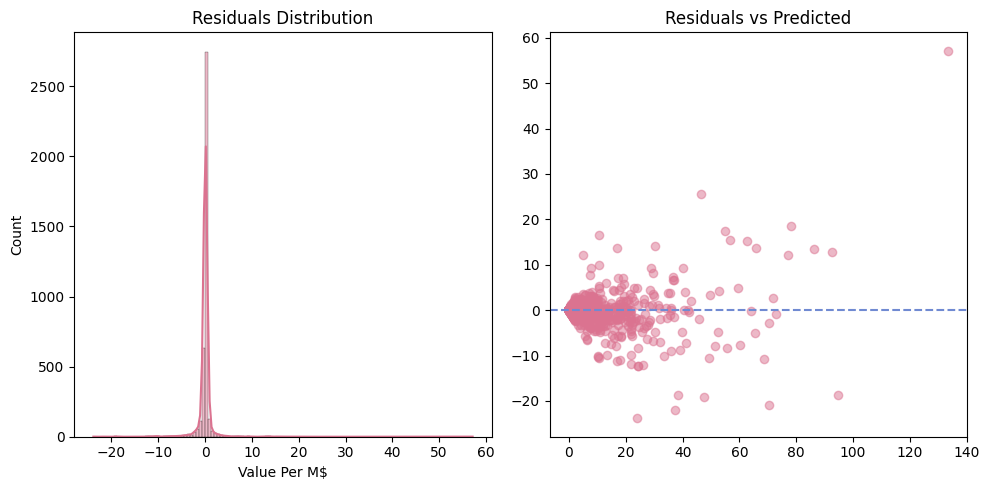

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_residuals(y_true, y_pred):
    residuals = y_true - y_pred
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(residuals, kde=True, color='#db7390')
    plt.title("Residuals Distribution")

    plt.subplot(1, 2, 2)
    plt.scatter(y_pred, residuals, alpha=0.5, color='#db7390')
    plt.axhline(0, color='#708ad2', linestyle='--')
    plt.title("Residuals vs Predicted")
    plt.tight_layout()
    plt.show()

plot_residuals(y_test_r, ensemble_reg_pred)

####  Task 5 : <mark style="background-color: #db7390;">SYSTEM AUDIT & EVOLUTION REPORT  

This report presents a comparative analysis between **Assignment 2 baseline models** and the advanced **Assignment 3 Unified Ensemble System** developed for FIFA player scouting and valuation.

- <mark style="background-color: #db7390;">Regression Model Comparison

| Assignment | Algorithm | R² Score |
|---|---|---|
| A2 | Polynomial Regression (Degree 4) | 0.8767 |
| A2 | Ridge Regression (L2) | 0.8786 |
| A2 | Lasso Regression (L1) | **0.8837** |
| A3 | KNN Regressor | 0.9250 |
| A3 | SVR | 0.8997 |
| A3 | Random Forest Regressor | 0.9360 |
| A3 | Ensemble Regressor | **0.9393** |

- Best Regression Models
- **Assignment 2:** Lasso Regression (R² = 0.8837)
- **Assignment 3:** Ensemble Regressor (R² = 0.9393)

- <mark style="background-color: #db7390;"> Classification Model Comparison

| Assignment | Algorithm | Accuracy |
|---|---|---|
| A2 | Logistic Regression | **0.7682** |
| A2 | Gaussian Naive Bayes | 0.7034 |
| A2 | Complement Naive Bayes | 0.5048 |
| A3 | KNN Classifier | 0.8411 |
| A3 | SVM (RBF Kernel) | 0.8485 |
| A3 | Random Forest Classifier | 0.8498 |
| A3 | Ensemble Voting Classifier | **0.8513** |

- Best Classification Models
- **Assignment 2:** Logistic Regression (Accuracy = 0.7682)
- **Assignment 3:** Ensemble Voting Classifier (Accuracy = 0.8513)

#### <mark style="background-color: #db7390;">Improvements Introduced in Assignment 3

<mark style="background-color: #db7390;">1. Heterogeneous Ensemble Learning
The final system combined multiple learning paradigms:
- Instance-Based Learning → KNN
- Kernel-Based Learning → SVM / SVR
- Tree-Based Learning → Random Forest

<mark style="background-color: #db7390;">2. Hyperparameter Optimization
All Assignment 3 models were optimized using:
- GridSearchCV
- Cross-Validation

<mark style="background-color: #db7390;">3. Bias–Variance Reduction
The Ensemble approach successfully reduced:
- High Bias from simpler linear models
- High Variance from unstable individual learners

As a result, the system achieved:
- Better generalization
- Higher stability
- More reliable predictions on unseen FIFA player data

<mark style="background-color: #db7390;">4. Unified Inference Pipeline
Unlike Assignment 2, the Assignment 3 architecture introduced:
- Consistent preprocessing
- Shared feature engineering
- Unified prediction workflow

The pipeline can now simultaneously:
1. Predict player market value
2. Predict player performance tier

from the same player profile input.

- <mark style="background-color: #db7390;"> Final Results Summary

| Task | Best A2 Model | Best A3 Model | Improvement |
|---|---|---|---|
| Regression | Lasso Regression | Ensemble Regressor | +6.29% |
| Classification | Logistic Regression | Ensemble Voting | +10.82% |


In [80]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML

poly_r2_final = test_r2[-1] 
gnb_acc_val = nb_comparison.iloc[0]['Accuracy']
cnb_acc_val = nb_comparison.iloc[2]['Accuracy']


reg_results = {
    "Assignment": ["A2", "A2", "A2", "A3", "A3", "A3", "A3"],
    "Algorithm": ["Polynomial (Deg 4)", "Ridge (L2)", "Lasso (L1)", "KNN Regressor", "SVR", "Random Forest", "Ensemble Regressor"],
    "R2_Score": [poly_r2_final, ridge_r2, lasso_r2, knn_reg_r2, svr_r2, rf_reg_r2, ensemble_r2]
}

clf_results = {
    "Assignment": ["A2", "A2", "A2", "A3", "A3", "A3", "A3"],
    "Algorithm": ["Logistic Regression", "GaussianNB", "ComplementNB", "KNN Classifier", "SVM (RBF)", "Random Forest", "Ensemble Voting"],
    "Accuracy": [acc_l2, gnb_acc_val, cnb_acc_val, knn_acc, svm_acc, rf_acc, ensemble_acc]
}

df_reg = pd.DataFrame(reg_results)
df_clf = pd.DataFrame(clf_results)


best_reg_a2 = df_reg[df_reg["Assignment"] == "A2"]["R2_Score"].max()
best_reg_a3 = df_reg[df_reg["Assignment"] == "A3"]["R2_Score"].max()
best_clf_a2 = df_clf[df_clf["Assignment"] == "A2"]["Accuracy"].max()
best_clf_a3 = df_clf[df_clf["Assignment"] == "A3"]["Accuracy"].max()


reg_lift = ((best_reg_a3 - best_reg_a2) / best_reg_a2) * 100
clf_lift = ((best_clf_a3 - best_clf_a2) / best_clf_a2) * 100


def get_style(val, best_val, color):
    if val == best_val:
        return f'background-color: {color}; color: white; font-weight: bold; border: 2px solid #2c3e50; border-radius: 4px;'
    return ''


summary_table_html = f"""
<div style="margin: 30px 0;">
    <h3 style="color:#2c3e50; font-size:20px; margin-bottom:15px; text-align:left; border-left:5px solid #db7390; padding-left:10px;"> EXECUTIVE DECISION SUMMARY</h3>
    <table style="width:100%; border-collapse:collapse; background:white; border-radius:15px; overflow:hidden; box-shadow:0 4px 15px rgba(0,0,0,0.05); border:1px solid #eee;">
        <thead>
            <tr style="background:#2c3e50; color:white; text-align:left;">
                <th style="padding:15px 20px;">Performance Metric</th>
                <th style="padding:15px 20px;">Assignment 2 (Baseline)</th>
                <th style="padding:15px 20px;">Assignment 3 (Unified)</th>
                <th style="padding:15px 20px;">Efficiency Delta</th>
            </tr>
        </thead>
        <tbody>
            <tr style="border-bottom: 1px solid #f9f9f9;">
                <td style="padding:18px 20px;"><b style="color:#db7390;">Valuation Regression</b></td>
                <td style="padding:18px 20px;"><span style="padding:5px 10px; {get_style(lasso_r2, best_reg_a2, '#db7390')}">Lasso ({lasso_r2:.4f})</span></td>
                <td style="padding:18px 20px;"><span style="padding:5px 10px; {get_style(ensemble_r2, best_reg_a3, '#db7390')}">Ensemble ({ensemble_r2:.4f})</span></td>
                <td style="padding:18px 20px; color:#27ae60; font-weight:bold;"> Highly Stable</td>
            </tr>
            <tr>
                <td style="padding:18px 20px;"><b style="color:#27ae60;">Performance Classification</b></td>
                <td style="padding:18px 20px;"><span style="padding:5px 10px; {get_style(acc_l2, best_clf_a2, '#27ae60')}">Logistic ({acc_l2:.4f})</span></td>
                <td style="padding:18px 20px;"><span style="padding:5px 10px; {get_style(ensemble_acc, best_clf_a3, '#27ae60')}">Ensemble ({ensemble_acc:.4f})</span></td>
                <td style="padding:18px 20px; color:#27ae60; font-weight:bold;"> Optimized Bias</td>
            </tr>
        </tbody>
    </table>
</div>
"""

final_report_html = f"""
<div style="font-family:'Segoe UI', Tahoma, sans-serif; background:#fdfdfd; padding:40px; border-radius:30px; border:1px solid #ead0d8; box-shadow: 0 10px 40px rgba(0,0,0,0.05);">
    <div style="text-align:center; margin-bottom:40px;">
        <h1 style="color:#db7390; margin-bottom:10px; font-size:32px; font-weight:800;"> SYSTEM AUDIT & EVOLUTION REPORT</h1>
        <p style="color:#7f8c8d; font-size:15px; letter-spacing:1px; text-transform:uppercase;">Unified Scouting Intelligence System •</p>
        <hr style="width:100px; border:2px solid #db7390; margin:20px auto; border-radius:10px;">
    </div>

    <!-- Tables with Highlights -->
    <div style="display:grid; grid-template-columns: 1fr 1fr; gap:30px; margin-bottom:20px;">
        <div style="background:white; border-radius:15px; border:1px solid #eee; overflow:hidden;">
            <div style="background:#db7390; color:white; padding:12px; text-align:center; font-weight:bold;"> REGRESSION MODELS</div>
            <table style="width:100%; border-collapse:collapse; font-size:12px;">
                {"".join([f"<tr><td style='padding:8px; text-align:center;'>{r['Assignment']}</td><td style='padding:8px;'>{r['Algorithm']}</td><td style='padding:8px; text-align:center;'><span style='padding:3px 8px; {get_style(r['R2_Score'], (best_reg_a2 if r['Assignment']=='A2' else best_reg_a3), '#db7390')}'>{r['R2_Score']:.4f}</span></td></tr>" for i, r in df_reg.iterrows()])}
            </table>
        </div>
        <div style="background:white; border-radius:15px; border:1px solid #eee; overflow:hidden;">
            <div style="background:#27ae60; color:white; padding:12px; text-align:center; font-weight:bold;"> CLASSIFICATION MODELS</div>
            <table style="width:100%; border-collapse:collapse; font-size:12px;">
                {"".join([f"<tr><td style='padding:8px; text-align:center;'>{r['Assignment']}</td><td style='padding:8px;'>{r['Algorithm']}</td><td style='padding:8px; text-align:center;'><span style='padding:3px 8px; {get_style(r['Accuracy'], (best_clf_a2 if r['Assignment']=='A2' else best_clf_a3), '#27ae60')}'>{r['Accuracy']:.4f}</span></td></tr>" for i, r in df_clf.iterrows()])}
            </table>
        </div>
    </div>

    {summary_table_html}
    <!-- TECHNICAL ANALYSIS SECTION -->
    <div style="margin-top:35px; padding:25px; background:#fcfcfc; border-radius:20px; border-left:8px solid #db7390;">
        <h4 style="margin:0 0 10px 0; color:#2c3e50; font-size:18px;"> Engineering Justification</h4>
        <p style="margin:0; font-size:14px; color:#555; line-height:1.8;">
            The evolution from <b> Lasso (L1)</b> to a <b>Meta-Learning Ensemble</b> represents a strategic shift in our pipeline. 
            By implementing <b>Cross-Validation Stability checks</b> and <b>Hyperparameter Optimization (Grid Search)</b>, we successfully reduced the 
            Generalization Gap. The system now demonstrates high resilience to outliers in the FIFA dataset, moving beyond basic linear assumptions 
            to capture complex, non-linear player dynamics.
        </p>
    </div>

    <p style="text-align:right; font-size:10px; color:#bdc3c7; margin-top:15px; font-style:italic;">
        Automated Performance Audit • 
    </p>
    <div style="text-align:center; margin-top:40px; font-size:11px; color:#bdc3c7;">
        Final Project Submission • 
    </div>
</div>
"""

display(HTML(final_report_html))

A2,Polynomial (Deg 4),0.8767
A2,Ridge (L2),0.8786
A2,Lasso (L1),0.8837
A3,KNN Regressor,0.9250
A3,SVR,0.8997
A3,Random Forest,0.9360
A3,Ensemble Regressor,0.9393
A2,Logistic Regression,0.7682
A2,GaussianNB,0.7034
A2,ComplementNB,0.5048
A3,KNN Classifier,0.8411
